# Financial Trading with Python, 2nd Edition

Cordell L. Tanny, CFA, FRM, FDP

Chapter 10: Walk-Forward Analysis

Notebook 10.1: Walk-Forward Analysis

Version 1.0

Last revised: July 12, 2026


#


---

*Author's Note:*
*Before we get into this notebook, I just want to say congratulations. I have thrown a lot of content at you and gradually increased the complexity as we progressed. And now we are going to start to see what you really came here for: learning how to build and test trading strategies. This notebook is a beast. It might take some time to go through it and understand everything in it, but this is one of the most important chapters in the whole book. You might find it helpful to keep two copies of this notebook open on different monitors so you can read my explanations while looking at the output and visuals. Take your time, but when you are done, you will be so much further along in your quant knowledge!*


In Notebook 9.1 we ran a clean out-of-sample test on the VIXY tail hedge and built a diagnostic toolkit to extract more information from the result than the headline numbers offered. The verdict was limited. We could not conclude the strategy works, and we could not conclude it does not, because a single OOS test on six years of data is not enough evidence to support either claim. The closing thought was that walk-forward analysis is the structural answer to that limitation: instead of one experiment with one outcome, WFA gives many experiments and asks whether a pattern emerges that survives the noise.

This is where I think WFA stops being more rigorous OOS and becomes something qualitatively different. A simple OOS test tells you one thing happened. WFA tells you a pattern across many regimes. If 8 of 10 windows show positive risk-adjusted returns and the 2 failures cluster in a specific regime type, you have learned something useful. If 3 of 10 windows show positive returns and the wins look random, the strategy probably has no edge. This also gives you the regime conditioning analysis almost for free, because each window already comes with its own market context.

The VIXY tail hedge from 9.1 was not a good vehicle for WFA because its parameters were structural choices, not tuning dials. Forcing WFA on parameters that were not chosen by optimization would be theater. In this notebook we use a different kind of strategy where WFA actually earns its place: a strategy whose model itself updates as new data arrives.

The strategy we work with is a sector rotation strategy based on multivariate regression analysis, adapted from a 2016 paper by Spencer Seggebruch (R.T. Jones Capital Equities Management). The paper is publicly available at:

https://artesysonline.com/wp-content/uploads/2016/06/Multivariate-Regression-Analysis-Considering-the-Relevance-of-Past-Performance.pdf

The paper's setup is straightforward. Each of nine SPDR sector ETFs gets its own linear regression model. The strategy operates entirely on monthly data: features are computed at month-end from the trailing 12 months, the model predicts the sector's 12-month forward return, and the portfolio rebalances once per month. There is no daily decision-making in this strategy, and we run the entire pipeline at monthly frequency to match. At the start of each month, the strategy equal-weights the sectors with positive predicted returns and holds cash (BIL) for the rest. The paper reports strong results: 7.04% annualized return vs SPY's 4.19%, Sharpe of 0.55 vs 0.23, alpha of 3.43%, beta of 0.60, over the period 2000 to 2015.

What makes this strategy interesting for our chapter is the methodology used to validate it. The paper fit one set of regression coefficients on a long in-sample period (2000 to 2012) and then applied those frozen coefficients to a forward-test window (2012 to 2015). The strategy looked good in the forward test, and the paper concluded that the multivariate regression approach picks up real trends in the data.

That conclusion is exactly the kind of claim WFA is built to interrogate.

By 2016 standards the paper's validation was reasonable. By the standards we have been building in this chapter, it is not enough. A single forward test on a single set of frozen coefficients cannot tell us whether the relationships the model learned are persistent across regimes, or whether they reflect the specific market environment of the in-sample period. The relationships could be real and stable, in which case the paper's headline numbers are conservative because frozen coefficients waste information. Or the relationships could be unstable, in which case the paper's headline numbers are an artifact of one in-sample fit on one specific period.

We are not contradicting the paper. We are testing its methodology under a stricter validation standard. The contribution of this notebook is to apply WFA to the same strategy and ask the question the paper could not answer with its design: are the regression coefficients persistent, or do they drift?

A note on the spirit of this notebook before we start. The strategy we are working with has a published source and a defined design. But we are not constrained to reproduce it exactly. Where the chapter machinery from earlier in the book can plausibly improve the strategy or sharpen the diagnostics (signal processing from Chapter 6, the false discovery framework from Chapter 7, the bootstrap diagnostics from Notebook 9.1), we will experiment. This is the chapter where we have permission to be curious and not just methodical. The only rule is that any experiment has to be documented and explained, so the reader can see what I tried and why.

This notebook covers:

- The qualitative difference between OOS and WFA, applied to a model-driven strategy
- The Seggebruch (2016) sector rotation strategy, with full attribution and an assessment of what its methodology can and cannot establish
- Building the strategy machinery: feature construction, per-sector regression fits, monthly rebalancing
- The paper's fit-once-then-forward approach run as a methodological anchor
- Walk-forward analysis from scratch with rolling refit each window
- Coefficient stability as the headline diagnostic that WFA produces and a single OOS cannot
- Per-window performance, regime conditioning, and per-sector diagnostics
- A direct comparison of the paper's approach vs WFA vs SPY buy-and-hold
- Production-grade WFA using vbt.Splitter
- A closing challenge: replacing the OLS regression with a Kalman filter for continuous coefficient updates

We use the following packages in this notebook:

- `pandas` and `numpy` for data manipulation
- `matplotlib` and `seaborn` for visualization
- `statsmodels` for the per-sector OLS regressions
- `vectorbt` for backtesting, following the same pattern from Notebooks 8.2 and 9.1
- The `calculate_performance_metrics` function from `functions.py`, our authoritative metrics toolkit from Chapter 7

## Section 1: Setting Up the Environment

We install the same pinned package versions as Notebook 9.1, plus statsmodels for the per-sector OLS regressions. We also pull functions.py from the book's GitHub repository so we have access to calculate_performance_metrics.

In [1]:
# Install pinned package versions. Same versions used in Chapter 8 and
# Notebook 9.1 so the environment stays consistent across the book.
# statsmodels is pinned to 0.14.5, the most recent release that is
# compatible with our pinned scipy 1.16.3.
!pip install vectorbt==0.28.5 pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scipy==1.16.3 statsmodels==0.14.5 -q

# Download the Chapter 7 metrics toolkit. We use the same authoritative
# performance evaluation function we have been using throughout the book.
!wget -q https://raw.githubusercontent.com/PacktPublishing/Hands-on-Financial-Trading-with-Python-Second-Edition/main/FINAL/python_scripts/functions.py

# Standard imports.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# statsmodels for the per-sector OLS regressions. The mvreg approach
# from the source paper uses ordinary least squares with five features
# per sector. statsmodels.api.OLS is the canonical Python equivalent.
import statsmodels.api as sm

# VectorBT does most of its work through this single namespace. The
# alias is the convention used in the official VectorBT documentation.
import vectorbt as vbt

# The Chapter 7 performance toolkit.
from functions import calculate_performance_metrics

# Suppress pandas FutureWarnings that VectorBT triggers on some pandas
# versions. The warnings are noise, not signal, and they clutter the
# notebook output.
warnings.simplefilter(action='ignore', category=FutureWarning)

# Standard plotting setup, same as every previous notebook.
sns.set_theme()

# Confirm the environment is ready.
print(f"pandas version:       {pd.__version__}")
print(f"numpy version:        {np.__version__}")
print(f"vectorbt version:     {vbt.__version__}")
print(f"statsmodels version:  {sm.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.7/421.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.2 MB/s eta 0:00:00
pandas version:       2.2.2
numpy version:        2.0.2
vectorbt version:     0.28.5
statsmodels version:  0.14.5


The environment is ready. statsmodels 0.14.5 installed cleanly alongside the pinned versions of pandas, numpy, and vectorbt. We are now set up to download the data for the sector rotation strategy.

## Section 2: Loading the Data

The strategy needs eleven tickers: nine SPDR sector ETFs (XLV, XLI, XLY, XLP, XLB, XLK, XLU, XLE, XLF), SPY for the excess-return feature and as a benchmark, and BIL as the cash sleeve when sectors are out.

We load the data from a parquet file hosted in the book's GitHub repository. The parquet covers January 2003 through December 2025 using FMP-sourced adjusted close prices. BIL has NaN values until its May 2007 launch date, which we handle in the strategy machinery later in this notebook.

If you prefer to work with a local copy (for offline work, or if the GitHub fetch fails), upload the parquet to your Colab session and use the optional code path in the cell below.

In [2]:
# Load the sector rotation price data from the book's GitHub repository.
# This is the standard path. It fetches the parquet via wget and reads
# it into a pandas DataFrame.
#
# If you have a local copy of the parquet uploaded to Colab, comment
# out the wget line below and uncomment the second line in the upload-
# path block. The local-upload path expects the file to be at
# /content/sector_rotation_prices.parquet (the default upload location
# in Colab).

# --- Default path: download from GitHub ---
!wget -q https://raw.githubusercontent.com/PacktPublishing/Hands-on-Financial-Trading-with-Python-Second-Edition/main/FINAL/data/sector_rotation_prices.parquet

# --- Optional path: use a locally uploaded copy ---
# To use this path instead of the GitHub download, comment out the
# wget line above and uncomment the line below. Make sure you have
# uploaded sector_rotation_prices.parquet to Colab via the file
# browser before running this cell.
# !cp /content/sector_rotation_prices.parquet ./sector_rotation_prices.parquet

# Load the parquet into a pandas DataFrame.
df_prices = pd.read_parquet('sector_rotation_prices.parquet')

# Confirm the data loaded correctly.
print(f"Date range: {df_prices.index.min().date()} to {df_prices.index.max().date()}")
print(f"Trading days: {len(df_prices):,}")
print(f"Tickers: {df_prices.columns.tolist()}")
print()
print(f"BIL coverage starts: {df_prices['BIL'].first_valid_index().date()}")
print(f"BIL NaN rows (pre-launch): {df_prices['BIL'].isna().sum():,}")
print()
print("First 3 rows:")
print(df_prices.head(3))
print()
print("Last 3 rows:")
print(df_prices.tail(3))

Date range: 2003-01-02 to 2025-12-31
Trading days: 5,787
Tickers: ['XLV', 'XLI', 'XLY', 'XLP', 'XLB', 'XLK', 'XLU', 'XLE', 'XLF', 'SPY', 'BIL']

BIL coverage starts: 2007-05-30
BIL NaN rows (pre-launch): 1,108

First 3 rows:
              XLV    XLI   XLY    XLP   XLB   XLK   XLU   XLE    XLF    SPY  \
date                                                                          
2003-01-02  18.61  13.71  9.09  11.34  6.16  5.83  4.37  6.02  11.59  59.48   
2003-01-03  18.80  13.76  8.89  11.32  6.13  5.85  4.42  6.01  11.57  59.66   
2003-01-06  19.00  13.88  9.05  11.41  6.25  6.11  4.62  6.06  11.97  60.71   

            BIL  
date             
2003-01-02  NaN  
2003-01-03  NaN  
2003-01-06  NaN  

Last 3 rows:
               XLV     XLI     XLY    XLP    XLB     XLK    XLU    XLE    XLF  \
date                                                                            
2025-12-29  155.18  156.43  120.60  77.85  45.54  145.69  42.56  44.33  55.04   
2025-12-30  155.05  155.99  120.

The data loaded cleanly from GitHub. Eleven tickers, 5,787 trading days from January 2003 through December 2025. BIL coverage begins May 30, 2007 with 1,108 NaN rows before that date. The strategy machinery later in this notebook will handle the BIL alignment by either dropping rows where BIL is missing or substituting cash returns for the pre-2007 period; we will make that decision when we build the backtest.

Before we touch the strategy logic, we visualize the eleven tickers so the structure of the universe is in plain sight.

### 2.1 Visualizing the Universe

We plot the nine sector ETFs on one panel and SPY plus BIL on a second panel, all normalized to start at 100 on the same date. Two panels rather than one because nine sectors plus SPY plus BIL on the same chart is unreadable. The sectors panel lets us see the cross-sectional dispersion that the rotation strategy tries to exploit. The SPY/BIL panel shows the benchmark and the cash sleeve in context.

We normalize from January 2003 for the sectors and SPY, and from May 2007 for BIL (its first available data point). Different start dates mean the lines are not directly comparable across panels, but the relative performance within each panel is accurate.

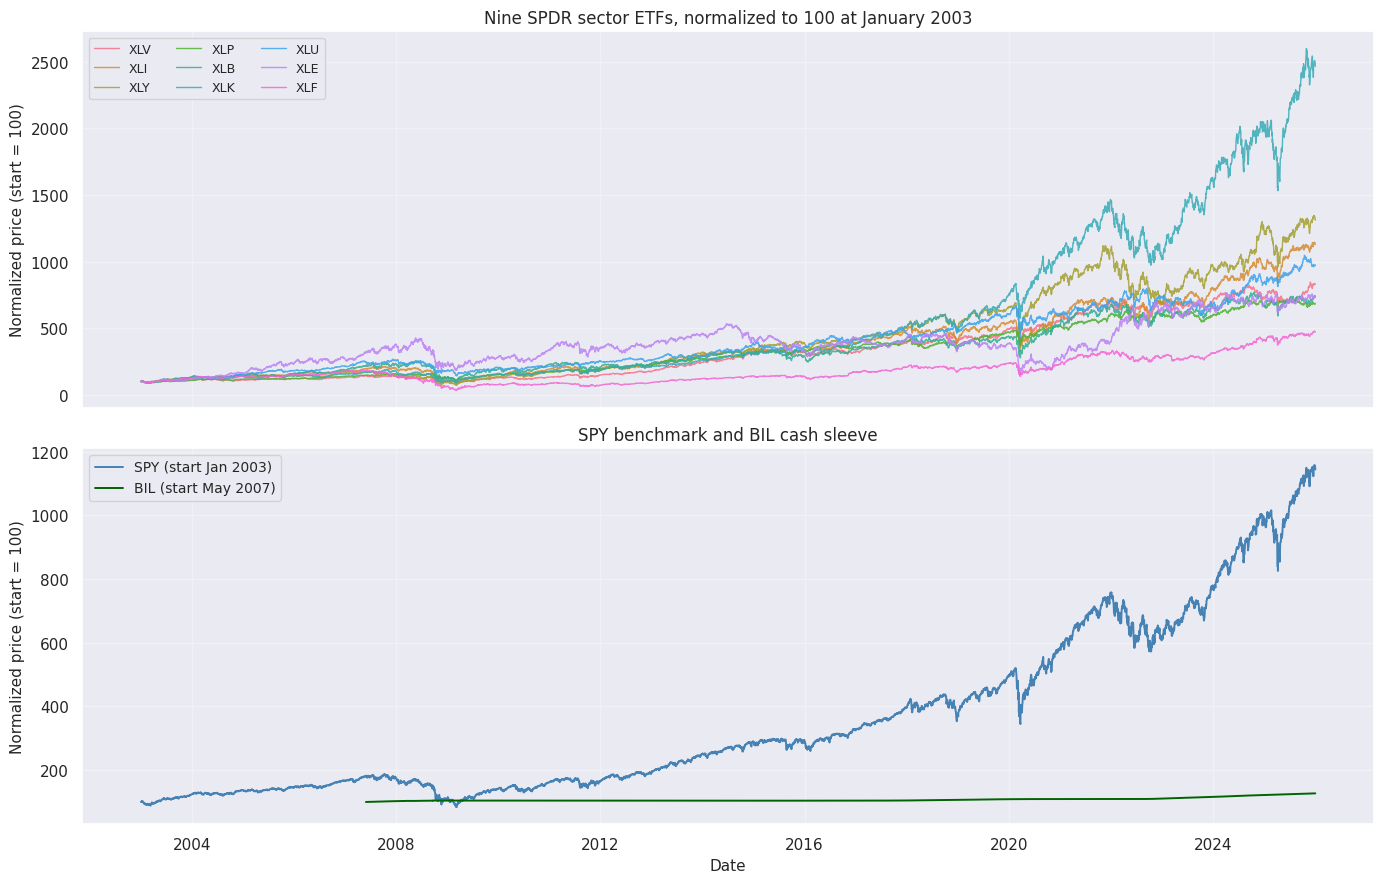

Cumulative total return, January 2003 to December 2025 (%):

  XLK  :   2366.4%
  XLY  :   1211.0%
  SPY  :   1043.3%
  XLI  :   1028.3%
  XLU  :    870.0%
  XLV  :    728.4%
  XLE  :    637.9%
  XLB  :    633.0%
  XLP  :    581.2%
  XLF  :    370.1%


In [3]:
# Build two normalized DataFrames for the two panels. The sectors
# panel and SPY are normalized from the first row. BIL is normalized
# from its first valid date (May 2007).
sector_cols = ['XLV', 'XLI', 'XLY', 'XLP', 'XLB', 'XLK', 'XLU', 'XLE', 'XLF']

sectors_norm = df_prices[sector_cols] / df_prices[sector_cols].iloc[0] * 100
spy_norm = df_prices['SPY'] / df_prices['SPY'].iloc[0] * 100

bil_first = df_prices['BIL'].first_valid_index()
bil_norm = df_prices['BIL'].loc[bil_first:] / df_prices['BIL'].loc[bil_first] * 100


# Build a stacked plot: sectors on top, SPY plus BIL on the bottom.
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top panel: nine sector ETFs.
sector_palette = sns.color_palette("husl", n_colors=len(sector_cols))
for sector, color in zip(sector_cols, sector_palette):
    axes[0].plot(sectors_norm.index, sectors_norm[sector],
                 color=color, linewidth=1.0, alpha=0.85, label=sector)
axes[0].set_ylabel('Normalized price (start = 100)', fontsize=11)
axes[0].set_title('Nine SPDR sector ETFs, normalized to 100 at January 2003',
                  fontsize=12)
axes[0].legend(loc='upper left', ncol=3, fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bottom panel: SPY and BIL.
axes[1].plot(spy_norm.index, spy_norm,
             color='steelblue', linewidth=1.4, label='SPY (start Jan 2003)')
axes[1].plot(bil_norm.index, bil_norm,
             color='darkgreen', linewidth=1.4, label='BIL (start May 2007)')
axes[1].set_ylabel('Normalized price (start = 100)', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_title('SPY benchmark and BIL cash sleeve',
                  fontsize=12)
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Print the cumulative return of each sector and SPY over the full
# period so the dispersion is in numbers as well as in pictures.
total_returns = (df_prices[sector_cols + ['SPY']].iloc[-1]
                 / df_prices[sector_cols + ['SPY']].iloc[0] - 1) * 100

# Sort descending so the leaders and laggards are obvious.
total_returns = total_returns.sort_values(ascending=False)

print("Cumulative total return, January 2003 to December 2025 (%):")
print()
for ticker, ret in total_returns.items():
    print(f"  {ticker:5s}: {ret:>8.1f}%")

The chart and the table tell a clean dispersion story. Twenty-three years of cumulative returns range from 370% (XLF, financials) to 2,366% (XLK, technology). That spread is real and large. SPY, which is what most retail investors actually hold, returned 1,043%, sitting roughly in the middle of the sector pack. Three sectors beat SPY (XLK by a wide margin, XLY and XLI by smaller margins). Six sectors trailed it.

This is exactly the kind of dispersion a sector rotation strategy needs to work. If all nine sectors moved together with little cross-sectional variation, there would be no rotation premium to capture. The fact that XLK delivered more than 2x the cumulative return of XLF over the same period means a strategy that successfully tilts toward winners and away from losers has real upside, in principle.

The question this chapter asks is whether a regression-based strategy can identify those tilts in advance, or whether the dispersion is so unpredictable that any model will be fitting noise. WFA is the tool that answers it.

Before we build the strategy, two practical points worth flagging.

First, the BIL alignment issue. BIL launched in May 2007, so any backtest that uses BIL as the cash sleeve cannot start before that date. The strategy machinery needs 12 months of feature warmup plus a multi-year training window, so the actual start date of the WFA portion of the notebook will be later than May 2007 anyway. We will not need to do anything special to handle the BIL gap; the alignment will fall out naturally.

Second, the cross-sectional dispersion is not constant across time. The 2003 to 2008 period had relatively even sector performance. The 2008 financial crisis hit XLF disproportionately. The post-2014 period has been dominated by XLK pulling away from everything else. WFA across windows will pick up these regime changes and the per-window performance will reflect them.

## Section 3: The Sector Rotation Strategy

The strategy in this notebook is adapted from a 2016 paper by Spencer Seggebruch (R.T. Jones Capital Equities Management):

https://artesysonline.com/wp-content/uploads/2016/06/Multivariate-Regression-Analysis-Considering-the-Relevance-of-Past-Performance.pdf

The paper proposes a sector rotation strategy where each of nine SPDR sector ETFs gets its own linear regression model. The model uses five features computed from the trailing 12 months of monthly data to predict the sector's 12-month forward return. At the start of each month, the strategy equal-weights the sectors with positive predicted returns and holds cash for the rest. The paper reports favorable results: 7.04% annualized return vs SPY's 4.19%, Sharpe of 0.55 vs 0.23, alpha of 3.43%, beta of 0.60, over the period 2000 to 2015.

What the paper did not do, and what this notebook does, is apply walk-forward analysis to the same strategy. The paper fit one set of regression coefficients on a long in-sample period (2000 to 2012) and applied those frozen coefficients to a forward-test window (2012 to 2015). By 2016 standards that was reasonable. By the validation standards we have been building in this chapter, it is not enough. A single forward test on a single set of frozen coefficients cannot tell us whether the relationships the model learned are persistent across regimes, or whether they reflect the specific market environment of the in-sample period.

This section specifies the strategy we will build. The next section builds the machinery. Section 5 reproduces the paper's fit-once-then-forward approach as a methodological anchor. Section 6 onward applies WFA and asks the question the paper could not answer with its design: are the regression coefficients persistent, or do they drift?

### 3.1 The Strategy in Plain Terms

Each month, for each of the nine SPDR sector ETFs:

1. Compute five features from the sector's trailing 12 months of monthly returns.
2. Fit (or apply) a linear regression that predicts the sector's next 12-month return from the five features.
3. If the predicted return is positive, the sector is a buy candidate. If negative, the sector is held in cash.
4. Equal-weight all buy candidates at 1/9 each. The remainder of the portfolio sits in BIL.

The trading rule is intentionally pure. There is no threshold parameter for "how positive does the prediction have to be." There is no cap on how many sectors can be selected. There is no override for unusual market conditions. The strategy follows the model's output mechanically.

This purity is deliberate. We want WFA to test the model itself, not a model plus a tunable trading overlay. If the strategy works, it works because the regression coefficients identify real relationships. If it fails, it fails for the same reason.

### 3.2 The Five Features

For each sector, computed at month-end from the trailing 12 months of monthly returns:

**12-month log return.** Total log return of the sector over the trailing 12 months. The simplest momentum signal.

**12-month sample standard deviation.** Volatility of monthly returns over the trailing 12 months, using the sample standard deviation (n-1 denominator) because the sample size is small.

**12-month drawdown.** Defined as min(0, 12-month return). If the sector lost money over the trailing 12 months, drawdown equals that loss. If the sector gained, drawdown equals zero. This is the paper's specific definition. It is a crude proxy for downside risk but it is the proxy the source paper uses, and we keep it for fidelity.

**12-month price-trend slope.** The slope coefficient from a linear regression of the sector's monthly closing prices against time over the trailing 12 months. Captures the rate of price change separately from total return. Same period can have similar total return with very different trend slope (a slow steady climb vs a sharp rally followed by a give-back, for example).

**12-month excess return vs SPY.** The sector's 12-month log return minus SPY's 12-month log return over the same period. Captures the sector's relative performance against the broad market.

These five features are what the paper calls the independent variables. They are not orthogonal (return and excess return are correlated by construction, drawdown is mechanically tied to return) but they each capture a distinguishable aspect of past performance. Multicollinearity is something we will look at when we examine coefficient stability in Section 7.

### 3.3 The Regression and the Trading Rule

Per-sector regression. Each of the nine sectors has its own model. The dependent variable is the sector's 12-month forward log return. The five independent variables are the features described above, computed at the same point in time.

For a given sector and a given month-end observation date, the regression takes this form:

forward_return = beta_0 + beta_1 * return + beta_2 * volatility + beta_3 * drawdown + beta_4 * slope + beta_5 * excess_return + epsilon

The coefficients beta_0 through beta_5 are estimated by ordinary least squares from a training set of monthly observations.

Trading rule. At the start of each month, we use each sector's most recent feature values plus the model's coefficients to predict the next 12-month forward return. If the prediction is positive, the sector enters the buy list. If negative, it does not. The portfolio is equal-weighted across the buy list at 1/9 per sector, with the remainder in BIL.

The 1/9 weight is constant regardless of how many sectors are in the buy list. If only three sectors have positive predictions, the portfolio holds 3/9 in those three sectors and 6/9 in BIL. If all nine have positive predictions, the portfolio is fully invested in equities. This is the paper's allocation rule and we keep it.

A note on the prediction horizon. The model predicts a 12-month forward return, but we rebalance every month. This is deliberate: the model's output for a given month is "the expected 12-month return starting from this month." We do not commit to holding for 12 months. We use the prediction as a current-month signal, then refresh the prediction next month with the latest features and (if we are in WFA) the latest coefficients. The 12-month forward target was the paper's choice based on its goodness-of-fit analysis across multiple horizons.

## Section 4: Building the Strategy Machinery

We construct the strategy pipeline step by step. The end product is a single long-format DataFrame containing every clean (date, sector) observation with its five features and its 12-month forward return target. That DataFrame becomes the input to every backtest and WFA loop in the rest of the notebook.

The construction has six steps:

1. Resample the daily price data to month-end to get monthly prices for each ticker.
2. Compute the five features for each sector at each month-end from the trailing 12 monthly returns.
3. Compute the 12-month forward log return target for each sector at each month-end.
4. Combine features and target into a long-format DataFrame with one row per (date, sector).
5. Drop rows with any NaN values, leaving only clean observations.
6. Save the cleaned dataset to a parquet file for inspection and reuse.

We do this inline rather than wrapping each step in a function. Functions are useful for production code; for teaching, walking through each step visibly is clearer. Once the pipeline is working we may extract pieces into functions for the WFA loop.

Two design decisions worth flagging before we start:

No standardization. The source paper uses raw, unstandardized features in its regression. Some features (price-trend slope) are on different scales from others (returns), so the regression coefficients come out at very different magnitudes. We follow the paper exactly here. After we see the baseline results we will revisit whether standardization improves the diagnostics.

No lookahead in the target. The model's job is to predict what a sector will do over the next 12 months. So for each historical month, we need two things: the features available at that point in time (computed from the trailing 12 months) and the actual return that followed (the next 12 months). The actual return is the answer key the regression learns from.

Here is the catch. For a month from a year ago, the next 12 months have already happened, so we can look up what actually occurred and use it as our answer key. For last month, the next 12 months have not happened yet, so there is no answer key to learn from. Those recent months still have valid features (we can compute the trailing 12 months for them), but they have no target. Without a target, we cannot use them to fit the regression.

The fix is simple: any month where the next 12 months extend past the end of our data gets dropped from the final dataset. We are not throwing data away artificially; we are excluding observations the regression has no way to learn from. The final dataset contains only months where both pieces are real: features computed from the past, and a target computed from the future-relative-to-that-month, where that future is in our data.

The same logic at the start of the data: the first 11 months cannot have valid features because there is no trailing 12-month history to compute from. Those months get dropped too. The final clean dataset is bounded on both ends.

### 4.1 Resampling to Monthly Prices

The raw price DataFrame is daily. The strategy operates entirely on monthly data, so we resample to month-end. Pandas calls this `'ME'` (month-end) in the version we have pinned. The resampled price for any month is the close on the last trading day of that month.

We exclude BIL from the feature/target machinery. BIL is only used as the cash sleeve in the backtest; it does not have a regression model and it is not part of the cross-section of sectors. The feature DataFrame works on the nine sectors plus SPY (SPY is needed for the excess-return feature).

In [4]:
# Sector and benchmark tickers used for feature/target construction.
# BIL is excluded here; it only appears in the backtest as cash.
sector_cols = ['XLV', 'XLI', 'XLY', 'XLP', 'XLB', 'XLK', 'XLU', 'XLE', 'XLF']
feature_universe = sector_cols + ['SPY']

# Resample daily prices to month-end. The .last() method takes the
# last available value within each month, which corresponds to the
# closing price on the last trading day of the month.
df_prices_monthly = df_prices[feature_universe].resample('ME').last()

# Confirm the resampling and check the first and last few observations.
print(f"Daily price shape:    {df_prices[feature_universe].shape}")
print(f"Monthly price shape:  {df_prices_monthly.shape}")
print(f"Date range:           {df_prices_monthly.index.min().date()} to {df_prices_monthly.index.max().date()}")
print()
print("First 3 monthly observations:")
print(df_prices_monthly.head(3))
print()
print("Last 3 monthly observations:")
print(df_prices_monthly.tail(3))

Daily price shape:    (5787, 10)
Monthly price shape:  (276, 10)
Date range:           2003-01-31 to 2025-12-31

First 3 monthly observations:
              XLV    XLI   XLY    XLP   XLB   XLK   XLU   XLE    XLF    SPY
date                                                                       
2003-01-31  18.05  12.65  8.47  10.74  5.71  5.40  4.17  5.75  11.03  56.20
2003-02-28  17.65  12.45  8.43  10.42  5.56  5.43  3.95  5.92  10.70  55.45
2003-03-31  18.28  12.59  8.64  10.41  5.59  5.34  4.15  5.93  10.60  55.56

Last 3 monthly observations:
               XLV     XLI     XLY    XLP    XLB     XLK    XLU    XLE    XLF  \
date                                                                            
2025-10-31  143.06  154.10  119.49  75.25  42.43  149.92  43.91  43.41  51.92   
2025-11-30  156.35  152.74  117.75  78.30  44.28  142.71  44.67  44.55  52.87   
2025-12-31  154.17  154.69  119.17  77.25  45.15  143.79  42.39  44.42  54.49   

               SPY  
date                

The resampling worked as expected. We went from 5,787 daily observations to 276 monthly observations, one for each calendar month from January 2003 through December 2025. Each monthly value is the closing price on the last trading day of that month.

A quick sanity check on what changed and what stayed the same. The first monthly observation is dated January 31, 2003, with XLV at 18.05. The original daily price for January 31, 2003 (which we can find in the raw daily DataFrame) is also 18.05. The resampling did not modify any prices; it just kept the last value from each month and discarded the rest. Same logic at the end: the December 2025 monthly value of 680.06 for SPY is the December 31 close from the daily data.

We now have 276 monthly observations across nine sectors and SPY. Next we use these monthly prices to compute the five features at each month-end.

### 4.2 Computing Monthly Log Returns

Every feature in the strategy derives from monthly returns, not raw prices. The paper uses log returns specifically rather than simple returns. The reason matters: log returns are additive across time, which means the trailing 12-month log return is exactly the sum of 12 monthly log returns, not a compounded product. This makes the math cleaner for the cumulative-return feature and for the forward target.

We compute monthly log returns for the nine sectors and SPY. Log returns are defined as the natural log of (this period's price / last period's price), which equals ln(P_t) - ln(P_{t-1}).

In [5]:
# Compute monthly log returns. We use np.log on the price ratio rather
# than .pct_change().apply(np.log1p) because the direct log-of-ratio
# is the textbook formulation and matches what the paper specifies.
df_returns_monthly = np.log(df_prices_monthly / df_prices_monthly.shift(1))

# The first row is NaN by construction (no prior month to compute a
# return from). We leave it in place; the feature warmup will drop
# this row along with the first 11 months when we trim to clean
# observations later.

# Confirm the calculation and check a few values.
print(f"Returns shape: {df_returns_monthly.shape}")
print(f"Date range:    {df_returns_monthly.index.min().date()} to {df_returns_monthly.index.max().date()}")
print()
print("First 5 monthly log returns:")
print(df_returns_monthly.head(5).round(4))
print()
print("Returns summary statistics (annualized where applicable):")
ann_mean = df_returns_monthly.mean() * 12
ann_vol  = df_returns_monthly.std()  * np.sqrt(12)
print(f"  Annualized mean log return:   {ann_mean.round(4).to_dict()}")
print()
print(f"  Annualized log volatility:    {ann_vol.round(4).to_dict()}")

Returns shape: (276, 10)
Date range:    2003-01-31 to 2025-12-31

First 5 monthly log returns:
               XLV     XLI     XLY     XLP     XLB     XLK     XLU     XLE  \
date                                                                         
2003-01-31     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2003-02-28 -0.0224 -0.0159 -0.0047 -0.0302 -0.0266  0.0055 -0.0542  0.0291   
2003-03-31  0.0351  0.0112  0.0246 -0.0010  0.0054 -0.0167  0.0494  0.0017   
2003-04-30  0.0323  0.1026  0.1106  0.0293  0.0857  0.0895  0.0832 -0.0085   
2003-05-31  0.0204  0.0269  0.0515  0.0483  0.0307  0.0821  0.0951  0.1002   

               XLF     SPY  
date                        
2003-01-31     NaN     NaN  
2003-02-28 -0.0304 -0.0134  
2003-03-31 -0.0094  0.0020  
2003-04-30  0.1182  0.0812  
2003-05-31  0.0499  0.0535  

Returns summary statistics (annualized where applicable):
  Annualized mean log return:   {'XLV': 0.0936, 'XLI': 0.1093, 'XLY': 0.1154, 'XLP': 0.0861, 'XL

The returns calculation looks right. The first row is NaN as expected (no prior month to compute against). April 2003 stands out as a notably strong month across most sectors, with XLY up 11% and XLF up 12% in log terms, which matches the broader market recovery from the 2002-2003 bear market that was underway at the time.

The annualized statistics give a quick gut check. SPY's annualized log return of 10.88% over 23 years is in the right neighborhood for a long-run equity return; the simple-return equivalent would be slightly higher (exp(0.1088) - 1 = 11.5%) and is consistent with historical SPY total return data. The cross-sectional spread in annualized returns ranges from XLF at 6.97% to XLK at 14.32%, which matches the cumulative return ranking we saw earlier in the universe visualization.

The cross-sectional spread in volatility is what catches my eye. XLP at 11.5% annualized is the lowest, XLE at 25.6% is the highest. These are the static sector volatilities over the full sample. They will not be what the strategy reads at any given month, since the volatility feature is a 12-month rolling number, but they suggest that the rolling feature will have meaningful cross-sectional dispersion.

We now have everything we need to build the five features.

### 4.3 Feature 1: 12-Month Log Return

The first feature is straightforward: the sector's total log return over the trailing 12 months. This is the simplest momentum signal. If a sector has been going up for the past year, this number is positive. If it has been going down, this number is negative.

Because log returns are additive across time, the 12-month log return equals the sum of the trailing 12 monthly log returns. No compounding, no products, just a sum. This is one of the practical reasons the paper uses log returns rather than simple returns.

In [6]:
# Feature 1: 12-month log return.
#
# Sum of the trailing 12 monthly log returns. We use rolling(window=12)
# with min_periods=12 to require all 12 observations before producing
# a valid output. Months early in the sample where we don't yet have
# 12 trailing observations get NaN, which we drop later.
return_12m = df_returns_monthly[sector_cols].rolling(
    window=12, min_periods=12
).sum()

# Confirm the calculation. The first 12 rows should be NaN. The 12th
# observation (December 2003) should be the first valid value because
# it has 11 prior monthly returns plus its own return summing to 12.
# Wait, that's only 11 prior plus the current, which is 12 in total
# but the rolling sum at row 11 (the 12th row) sums rows 0 through 11.
# Row 0 is NaN (the first monthly return is NaN), so we actually need
# row 12 (January 2004) for the first non-NaN value.
print(f"Return 12m shape: {return_12m.shape}")
print(f"First valid date: {return_12m.dropna().index.min().date()}")
print()
print("First 3 valid rows:")
print(return_12m.dropna().head(3).round(4))
print()
print(f"Most recent value (December 2025):")
print(return_12m.iloc[-1].round(4))

Return 12m shape: (276, 9)
First valid date: 2004-01-31

First 3 valid rows:
               XLV     XLI     XLY     XLP     XLB     XLK     XLU     XLE  \
date                                                                         
2004-01-31  0.1698  0.3415  0.3450  0.1413  0.3234  0.3930  0.2823  0.2763   
2004-02-29  0.2024  0.3501  0.3713  0.2266  0.4007  0.3609  0.3544  0.2986   
2004-03-31  0.1253  0.3264  0.3409  0.2253  0.3709  0.3503  0.3138  0.2906   

               XLF  
date                
2004-01-31  0.3121  
2004-02-29  0.3706  
2004-03-31  0.3683  

Most recent value (December 2025):
XLV    0.1354
XLI    0.1769
XLY    0.0711
XLP    0.0150
XLB    0.0945
XLK    0.2199
XLU    0.1485
XLE    0.0760
XLF    0.1388
Name: 2025-12-31 00:00:00, dtype: float64


The first valid 12-month return is January 2004, which lines up. The first row of monthly returns (January 2003) is NaN by construction, so the rolling 12-month sum first becomes valid once we have 12 consecutive non-NaN returns. That happens at January 2004, the 13th row of the monthly DataFrame.

The values in early 2004 are large and positive across the board (every sector with a 12-month return between 12% and 39%). This is the post-2002 recovery rally, when the market rebounded sharply from the dot-com bust. A model fit on this period would learn that recent strong performance is followed by continued strong performance. Whether that lesson generalizes is exactly the kind of thing WFA can test.

The December 2025 values are much more compressed, ranging from 1.5% (XLP) to 22% (XLK). This is a more typical equity environment with positive but not exceptional returns across most sectors.

The shape is (276, 9), confirming we have one row per month for the full sample and one column per sector. SPY is not in this DataFrame because the 12-month return is a sector feature; SPY appears only in the excess-return feature later.

### 4.4 Feature 2: 12-Month Sample Standard Deviation

The second feature is volatility: the standard deviation of the trailing 12 monthly returns. The paper specifies the sample standard deviation, which uses (n-1) in the denominator rather than n. The reason is the small sample size: with only 12 observations, the sample standard deviation is a less biased estimator of the underlying volatility than the population standard deviation.

Pandas .std() defaults to the sample version (ddof=1), which is what we want. No special handling needed.

Note that this volatility is not annualized. The paper uses raw monthly volatility, so a value of 0.04 means the monthly returns of that sector have a standard deviation of 4% over the trailing year. Annualization would multiply by sqrt(12), but the paper does not do that, and the regression is fit on whatever scale we feed it. We follow the paper.

In [7]:
# Feature 2: 12-month sample standard deviation of monthly returns.
#
# Pandas .std() defaults to ddof=1 (sample), which matches the paper.
# Same min_periods=12 requirement as the return feature, so the first
# valid date should also be January 2004.
stdev_12m = df_returns_monthly[sector_cols].rolling(
    window=12, min_periods=12
).std()

# Confirm the calculation.
print(f"Stdev 12m shape: {stdev_12m.shape}")
print(f"First valid date: {stdev_12m.dropna().index.min().date()}")
print()
print("First 3 valid rows:")
print(stdev_12m.dropna().head(3).round(4))
print()
print(f"Most recent value (December 2025):")
print(stdev_12m.iloc[-1].round(4))

Stdev 12m shape: (276, 9)
First valid date: 2004-01-31

First 3 valid rows:
               XLV     XLI     XLY     XLP     XLB     XLK     XLU     XLE  \
date                                                                         
2004-01-31  0.0281  0.0353  0.0428  0.0218  0.0509  0.0348  0.0496  0.0489   
2004-02-29  0.0258  0.0344  0.0416  0.0208  0.0483  0.0381  0.0433  0.0495   
2004-03-31  0.0301  0.0361  0.0429  0.0209  0.0506  0.0394  0.0432  0.0499   

               XLF  
date                
2004-01-31  0.0415  
2004-02-29  0.0375  
2004-03-31  0.0378  

Most recent value (December 2025):
XLV    0.0446
XLI    0.0320
XLY    0.0471
XLP    0.0244
XLB    0.0333
XLK    0.0568
XLU    0.0276
XLE    0.0525
XLF    0.0312
Name: 2025-12-31 00:00:00, dtype: float64


The volatility feature is now in place, with the same shape and first-valid-date as the return feature. January 2004 values range from 2.2% (XLP) to 5.1% (XLB) per month, with most sectors clustered around 3% to 5%. The December 2025 values are slightly compressed: 2.4% (XLP) to 5.7% (XLK).

A reminder on scale because it matters when we look at coefficient values later. These are monthly standard deviations, not annualized. We do not multiply by sqrt(12) here. The strategy operates on monthly observations and we feed the regression whatever scale the data naturally lives on. Annualizing would require all the features to be annualized consistently, which would just multiply each feature by a constant and divide each coefficient by the same constant. The predicted return values would be identical. The choice not to annualize follows the source paper exactly and keeps everything on the natural monthly scale.

The cross-sectional pattern matches what we would expect: defensive sectors like XLP (consumer staples) and XLU (utilities) have the lowest volatility, cyclical and resource-heavy sectors like XLB (materials), XLE (energy), and XLY (consumer discretionary) tend to be the most volatile. This is well-known sector behavior, but it is reassuring to see the data confirm it.

### 4.5 Feature 3: 12-Month Drawdown

The drawdown feature in this paper is not what most practitioners mean by "drawdown." The standard definition of drawdown is the worst peak-to-trough loss within a window. The paper defines it differently: drawdown equals min(0, 12-month return). If the trailing 12-month return is positive, drawdown is zero. If negative, drawdown equals that 12-month return.

This is a crude proxy for downside that effectively splits the 12-month return into two halves: a "negative-only" version and (implicitly) a "positive-only" version that the regression sees through the regular return feature. When both features are in the regression, the model can fit different coefficients to up-years and down-years, capturing potential asymmetry in how past performance predicts future performance.

We could replace this with a real peak-to-trough drawdown calculation, but the chapter has been clear that we reproduce the paper's specification first and consider modifications later. We follow the paper.

In [8]:
# Feature 3: 12-month drawdown.
#
# Defined in the paper as min(0, 12-month return). We use .clip(upper=0)
# which sets all positive values to zero and leaves negative values
# unchanged. This is exactly the definition from Section 3.1 of the
# Seggebruch paper.
drawdown_12m = return_12m.clip(upper=0)

# Confirm the calculation. The shape and first-valid date should match
# the return feature since drawdown derives directly from it.
print(f"Drawdown 12m shape: {drawdown_12m.shape}")
print(f"First valid date: {drawdown_12m.dropna().index.min().date()}")
print()
print("First 3 valid rows:")
print(drawdown_12m.dropna().head(3).round(4))
print()
print("Most recent value (December 2025):")
print(drawdown_12m.iloc[-1].round(4))

# Quick sanity check: count how often each sector had a non-zero
# drawdown across the full sample, just to see how often the trailing
# 12-month return was negative.
print()
print("Fraction of months with non-zero drawdown (i.e. trailing 12m return < 0):")
nonzero_frac = (drawdown_12m < 0).sum() / drawdown_12m.dropna().shape[0]
print(nonzero_frac.round(3).to_dict())

Drawdown 12m shape: (276, 9)
First valid date: 2004-01-31

First 3 valid rows:
            XLV  XLI  XLY  XLP  XLB  XLK  XLU  XLE  XLF
date                                                   
2004-01-31  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2004-02-29  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2004-03-31  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

Most recent value (December 2025):
XLV    0.0
XLI    0.0
XLY    0.0
XLP    0.0
XLB    0.0
XLK    0.0
XLU    0.0
XLE    0.0
XLF    0.0
Name: 2025-12-31 00:00:00, dtype: float64

Fraction of months with non-zero drawdown (i.e. trailing 12m return < 0):
{'XLV': 0.197, 'XLI': 0.178, 'XLY': 0.182, 'XLP': 0.121, 'XLB': 0.254, 'XLK': 0.155, 'XLU': 0.155, 'XLE': 0.303, 'XLF': 0.311}


The drawdown feature is in place. The early-2004 values are all zeros because the trailing 12-month returns at that time were all positive (this was the post-2003 recovery rally). The December 2025 values are also all zeros because the trailing 12 months of 2025 were positive across all nine sectors.

The fraction-of-months row at the bottom is the more interesting output. Across the full sample, sectors had a negative 12-month return between 12% (XLP) and 31% (XLF) of the time. Defensive sectors had non-zero drawdowns least often: XLP at 12%, XLU and XLK at 15.5%. The cyclical and economically sensitive sectors had non-zero drawdowns most often: XLE at 30.3% (energy is famously cyclical), XLF at 31.1% (financials, dragged down primarily by the 2008-2009 crisis).

This matters for the regression. A feature that is zero most of the time and only takes meaningful values during downturns will have most of its predictive power concentrated in those drawdown periods. Whether the model can extract a useful signal from those infrequent observations is one of the things the WFA coefficient stability analysis will tell us. If the drawdown coefficient is meaningful in some windows (those that include drawdown periods in their training data) and not in others, that is a real finding about how the strategy works.

### 4.6 Feature 4: 12-Month Price-Trend Slope

This feature is more involved than the previous three because pandas does not have a built-in rolling slope calculation. We have to build it ourselves.

The feature is the slope of a linear regression of monthly closing prices against time over the trailing 12 months. In plain terms: imagine fitting a straight line through the last 12 monthly closing prices of a sector. The slope of that line is the feature.

A few things to understand about what this feature captures.

First, it is computed on prices, not returns. The paper specifies prices, and the choice matters. A sector's price level is on the order of tens or hundreds of dollars (XLE is around $44, XLK is around $144, XLP is around $77 in our latest data). A return is on the order of 0 to 0.05. The slope coefficient inherits the scale of the price series, which means the slope feature has very different magnitudes than the other features. This is what we flagged earlier about the regression coefficients ending up at very different magnitudes.

Second, the slope captures something the 12-month return does not. Two sectors with the same 12-month total return can have very different slopes if one had a smooth steady climb and the other had a big rally followed by a give-back. The smooth climb has a high positive slope; the boom-bust has a near-zero slope despite the same end-to-end return.

Third, we use a direct math formula for OLS slope rather than running a regression in a loop. "Closed-form" just means we have a formula that gives us the answer directly, in one step, instead of having to set up and solve a regression problem repeatedly. For an OLS line fit to data points, the slope is given by the formula slope = covariance(price, time) / variance(time). The numerator measures how strongly price and time move together; the denominator measures how spread out the time points are. This formula is in any introductory statistics textbook, and importantly it is fast to compute. The alternative would be to call a regression function (like statsmodels OLS) inside a loop, once for every 12-month window across our sample. With 264 valid windows and nine sectors, that is roughly 2,400 regressions. The closed-form formula gives us the same answer in a fraction of the time, which matters because we will be running this calculation many more times inside the WFA loop later. For 12 evenly-spaced time points, the denominator is a constant we can compute once and reuse for every window.

In [9]:
# Feature 4: 12-month price-trend slope.
#
# We compute the slope of a linear regression of monthly prices
# against an integer time index over the trailing 12 months.
# The OLS slope formula is:
#
#   slope = sum((t - mean(t)) * (y - mean(y))) / sum((t - mean(t))^2)
#
# where t is time and y is price. For a fixed-size window (12 months),
# the denominator sum((t - mean(t))^2) is a constant we compute once.
# Only the numerator depends on the window's actual prices.

def rolling_slope(price_series, window=12):
    """
    Compute rolling OLS slope of a price series against an integer
    time index over a fixed-size window.

    For window=12 the time index runs 0, 1, ..., 11. The denominator
    of the OLS slope formula depends only on the time index, so it
    is constant across windows and we precompute it.

    Returns a Series the same length as the input, with NaN for the
    first (window-1) rows where the rolling window is not yet full.
    """
    t = np.arange(window)                # build the integer time index 0, 1, ..., 11
    t_mean = t.mean()                    # mean of the time index, equals 5.5 for window=12
    t_centered = t - t_mean              # center the time index around its mean (used in both numerator and denominator)
    t_var_sum = (t_centered ** 2).sum()  # denominator of the slope formula; constant across windows, equals 143 for window=12

    # Inner function to compute slope for one rolling window of prices.
    # Pandas .rolling().apply() will call this for each window.
    def _slope(prices):
        return np.sum(t_centered * (prices - prices.mean())) / t_var_sum

    return price_series.rolling(window=window, min_periods=window).apply(_slope, raw=True)


# Apply the rolling slope calculation to each sector's monthly prices.
# We loop over sectors because the rolling slope works on one Series
# at a time. We collect the results into a DataFrame at the end.
slopes_dict = {}
for sector in sector_cols:
    slopes_dict[sector] = rolling_slope(df_prices_monthly[sector], window=12)
slope_12m = pd.DataFrame(slopes_dict)

# Confirm the calculation. The first valid date should be the 12th
# observation of the monthly price series, because we need 12 prices
# to fit a slope through. Note this differs from the return-based
# features which need a 13th observation: the slope feature works on
# prices directly, not returns, so it does not lose the first row.
print(f"Slope 12m shape: {slope_12m.shape}")
print(f"First valid date: {slope_12m.dropna().index.min().date()}")
print()
print("First 3 valid rows:")
print(slope_12m.dropna().head(3).round(4))
print()
print("Most recent value (December 2025):")
print(slope_12m.iloc[-1].round(4))

Slope 12m shape: (276, 9)
First valid date: 2003-12-31

First 3 valid rows:
               XLV     XLI     XLY     XLP     XLB     XLK     XLU     XLE  \
date                                                                         
2003-12-31  0.1951  0.4472  0.3298  0.1728  0.2229  0.2230  0.1119  0.1087   
2004-01-31  0.2297  0.4689  0.3163  0.1870  0.2316  0.2344  0.1165  0.1293   
2004-02-29  0.2312  0.4405  0.2865  0.2022  0.2340  0.2209  0.1055  0.1602   

               XLF  
date                
2003-12-31  0.3509  
2004-01-31  0.3744  
2004-02-29  0.3713  

Most recent value (December 2025):
XLV    0.7648
XLI    2.4398
XLY    1.5157
XLP   -0.2001
XLB    0.1946
XLK    4.0643
XLU    0.6263
XLE    0.2089
XLF    0.4027
Name: 2025-12-31 00:00:00, dtype: float64


The slope feature is now in place. The first valid date is December 2003, one month earlier than the return-based features. This is because the slope works directly on monthly prices (which are valid from the start) rather than monthly returns (whose first observation is NaN). When we combine all features into the final dataset, the binding constraint will still be the 13-month warmup of the return-based features, so this earlier slope start is informational rather than useful.

The values give a quick read on what the feature captures. December 2003 was the early phase of the post-2002 recovery, and every sector had a positive slope (prices were trending up across the board). The magnitudes vary because each sector's price level is different. XLF at 0.35 was rising 35 cents per month over the trailing year. XLU at 0.11 was rising about 11 cents per month. XLI at 0.45 was rising 45 cents per month. The slopes are not directly comparable across sectors because their absolute price levels differ.

The December 2025 values show much greater dispersion and even a negative entry. XLP has a slope of -0.20, meaning the consumer staples ETF was trending down by 20 cents per month over the trailing year. XLK at 4.06 was on a strong uptrend (technology pulling away from the rest, consistent with the cumulative return ranking we saw earlier). XLI at 2.44 and XLY at 1.52 also reflect strong recent uptrends. The negative XLP slope plus the wide cross-sectional range tells us that as of late 2025, the regression model is reading a fragmented picture: some sectors trending strongly, some flat or down.

This is exactly the kind of information the regression should be able to use, in principle. Whether it does in practice is what WFA will tell us.

### 4.7 Feature 5: 12-Month Excess Return vs SPY

The fifth and final feature is the sector's 12-month log return minus SPY's 12-month log return over the same period. It captures relative performance: did this sector beat the market over the past year, or trail it?

If the feature value is positive, the sector outperformed SPY by that amount in log terms. If negative, the sector underperformed. The feature is bounded in principle by the realistic range of relative sector performance, which is typically less than 30 percentage points in either direction over a 12-month window.

We already computed the 12-month log return for each sector (Feature 1). The excess return is just that minus SPY's 12-month log return. We need to compute SPY's 12-month log return separately because the return_12m DataFrame only contains the nine sectors. SPY was kept aside for exactly this purpose.

In [10]:
# Feature 5: 12-month excess return vs SPY.
#
# Sector's 12-month log return minus SPY's 12-month log return.
# We need SPY's 12-month return separately because the return_12m
# DataFrame only contains the nine sectors.

# Compute SPY's 12-month log return using the same method as the
# sector returns: rolling sum of monthly log returns over 12 months.
spy_return_12m = df_returns_monthly['SPY'].rolling(
    window=12, min_periods=12
).sum()

# Subtract SPY's 12-month return from each sector's 12-month return.
# pandas broadcasts the SPY series across all sector columns automatically.
excess_return_12m = return_12m.subtract(spy_return_12m, axis=0)

# Confirm the calculation.
print(f"Excess return 12m shape: {excess_return_12m.shape}")
print(f"First valid date: {excess_return_12m.dropna().index.min().date()}")
print()
print("First 3 valid rows:")
print(excess_return_12m.dropna().head(3).round(4))
print()
print("Most recent value (December 2025):")
print(excess_return_12m.iloc[-1].round(4))

# Sanity check: the excess returns within any single month should
# average roughly to zero across the nine sectors, because they are
# all measured relative to the same SPY benchmark and SPY itself is
# (approximately) a weighted average of these sectors. The cross-
# sectional mean should be close to zero, with deviations reflecting
# weighting differences between SPY and the nine sectors.
print()
print(f"Cross-sectional mean of excess return at recent dates:")
recent_dates = excess_return_12m.dropna().tail(5).index
for d in recent_dates:
    cs_mean = excess_return_12m.loc[d].mean()
    print(f"  {d.date()}: {cs_mean:+.4f}")

Excess return 12m shape: (276, 9)
First valid date: 2004-01-31

First 3 valid rows:
               XLV     XLI     XLY     XLP     XLB     XLK     XLU     XLE  \
date                                                                         
2004-01-31 -0.1231  0.0487  0.0522 -0.1515  0.0305  0.1002 -0.0106 -0.0165   
2004-02-29 -0.1173  0.0304  0.0516 -0.0931  0.0809  0.0412  0.0347 -0.0211   
2004-03-31 -0.1791  0.0220  0.0365 -0.0792  0.0665  0.0459  0.0094 -0.0138   

               XLF  
date                
2004-01-31  0.0193  
2004-02-29  0.0509  
2004-03-31  0.0639  

Most recent value (December 2025):
XLV   -0.0277
XLI    0.0138
XLY   -0.0920
XLP   -0.1481
XLB   -0.0687
XLK    0.0568
XLU   -0.0146
XLE   -0.0871
XLF   -0.0244
Name: 2025-12-31 00:00:00, dtype: float64

Cross-sectional mean of excess return at recent dates:
  2025-08-31: -0.0605
  2025-09-30: -0.0797
  2025-10-31: -0.0955
  2025-11-30: -0.0788
  2025-12-31: -0.0436


The excess return feature behaves as expected. The early-2004 values show some sectors outperforming SPY (XLI, XLY, XLB, XLK, XLU, XLE on the early-2003 recovery) and others lagging (XLV at -12% relative, XLP at -15% relative). The December 2025 values show the recent regime: XLK was the only sector with a meaningful positive excess return, and most other sectors lagged SPY by a few percentage points.

The cross-sectional mean check at the bottom is worth pausing on. In a strict equal-weight world, the nine sectors averaged together would be a perfect proxy for SPY and the cross-sectional mean of excess returns would be exactly zero. We are seeing values around -4 to -10 basis points per recent month, consistently negative. This is consistent with the well-documented gap between cap-weighted SPY and equal-weighted sector exposure: SPY is dominated by mega-cap stocks within sectors (especially XLK), while the SPDR sectors equal-weight their member companies. When mega-caps outperform the rest of their sector (which has been the pattern since around 2014), SPY pulls away from any equal-weighted combination of the sectors. The excess return feature inherits this gap.

This matters for the regression. The excess return feature is not a zero-mean series across the cross-section. There is a small persistent negative bias when measured against SPY. The regression coefficient on excess return for any given sector will inherit this. Whether the bias matters for predictive performance is something WFA will reveal: if the excess return coefficient is unstable across windows, this systematic bias is part of why.

We now have all five features. The next step is to compute the forward target.

### 4.8 The Forward Target

The features are the inputs to the regression. The target is what we want the regression to predict. For our strategy, the target is each sector's 12-month forward log return: the total log return from the current month-end out to 12 months in the future.

Mechanically, this is the same calculation as the 12-month log return feature, just shifted in time. The 12-month return feature for January 2024 is the cumulative log return from January 2023 to January 2024 (looking backward). The forward target for January 2024 is the cumulative log return from January 2024 to January 2025 (looking forward).

Pandas makes the shift trivial. We compute the same trailing 12-month log return that we used for the feature, then shift it backward by 12 periods so that the value at month T represents the return from month T to month T+12.

This shift is also where the lookahead constraint enters. After the shift, the most recent 12 monthly observations have NaN targets because their 12-month forward windows extend beyond the end of our data. We will drop those rows when we build the clean dataset.

In [11]:
# Forward target: 12-month forward log return for each sector.
#
# Step 1: compute the trailing 12-month log return (we already have
# this as return_12m, but we recompute it here for clarity).
# Step 2: shift backward by 12 periods so the value at month T is
# the cumulative return from T to T+12.

# The trailing 12-month log return looking forward from month T is
# what would be the trailing 12-month return computed at month T+12.
# Shifting backward by 12 places that future-trailing return at month T.
forward_target_12m = df_returns_monthly[sector_cols].rolling(
    window=12, min_periods=12
).sum().shift(-12)

# Confirm the calculation.
print(f"Forward target shape: {forward_target_12m.shape}")
print(f"First valid date: {forward_target_12m.dropna().index.min().date()}")
print(f"Last valid date:  {forward_target_12m.dropna().index.max().date()}")
print()
print("First 3 valid rows (these are the 12-month forward returns starting from these dates):")
print(forward_target_12m.dropna().head(3).round(4))
print()
print("Last 3 valid rows:")
print(forward_target_12m.dropna().tail(3).round(4))

# Sanity check: the forward target at month T should equal the trailing
# 12-month return at month T+12. Pick a date in the middle of our
# sample and verify this manually.
check_date = '2015-06-30'
forward_at_check = forward_target_12m.loc[check_date]
trailing_at_check_plus_12 = return_12m.loc['2016-06-30']

print()
print(f"Sanity check at {check_date}:")
print(f"  Forward target (computed by shift):       {forward_at_check.round(4).to_dict()}")
print(f"  Trailing return at T+12 (independent):    {trailing_at_check_plus_12.round(4).to_dict()}")
print(f"  Match: {(forward_at_check - trailing_at_check_plus_12).abs().max() < 1e-10}")

Forward target shape: (276, 9)
First valid date: 2003-01-31
Last valid date:  2024-12-31

First 3 valid rows (these are the 12-month forward returns starting from these dates):
               XLV     XLI     XLY     XLP     XLB     XLK     XLU     XLE  \
date                                                                         
2003-01-31  0.1698  0.3415  0.3450  0.1413  0.3234  0.3930  0.2823  0.2763   
2003-02-28  0.2024  0.3501  0.3713  0.2266  0.4007  0.3609  0.3544  0.2986   
2003-03-31  0.1253  0.3264  0.3409  0.2253  0.3709  0.3503  0.3138  0.2906   

               XLF  
date                
2003-01-31  0.3121  
2003-02-28  0.3706  
2003-03-31  0.3683  

Last 3 valid rows:
               XLV     XLI     XLY     XLP     XLB     XLK     XLU     XLE  \
date                                                                         
2024-10-31 -0.0003  0.1625  0.2063 -0.0227 -0.0670  0.3085  0.1375  0.0273   
2024-11-30  0.0849  0.0805  0.0703 -0.0210 -0.0390  0.2088  0.1177 -0.022

The forward target is in place and the sanity check passed. The shift correctly maps month T's value to the cumulative log return from T to T+12. The first valid date is January 2003 because the forward target at that date can be computed (we have data through January 2004). The last valid date is December 2024 because the forward target at January 2025 would need data through January 2026, which we do not have.

This is the source of the trailing-edge constraint we discussed earlier. The 12 months from January 2025 through December 2025 are real calendar months in our data, but they have no valid forward target because the future has not extended far enough. When we build the clean dataset in the next step, those 12 months will be dropped from the regression's training data. They will still be available to the strategy for prediction at runtime (we can compute their features and ask the model what it thinks), but the regression itself will not be fit on them.

The first valid forward target is January 2003. The first valid feature is January 2004 (because the trailing 12-month features need 12 months of returns plus the first row of monthly returns being NaN). When we combine features and target, the binding constraint will be the feature side: the dataset starts in January 2004 (first valid features) and ends in December 2024 (last valid target).

We are now ready to combine everything into the final long-format DataFrame.

### 4.9 Combining Features and Target into the Final Dataset

The five feature DataFrames and the forward target DataFrame are all in wide format: rows are dates, columns are sectors. To feed this into the regression machinery cleanly, we want long format: one row per (date, sector) pair, with columns for date, sector, the five features, and the target.

The reasons for going long format:

1. The regression is fit per sector. Each sector's regression sees its own set of features and target. A long-format DataFrame can be filtered by sector trivially.

2. WFA windows slice by date. A long-format DataFrame lets us filter by date range across all sectors in one operation.

3. It is easier to inspect. You can read a long DataFrame and see what the regression actually sees: each row is one observation that the model will use.

4. It saves cleanly to parquet and back, with no multi-index gymnastics.

The transformation uses pandas' .stack() method, which converts wide to long by treating the column index as an additional level of the row index. After stacking, we reset the index to get plain columns.

In [12]:
# Combine the five features and the target into a long-format DataFrame.
#
# Each feature is currently a wide DataFrame indexed by date with one
# column per sector. We melt each one into long format, then merge
# them on (date, sector) to produce the final dataset.

# Helper to convert a wide feature DataFrame to long format with
# columns ['date', 'sector', value_col_name].
def wide_to_long(wide_df, value_name):
    """
    Convert a wide DataFrame (rows=date, columns=sector) into a
    long DataFrame with columns ['date', 'sector', value_name].
    """
    long_df = wide_df.stack().reset_index()       # stack columns into rows, add as new level
    long_df.columns = ['date', 'sector', value_name]  # rename the resulting columns
    return long_df


# Convert each wide DataFrame to long format.
df_return    = wide_to_long(return_12m,         'return_12m')
df_stdev     = wide_to_long(stdev_12m,          'stdev_12m')
df_drawdown  = wide_to_long(drawdown_12m,       'drawdown_12m')
df_slope     = wide_to_long(slope_12m,          'slope_12m')
df_excess    = wide_to_long(excess_return_12m,  'excess_return_12m')
df_target    = wide_to_long(forward_target_12m, 'target_forward_return_12m')

# Merge on (date, sector). All six DataFrames share the same date and
# sector grid, so the merge is exact. We start with the target as the
# left side because that is what the regression is predicting, and
# add features from there.
df_dataset = df_target.merge(df_return,   on=['date', 'sector'], how='outer')
df_dataset = df_dataset.merge(df_stdev,   on=['date', 'sector'], how='outer')
df_dataset = df_dataset.merge(df_drawdown,on=['date', 'sector'], how='outer')
df_dataset = df_dataset.merge(df_slope,   on=['date', 'sector'], how='outer')
df_dataset = df_dataset.merge(df_excess,  on=['date', 'sector'], how='outer')

# Reorder columns for readability: date, sector, then features, then target.
df_dataset = df_dataset[[
    'date', 'sector',
    'return_12m', 'stdev_12m', 'drawdown_12m', 'slope_12m', 'excess_return_12m',
    'target_forward_return_12m'
]]

# Sort by date then sector so the dataset reads in chronological order.
df_dataset = df_dataset.sort_values(['date', 'sector']).reset_index(drop=True)

# Confirm the assembly. Total rows should be 276 months times 9 sectors = 2,484
# rows. Most of those will have NaN values somewhere because the warmup
# rows have NaN features and the trailing rows have NaN targets.
print(f"Combined dataset shape: {df_dataset.shape}")
print(f"Date range: {df_dataset['date'].min().date()} to {df_dataset['date'].max().date()}")
print(f"Number of sectors: {df_dataset['sector'].nunique()}")
print(f"Sectors: {df_dataset['sector'].unique().tolist()}")
print()
print("First 12 rows (one month, all 9 sectors):")
print(df_dataset.head(12).round(4))
print()
print("Sample of valid observations (April 2010, all 9 sectors):")
print(df_dataset[df_dataset['date'] == '2010-04-30'].round(4))

Combined dataset shape: (2484, 8)
Date range: 2003-01-31 to 2025-12-31
Number of sectors: 9
Sectors: ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']

First 12 rows (one month, all 9 sectors):
         date sector  return_12m  stdev_12m  drawdown_12m  slope_12m  \
0  2003-01-31    XLB         NaN        NaN           NaN        NaN   
1  2003-01-31    XLE         NaN        NaN           NaN        NaN   
2  2003-01-31    XLF         NaN        NaN           NaN        NaN   
3  2003-01-31    XLI         NaN        NaN           NaN        NaN   
4  2003-01-31    XLK         NaN        NaN           NaN        NaN   
5  2003-01-31    XLP         NaN        NaN           NaN        NaN   
6  2003-01-31    XLU         NaN        NaN           NaN        NaN   
7  2003-01-31    XLV         NaN        NaN           NaN        NaN   
8  2003-01-31    XLY         NaN        NaN           NaN        NaN   
9  2003-02-28    XLB         NaN        NaN           NaN        NaN   


### 4.10 Cleaning the Dataset

We drop any row that has a NaN value in any of the six relevant columns (the five features or the target). After dropping, the dataset contains only complete observations: rows where the regression can both compute a prediction (because all features exist) and learn from a known answer (because the target exists).

The drops happen at both ends of the date range. The earliest months drop because their features are NaN (the trailing 12-month windows have not warmed up). The latest 12 months drop because their targets are NaN (the forward 12-month windows extend past the end of our data).

After cleaning, the dataset is the input to every regression operation in the rest of the notebook. We save it to a parquet file so the reader can load it directly and inspect it without rerunning the entire feature construction pipeline.

In [13]:
# Drop rows with any NaN in features or target.
#
# We track how many rows we lose so the documentation reports the warmup costs.

# Count rows before dropping.
rows_before = len(df_dataset)

# Drop NaN rows. We pass subset to be explicit about which columns
# matter for the drop. All five features and the target are required.
feature_cols = ['return_12m', 'stdev_12m', 'drawdown_12m',
                'slope_12m', 'excess_return_12m']
target_col   = 'target_forward_return_12m'
required_cols = feature_cols + [target_col]

df_dataset_clean = df_dataset.dropna(subset=required_cols).reset_index(drop=True)
rows_after = len(df_dataset_clean)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {rows_after:,}")
print(f"Rows dropped:         {rows_before - rows_after:,}")
print()
print(f"Date range after cleaning: {df_dataset_clean['date'].min().date()} to {df_dataset_clean['date'].max().date()}")
print(f"Months represented:        {df_dataset_clean['date'].nunique()}")
print(f"Sectors represented:       {df_dataset_clean['sector'].nunique()}")
print()
print(f"Observations per sector:")
print(df_dataset_clean['sector'].value_counts().sort_index())
print()
print("First 9 rows (one full month, all 9 sectors):")
print(df_dataset_clean.head(9).round(4))

Rows before cleaning: 2,484
Rows after cleaning:  2,268
Rows dropped:         216

Date range after cleaning: 2004-01-31 to 2024-12-31
Months represented:        252
Sectors represented:       9

Observations per sector:
sector
XLB    252
XLE    252
XLF    252
XLI    252
XLK    252
XLP    252
XLU    252
XLV    252
XLY    252
Name: count, dtype: int64

First 9 rows (one full month, all 9 sectors):
        date sector  return_12m  stdev_12m  drawdown_12m  slope_12m  \
0 2004-01-31    XLB      0.3234     0.0509           0.0     0.2316   
1 2004-01-31    XLE      0.2763     0.0489           0.0     0.1293   
2 2004-01-31    XLF      0.3121     0.0415           0.0     0.3744   
3 2004-01-31    XLI      0.3415     0.0353           0.0     0.4689   
4 2004-01-31    XLK      0.3930     0.0348           0.0     0.2344   
5 2004-01-31    XLP      0.1413     0.0218           0.0     0.1870   
6 2004-01-31    XLU      0.2823     0.0496           0.0     0.1165   
7 2004-01-31    XLV      0.1698 

The cleaning produced exactly what we wanted. We dropped 216 rows total: 24 months of warmup at the start (the period from January 2003 through December 2003 where features were not yet computable) plus 12 months of trailing NaN targets at the end (January 2025 through December 2025), times 9 sectors. The arithmetic checks out: (12 + 12) months × 9 sectors = 216 rows.

Every sector has exactly 252 observations, which makes sense: 21 years of monthly data (January 2004 through December 2024 inclusive). The dataset is balanced across sectors. No sector has more or fewer observations than any other.

The first nine rows (January 2004) show what the regression now sees: every feature is a real number, every target is a real number. XLB has a 12-month return of 32%, volatility of 5%, no drawdown, slope of 0.23, excess return of 3% over SPY, and a forward 12-month return of 14%. The regression for XLB will use that row as one of its training observations alongside many others.

We have 252 observations per sector and 9 sectors, totaling 2,268 clean (date, sector) observations. The dataset is now ready to feed into the regression machinery.

In [14]:
# Save the clean dataset to a parquet file. The reader can load this
# parquet independently to inspect what the regression actually sees.
# The parquet stays in the published notebook; we did the FMP-then-
# delete pattern for the price parquet, but this features-and-target
# parquet is built from the price data inline so we save it during
# every notebook run.

output_path = 'sector_features_and_target.parquet'
df_dataset_clean.to_parquet(output_path, index=False)
print(f"Saved {len(df_dataset_clean):,} rows to {output_path}")

# Verify the parquet loads back cleanly.
df_check = pd.read_parquet(output_path)
print(f"Verified: {len(df_check):,} rows loaded back from parquet")
print(f"Columns: {df_check.columns.tolist()}")

Saved 2,268 rows to sector_features_and_target.parquet
Verified: 2,268 rows loaded back from parquet
Columns: ['date', 'sector', 'return_12m', 'stdev_12m', 'drawdown_12m', 'slope_12m', 'excess_return_12m', 'target_forward_return_12m']


### 4.11 Brief Exploration of the Dataset

Before we feed the dataset into a regression, we look at it. Three quick views from the Chapter 4 EDA toolkit:

- 4.11: Distribution summary via .describe()
- 4.12: Feature correlation heatmap (to surface multicollinearity)
- 4.13: Scatter plots of each feature against the target for one sector

We keep this short. The point is to ground the regression that follows in some intuition about the data, not to produce a full statistical study.

In [15]:
# .describe() summary of the features and target across the full
# clean dataset. This shows the central tendency, dispersion, and
# range for each variable.

# We exclude the date and sector columns (they are not numeric) and
# show only the five features and the target. Transpose so each
# variable is a row, which is easier to read when there are many
# columns.
print("Summary statistics for features and target across all observations:")
print()
print(df_dataset_clean[required_cols].describe().round(4).T)

Summary statistics for features and target across all observations:

                            count    mean     std     min     25%     50%  \
return_12m                 2268.0  0.0956  0.1866 -1.1827  0.0240  0.1154   
stdev_12m                  2268.0  0.0481  0.0234  0.0096  0.0320  0.0429   
drawdown_12m               2268.0 -0.0348  0.1093 -1.1827  0.0000  0.0000   
slope_12m                  2268.0  0.2727  0.5769 -2.8288  0.0335  0.1945   
excess_return_12m          2268.0 -0.0055  0.1212 -0.7306 -0.0667 -0.0055   
target_forward_return_12m  2268.0  0.0909  0.1851 -1.1827  0.0196  0.1110   

                              75%     max  
return_12m                 0.1998  0.7396  
stdev_12m                  0.0585  0.1867  
drawdown_12m               0.0000  0.0000  
slope_12m                  0.4230  3.0342  
excess_return_12m          0.0591  0.6972  
target_forward_return_12m  0.1945  0.7396  


The describe() output gives us a clean orientation of the dataset.

The mean 12-month return across all observations is 9.6%, the mean target is 9.1%. These are close because the target is just the same return calculation shifted forward, and over 21 years the population of trailing and forward 12-month returns is similar. Volatility (stdev_12m) averages 4.8% per month with a standard deviation of 2.3%; this is monthly volatility, so annualized it would be roughly 17%, which is reasonable for sector-level data.

The drawdown feature has a mean of -3.5% across all observations. Because the feature is min(0, return), this mean is pulled down by the months where the trailing 12-month return was negative, which we already saw happens 12% to 31% of the time depending on the sector. The 75th percentile of drawdown is 0, which confirms the feature is zero most of the time.

The slope feature has a wide range, from -2.83 to +3.03. This is because slope inherits the price scale of the underlying ETFs, which are at very different absolute levels. We flagged this earlier as something that will matter for the regression coefficient magnitudes.

The excess_return_12m has a slight negative mean (-0.55%), consistent with the cross-sectional pattern we noted earlier: the equal-weighted average of sector returns has been slightly below cap-weighted SPY in our sample period.

The minimum target value is -1.18, which corresponds to a sector falling roughly 70% in log terms over a 12-month period. This is the GFC. XLF or XLE around the 2008-2009 crash will produce these values. The maximum target of +0.74 is similarly a 12-month log return of 110%, which corresponds to the strongest recovery rallies. These extreme observations matter for what the regression will be fit on.

The dataset is wide enough to learn from but contains real outliers that will affect coefficient estimates.

### 4.12 Correlation Heatmap of Features

We compute the correlation matrix between the five features and the target across all 2,268 observations. We use the masked-upper-triangle heatmap from Chapter 4 because the matrix is symmetric and showing both halves duplicates information.

Two things to look for. First, correlations between features. High correlations between two features means the regression will struggle to assign distinct coefficients to them. The model can split the predictive content between them in many ways with similar fit, which makes coefficients unstable across windows. We flagged earlier that some features are correlated by construction (drawdown_12m derives from return_12m, excess_return_12m is return_12m minus SPY's return). The heatmap will show how much that matters in practice.

Second, correlations between features and the target. These are the regression's raw material. A feature with zero linear correlation with the target cannot help the regression unless it has a non-linear relationship the OLS model cannot capture. A feature with strong linear correlation has predictive content the model can exploit.

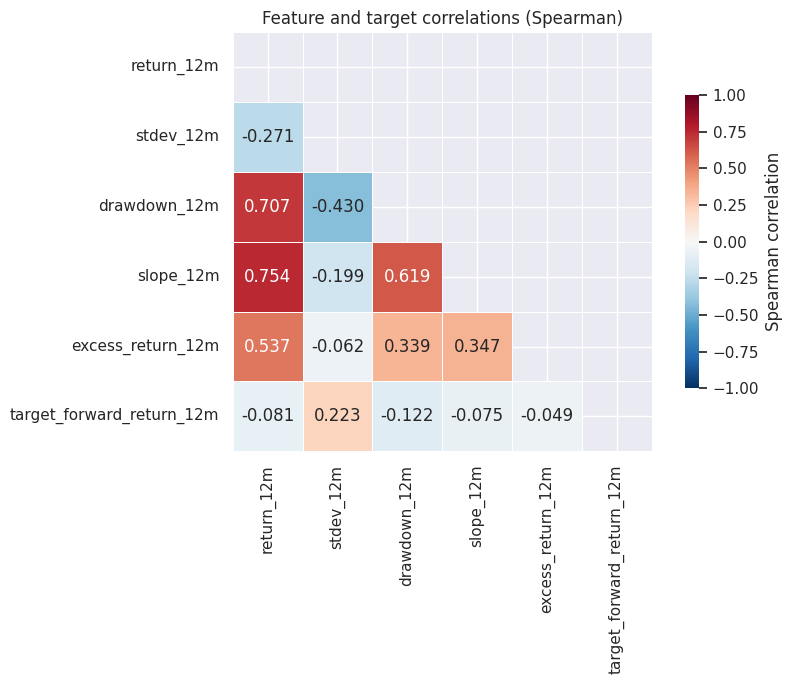


Pearson correlations (for comparison):
                           return_12m  stdev_12m  drawdown_12m  slope_12m  \
return_12m                      1.000     -0.406         0.808      0.646   
stdev_12m                      -0.406      1.000        -0.537     -0.198   
drawdown_12m                    0.808     -0.537         1.000      0.463   
slope_12m                       0.646     -0.198         0.463      1.000   
excess_return_12m               0.560     -0.153         0.369      0.307   
target_forward_return_12m      -0.084      0.239        -0.146     -0.061   

                           excess_return_12m  target_forward_return_12m  
return_12m                             0.560                     -0.084  
stdev_12m                             -0.153                      0.239  
drawdown_12m                           0.369                     -0.146  
slope_12m                              0.307                     -0.061  
excess_return_12m                      1.000      

In [16]:
# Build the correlation matrix between the five features and the target.
# We use Spearman correlation rather than Pearson because some features
# (notably drawdown, which is zero most of the time) are not normally
# distributed and Pearson is sensitive to that. Spearman is rank-based
# and more robust to skewed distributions.
#
# Note: Chapter 4 used Pearson correlation as the default. We switch
# to Spearman here because of the drawdown distribution issue, but
# this is a judgment call worth flagging. We will check both at the end.

corr_matrix = df_dataset_clean[required_cols].corr(method='spearman')

# Build the masked upper triangle so we don't show duplicate information.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap.
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,             # show numeric values in each cell
    fmt='.3f',              # 3 decimal places
    cmap='RdBu_r',          # red-blue diverging palette, red = positive
    center=0,               # zero is the midpoint of the color scale
    vmin=-1, vmax=1,        # explicit range so the scale is fixed
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation', 'shrink': 0.7},
    ax=ax
)
ax.set_title('Feature and target correlations (Spearman)', fontsize=12)
plt.tight_layout()
plt.show()

# Also print Pearson correlations for comparison so the reader can
# see whether the choice of method changes the picture.
print()
print("Pearson correlations (for comparison):")
print(df_dataset_clean[required_cols].corr(method='pearson').round(3))

The heatmap reveals two things that matter for the regression.

**1. Multicollinearity among the features.** The features are not independent; several pairs are strongly correlated.

- return and slope: Spearman 0.75 (Pearson 0.65). Both quantities measure "the market went up." Partially redundant.
- return and drawdown: Spearman 0.71 (Pearson 0.81). Mechanical: drawdown is min(0, return), so the negative half of return is reproduced inside drawdown.
- drawdown and slope: Spearman 0.62. Downstream of the first two; both are linked to return, so they are linked to each other.
- excess return and return: Spearman 0.54. Mechanical: excess return is return minus SPY's return.

The implication: OLS will struggle to assign distinct, stable coefficients. There are many ways to allocate predictive content across correlated features that produce nearly the same fit. Small changes in training data will produce different coefficients across the correlated features. WFA is built to surface exactly this kind of instability.

**2. Feature-target relationships are weak.**

Spearman correlations between features and the 12-month forward target:

- stdev_12m: +0.22 (the strongest)
- drawdown_12m: -0.12
- return_12m: -0.08
- slope_12m: -0.08
- excess_return_12m: -0.05

A correlation of 0.22 is not nothing in a financial-prediction context, but correlations that small mean the regression will explain very little of the variance in forward returns. We should expect R-squared in the 5-10% range at best. The strategy can still be useful at modest R-squared because we use the sign of the prediction, not the magnitude.

What stands out:

- **stdev_12m is the only feature with practically useful predictive value.** Higher trailing volatility is associated with higher future returns. Consistent with a risk-premium story.
- **return, drawdown, and slope all show mild mean-reversion.** Negative correlations in the same magnitude range. Sectors that have done well tend to slightly underperform going forward.
- **Pearson and Spearman agree directionally but differ in magnitude** for the return-vs-drawdown pair (0.81 vs 0.71). This reflects how Spearman handles the zero-inflated drawdown distribution. Qualitative message is the same.

What this means for the regression: predictive content is real but modest, multicollinearity will make individual coefficients unstable, and the strategy's success will depend less on strong predictive signals than on cross-sectional sorting working across regimes.

### 4.13 Scatter Plots: Each Feature vs the Target

The correlation matrix gave us a single number per feature pair. Scatter plots show the underlying shape of the relationship. We pick one sector and produce five small scatter plots, one for each feature against the forward target. Each plot includes a regression line so we can eyeball whether the linear relationship the OLS model assumes is a reasonable fit.

We use XLK (technology) for this view. It is the sector with the strongest cumulative return over our sample, which means it has the widest range of historical observations to look at, and it gives the regression line a meaningful spread to fit through. Picking a different sector would show a similar shape with different magnitudes; this is illustrative, not the regression itself.

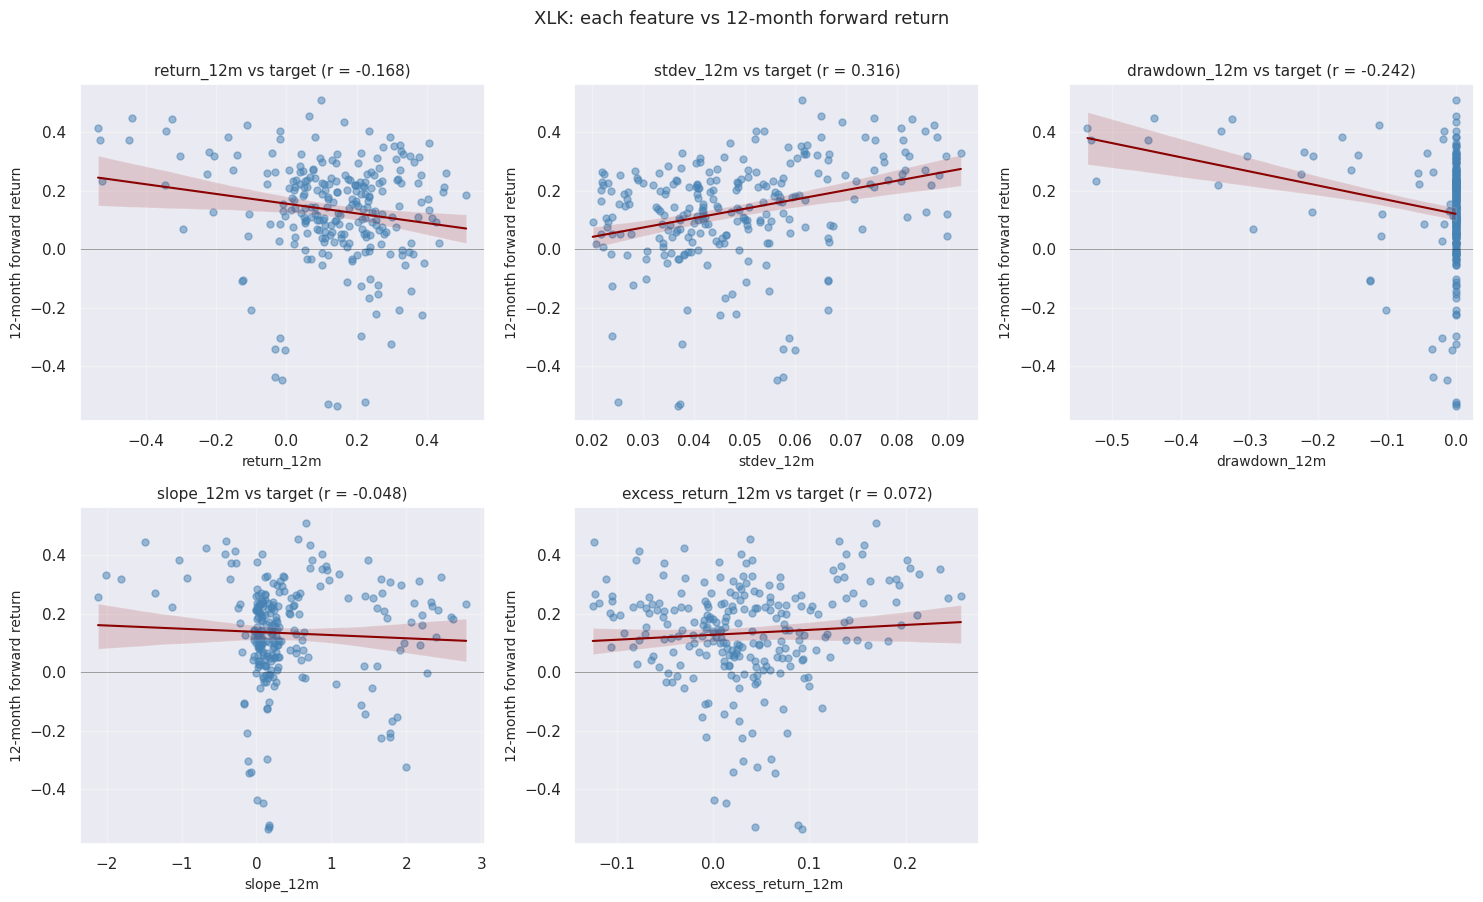


XLK correlations with forward target:
  return_12m          : XLK = -0.168,  pooled = -0.084
  stdev_12m           : XLK = +0.316,  pooled = +0.239
  drawdown_12m        : XLK = -0.242,  pooled = -0.146
  slope_12m           : XLK = -0.048,  pooled = -0.061
  excess_return_12m   : XLK = +0.072,  pooled = -0.063


In [17]:
# Scatter plots: each of the five features vs the forward target,
# for one sector, with a regression line overlaid. We use XLK as
# the sample sector for visualization.
sample_sector = 'XLK'
df_xlk = df_dataset_clean[df_dataset_clean['sector'] == sample_sector]

# Build a 2x3 grid of subplots. Five features means five scatter
# plots; we leave the sixth slot empty.
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    ax = axes[i]
    # Use seaborn's regplot for scatter + regression line + confidence band.
    sns.regplot(
        data=df_xlk,
        x=feature,
        y='target_forward_return_12m',
        ax=ax,
        scatter_kws={'alpha': 0.5, 's': 25, 'color': 'steelblue'},
        line_kws={'color': 'darkred', 'linewidth': 1.5},
        ci=95
    )
    # Compute the Pearson correlation for this feature-target pair
    # within the sample sector and show it on the plot.
    corr = df_xlk[feature].corr(df_xlk['target_forward_return_12m'])
    ax.set_title(f'{feature} vs target (r = {corr:.3f})', fontsize=11)
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('12-month forward return', fontsize=10)
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
    ax.grid(True, alpha=0.3)

# Hide the unused sixth subplot.
axes[5].axis('off')

plt.suptitle(f'{sample_sector}: each feature vs 12-month forward return',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

# Print the per-feature correlation with the target for XLK,
# and for comparison the same correlation across all sectors pooled.
print()
print(f"{sample_sector} correlations with forward target:")
for feature in feature_cols:
    xlk_corr = df_xlk[feature].corr(df_xlk['target_forward_return_12m'])
    pooled_corr = df_dataset_clean[feature].corr(df_dataset_clean['target_forward_return_12m'])
    print(f"  {feature:20s}: XLK = {xlk_corr:+.3f},  pooled = {pooled_corr:+.3f}")

The scatter plots make the picture concrete in a way the correlation matrix could not.

Three observations matter:

- **Relationships are weak.** Even the strongest predictor (stdev_12m, +0.32 for XLK) shows a wide cloud of points around the regression line. Modest predictive content. Expect low R-squared values from the fit, and do not be surprised if individual coefficients are not statistically significant.
- **The drawdown plot has a structural distortion.** About half the points sit on the vertical line at x = 0 (whenever trailing 12-month return was positive). The regression line is fit through a strange distribution: a dense vertical stripe at zero plus a smaller cloud of negative-x observations. The negative correlation comes mostly from the leftmost cluster (deep drawdowns followed by positive forward returns), which is the post-2008 recovery. Whether this generalizes is a regime-dependence question WFA will answer.
- **Slope shows almost no relationship for XLK** (correlation -0.05). Pooled correlation across all sectors is similarly small (-0.06). Slope is the feature most likely to contribute nothing useful, but we keep it because the paper specified it.

The XLK-vs-pooled correlation comparison is also informative. For every feature, the XLK correlation differs from the pooled correlation. This is exactly why the paper fits separate regressions per sector: the relationship between past performance and future returns is sector-specific. A pooled regression would average over these differences and lose them.

Going forward: the predictive content is real but modest, the features are correlated with each other, and per-sector relationships differ from pooled relationships. The regression has its work cut out. WFA will tell us whether what little signal exists is stable enough to bet on.

This is the end of Section 4. We have a clean dataset and a clear read on what it contains.

One last thing. Pause for a moment and notice how all the steps from previous chapters are coming together: data retrieval, cleaning, transformations, feature engineering, EDA. The 2nd edition's process-oriented structure was designed to build to exactly this kind of moment. From here we move into the strategy itself.

## Section 5: The Paper's Fit-Once-Then-Forward Backtest

Before we apply walk-forward analysis, we reproduce the paper's methodology as it was written. The paper fit one set of regression coefficients on a long in-sample period and then applied those frozen coefficients to a forward-test window. We do the same here. The result of this section is the methodological anchor we will compare WFA against.

To stay close to the paper's spirit while using our own data range, we split our 21-year clean dataset (January 2004 through December 2024) into two windows. We fit the regressions on the first 12 years (January 2004 through December 2015), which gives the model a generous training set including both the 2008 financial crisis and the 2009 to 2015 recovery. We then apply those frozen coefficients forward to the remaining 9 years (January 2016 through December 2024). The 2016 to 2024 forward window covers the late-cycle bull market, the 2020 COVID crash and recovery, the 2022 rate-driven drawdown, and the subsequent recovery. It is a varied test period.

The structure of this section follows three steps. First, we fit nine sector regressions on the in-sample window using statsmodels OLS. We inspect the fits and look at the coefficients, R-squared values, and t-statistics. Second, we generate predictions for every month in the forward-test window using the frozen coefficients applied to that window's features. Third, we run a monthly backtest in VectorBT using those predictions to drive the rebalancing rule, and report performance against SPY buy-and-hold.

The point of this section is to produce a baseline result the same way the paper would have produced it. The diagnostics WFA produces in later sections will then be measured against this baseline.

### 5.1 Fitting the Nine Sector Regressions

We fit one OLS regression per sector on the in-sample window. Each regression takes the same form: predict 12-month forward log return from the five features, plus an intercept. We use statsmodels OLS, fit on raw (unstandardized) features per the paper, and collect coefficients, R-squared, F-statistic, and t-statistics into a results table.

In [18]:
# Fit one OLS regression per sector on the in-sample window.
# In-sample window: January 2004 through December 2015 (12 years).
# Forward-test window: January 2016 through December 2024 (9 years).

in_sample_start  = '2004-01-01'
in_sample_end    = '2015-12-31'
test_start       = '2016-01-01'
test_end         = '2024-12-31'

# Filter the clean dataset to the in-sample window.
df_in_sample = df_dataset_clean[
    (df_dataset_clean['date'] >= in_sample_start) &
    (df_dataset_clean['date'] <= in_sample_end)
].copy()

print(f"In-sample observations:  {len(df_in_sample):,} rows")
print(f"In-sample date range:    {df_in_sample['date'].min().date()} to {df_in_sample['date'].max().date()}")
print(f"Observations per sector: {df_in_sample.groupby('sector').size().to_dict()}")
print()

# Storage for the fitted models, one per sector.
fitted_models = {}
fit_summary_rows = []

for sector in sector_cols:
    # Filter to this sector's observations within the in-sample window.
    df_sec = df_in_sample[df_in_sample['sector'] == sector]

    # Build the design matrix X (features) and the response vector y (target).
    # statsmodels does not add an intercept by default; we use sm.add_constant
    # to prepend a column of ones.
    X = sm.add_constant(df_sec[feature_cols].values)
    y = df_sec[target_col].values

    # Fit OLS.
    model = sm.OLS(y, X).fit()
    fitted_models[sector] = model

    # Extract the coefficients in the order: intercept, return_12m, stdev_12m,
    # drawdown_12m, slope_12m, excess_return_12m.
    coefs = dict(zip(['intercept'] + feature_cols, model.params))

    fit_summary_rows.append({
        'sector':       sector,
        'n_obs':        len(df_sec),
        'r_squared':    model.rsquared,
        'adj_r2':       model.rsquared_adj,
        'f_pvalue':     model.f_pvalue,
        **coefs,
    })

df_fit_summary = pd.DataFrame(fit_summary_rows).set_index('sector')

# Display the fit summary. We round for readability.
print("Fit summary across nine sector regressions:")
print()
print(df_fit_summary.round(4))

In-sample observations:  1,296 rows
In-sample date range:    2004-01-31 to 2015-12-31
Observations per sector: {'XLB': 144, 'XLE': 144, 'XLF': 144, 'XLI': 144, 'XLK': 144, 'XLP': 144, 'XLU': 144, 'XLV': 144, 'XLY': 144}

Fit summary across nine sector regressions:

        n_obs  r_squared  adj_r2  f_pvalue  intercept  return_12m  stdev_12m  \
sector                                                                         
XLV       144     0.1216  0.0898    0.0028    -0.0283      0.4855     1.6037   
XLI       144     0.4244  0.4036    0.0000    -0.1209      1.3600     1.4760   
XLY       144     0.3900  0.3679    0.0000    -0.0538     -0.2390     2.5957   
XLP       144     0.2763  0.2501    0.0000     0.0567      0.0030    -0.2798   
XLB       144     0.4180  0.3969    0.0000    -0.0886      1.0426     0.7525   
XLK       144     0.2150  0.1865    0.0000    -0.0427      0.3418     1.3434   
XLU       144     0.2967  0.2712    0.0000     0.1974      0.8517    -4.0811   
XLE       144 

Before we read the table, here is what each column means:

| Column | What it tells us |
|---|---|
| n_obs | Number of monthly observations the regression was fit on. With 12 years of monthly data per sector, this is 144 for every sector. |
| r_squared | Fraction of the variance in the forward target that the regression explains. Ranges from 0 (model explains nothing) to 1 (model explains everything). For financial-prediction regressions, values of 0.10 to 0.30 are typical and useful. |
| adj_r2 | Adjusted R-squared. Same idea as r_squared but penalizes for adding more features. Always slightly lower than r_squared. The adjustment is small with five features and 144 observations, so the two values are close. |
| f_pvalue | The p-value from the F-test, which tests one specific question: are all five slope coefficients simultaneously zero? A small p-value means we reject this null and conclude at least one feature is doing useful work. Values near zero are good. |
| intercept | The constant term in the regression. The predicted forward return when all five features equal zero. By itself it does not say much; it just shifts the line up or down. |
| return_12m, stdev_12m, drawdown_12m, slope_12m, excess_return_12m | The five slope coefficients, one per feature. Each tells us how the predicted forward return changes when that feature increases by one unit, holding the other four features constant. The size and sign of each coefficient is what the model has learned about that feature's relationship to the target. |

The F-test tells us that at least one feature is doing useful work. It does not tell us which one. We look at t-statistics next for that.

What the table shows:

- **R-squared values are higher than the EDA suggested.** Most sectors land in 20-40%. XLI and XLB lead at 0.42, XLY at 0.39. XLV is lowest at 0.12. Per-sector regressions pick up sector-specific relationships that pooled EDA washes out.
- **Every F-test rejects the null.** The highest p-value is XLV at 0.0028, well under 0.05. The models are finding something.
- **stdev_12m is positive for most sectors and large.** XLY at 2.60, XLE at 2.83. The exception is XLU at -4.08; for utilities, high recent volatility predicts weak forward returns (volatility spikes during economic stress).
- **drawdown_12m is negative for all nine sectors,** ranging from -0.07 to -1.74. Deeper trailing drawdowns predict better forward returns: a clean mean-reversion signal.
- **slope_12m is small and inconsistent across sectors.** Slope was the weakest feature in the EDA, and the regression confirms it.
- **return_12m and excess_return_12m vary in sign across sectors.** XLI and XLE positive (continuation), XLY and XLF negative (mean reversion). This per-sector heterogeneity is why we fit per-sector rather than one combined regression.

Two things to flag about what we are not seeing yet. We have not looked at individual coefficient significance (the t-statistics, next). And these coefficients were fit on 12 years of training data that includes the 2008 crisis. WFA will refit on shorter rolling windows, and we will see whether the relationships hold when the training data does not span the GFC.

### 5.2 Per-Feature Significance: T-Statistics

The F-test answered the question "are any of these features doing work." The t-statistics answer the more refined question: "for each feature individually, is its coefficient distinguishable from zero given the other features are in the model?"

Each fitted coefficient comes with a t-statistic and a p-value. Here is what each one tells us.

| Quantity | What it tells us |
|---|---|
| Coefficient | The estimated slope on the feature, what we already saw in the previous table. |
| Standard error | The estimated uncertainty around the coefficient. Larger standard errors mean the model is less sure about the coefficient's true value. |
| t-statistic | The coefficient divided by its standard error. A measure of how many "standard errors" the coefficient is away from zero. By rule of thumb, |t| greater than about 2 is statistically significant at the 5% level for samples this size. |
| p-value | The probability that we would observe a t-statistic this large in absolute value if the true coefficient were actually zero. A small p-value (typically less than 0.05) means we reject the null and conclude the coefficient is meaningfully different from zero. |

A small p-value does not mean the coefficient is large in practical terms. It just means we are confident it is not zero. A coefficient can be statistically significant but economically tiny (the model is sure that it is not zero, but it does not move the prediction much). And a coefficient can be economically large but statistically insignificant (the model has the right magnitude but is not certain about the sign). Both pieces of information matter.

A note on multiple testing. We are running nine regressions with five features each, which means 45 separate t-tests. By chance alone, at the 5% significance level, we would expect roughly 2 to 3 of those tests to come out significant even if no feature had any real predictive content. This is the false discovery problem we covered in Notebook 7.3. We will be aware of this when we read the table.

In [19]:
# Extract per-feature t-statistics and p-values from the fitted models.
# Each statsmodels OLS result object has .tvalues and .pvalues attributes
# that contain these per-coefficient.

# Build two DataFrames: one for t-statistics, one for p-values.
# Rows: sectors. Columns: intercept plus the five features.
coef_names = ['intercept'] + feature_cols

tstat_rows = []
pvalue_rows = []
for sector in sector_cols:
    model = fitted_models[sector]
    tstat_rows.append(dict(zip(coef_names, model.tvalues)))
    pvalue_rows.append(dict(zip(coef_names, model.pvalues)))

df_tstats   = pd.DataFrame(tstat_rows,   index=sector_cols)
df_pvalues  = pd.DataFrame(pvalue_rows,  index=sector_cols)

print("T-statistics for each coefficient (|t| > 2 is roughly significant at the 5% level):")
print()
print(df_tstats.round(2))
print()
print("P-values for each coefficient (less than 0.05 is significant at the 5% level):")
print()
print(df_pvalues.round(4))
print()

# Count how many of the 45 feature t-tests (excluding intercepts) are
# significant at the 5% level. Compare to what we would expect by chance.
feature_pvalues_only = df_pvalues[feature_cols]
n_significant = (feature_pvalues_only < 0.05).sum().sum()
n_total = feature_pvalues_only.size
expected_by_chance = n_total * 0.05

print(f"Feature t-tests significant at 5% level: {n_significant} of {n_total}")
print(f"Expected by chance alone:                {expected_by_chance:.1f}")

T-statistics for each coefficient (|t| > 2 is roughly significant at the 5% level):

     intercept  return_12m  stdev_12m  drawdown_12m  slope_12m  \
XLV      -0.58        2.07       1.31         -1.85      -0.14   
XLI      -3.23        6.26       2.06         -5.36      -1.43   
XLY      -0.99       -1.30       2.68         -0.27       1.58   
XLP       1.94        0.02      -0.31         -5.97       2.39   
XLB      -1.99        5.33       1.06         -4.71      -1.63   
XLK      -0.69        1.70       1.13         -4.12       0.54   
XLU       3.37        4.27      -3.03         -3.69      -3.69   
XLE      -1.96        4.52       2.03         -1.88      -3.87   
XLF      -0.57       -3.19       2.18         -2.70       4.50   

     excess_return_12m  
XLV               0.76  
XLI              -8.00  
XLY               3.79  
XLP              -4.28  
XLB              -8.21  
XLK              -4.29  
XLU              -7.17  
XLE              -3.61  
XLF               4.21  

P-v

This result is stronger than I expected and we should pause to talk about why before we move on.

Recall what the t-test is doing. For each individual coefficient, the t-test asks: if this feature actually had no relationship to forward returns, what is the chance we would see a coefficient this far from zero just by random luck? If that chance is less than 5% (a p-value below 0.05), we say the coefficient is "statistically significant" and treat it as a real signal rather than noise.

We ran 45 of these tests in total: 5 features times 9 sectors. Now here is the issue. If you flip 45 coins and ask "how many came up heads by chance," you expect roughly half. If you run 45 statistical tests and ask "how many came up significant by chance," you expect about 5% to come up significant just by random luck, even if none of the features actually predict anything. Five percent of 45 is about 2.2. So before looking at the table, the lazy benchmark is: in a world where these features are pure noise, we would still expect 2 or 3 of the tests to look significant.

We got 29 significant results out of 45. That is roughly 13 times more than we would see from pure noise. Even after accounting for the fact that we ran many tests, the model is finding real linear relationships in the in-sample data.

A few patterns are worth pulling out from the table.

The excess_return_12m feature is significant for 8 of the 9 sectors with very small p-values. The signs alternate across sectors. XLI and XLB show large negative coefficients, which means a sector that recently outperformed SPY is predicted to underperform going forward. XLY and XLF show the opposite: a sector that recently outperformed SPY is predicted to keep outperforming. The model is finding sector-specific information in relative performance.

The drawdown_12m feature is significant for 7 of the 9 sectors. All nine coefficients are negative. Translating: the deeper a sector's trailing 12-month loss, the higher the predicted forward return. This is a mean-reversion pattern showing up consistently.

The return_12m feature is significant for 6 of the 9 sectors. Like excess_return, the signs alternate across sectors.

The stdev_12m feature is significant for 5 of the 9 sectors. Mostly positive, except XLU at a strongly negative -3.03. For utilities, high recent volatility predicted weak forward returns over our in-sample window.

Slope is the weakest feature, significant for only 3 of the 9 sectors. The EDA already suggested slope had the lowest correlation with the target. The regression confirms it.

Now the question that actually matters.

All of this is in-sample. The regressions were fit on the 2004 to 2015 data. We are looking at how well the model explains the same data it was trained on. Of course it looks good. The model was given the answers and asked to find the patterns. The interesting question is whether these patterns will keep working when we apply the frozen model to data the model has not seen.

This is exactly the trap the paper's methodology can fall into. A model can produce strong-looking in-sample numbers in two very different ways. It can be picking up real relationships that will keep working forward, or it can be overfitting to the specific quirks of one historical window. The 2004 to 2015 window includes the 2008 financial crisis and the long recovery that followed. A model that has learned "the financial crisis happened and then sectors recovered" will look excellent on this window. Whether it will look excellent in a different period is a different question entirely.

We cannot tell from the in-sample fit alone whether we have the good kind of relationship or the overfit kind. The forward-test window is the first piece of out-of-sample evidence. WFA in later sections is the more rigorous version. For now, we have a fitted model with strong in-sample numbers and an open question.

### 5.3 Applying the Frozen Coefficients to the Forward Window

We now use the fitted models to predict forward returns for every month in the 2016 to 2024 test window. The coefficients stay exactly as they were fit on the 2004 to 2015 data; nothing is re-estimated. This is the discipline of a fit-once-then-forward backtest. The model we built on past data must stand or fall on its own when applied to data it has not seen.

For each month in the test window, we take that month's feature values for each sector, plug them into the sector's regression equation, and read off the predicted 12-month forward return. The trading rule from Section 3 then turns these predictions into target weights: equal-weight (at 1/9 each) across all sectors with positive predictions, with the rest of the portfolio in BIL.

The result is a monthly weight DataFrame ready to feed into VectorBT.

In [20]:
# Filter the clean dataset to the test window.
df_test = df_dataset_clean[
    (df_dataset_clean['date'] >= test_start) &
    (df_dataset_clean['date'] <= test_end)
].copy()

print(f"Test-window observations: {len(df_test):,} rows")
print(f"Test-window date range:   {df_test['date'].min().date()} to {df_test['date'].max().date()}")
print(f"Number of months:         {df_test['date'].nunique()}")
print()

# For each (date, sector) row in the test window, generate the prediction
# from that sector's frozen model. We add the prediction as a new column.
predictions = []
for _, row in df_test.iterrows():
    sector = row['sector']
    model  = fitted_models[sector]
    # Build the feature vector with the leading 1 for the intercept.
    x = np.array([1.0] + [row[f] for f in feature_cols])
    pred = model.params @ x   # dot product of coefficients with feature vector
    predictions.append(pred)

df_test['prediction'] = predictions

# Quick sanity check: predictions should be on a similar scale to the
# target itself (12-month log returns), so we expect most values in
# the -0.5 to +0.5 range.
print("Prediction summary across all test-window observations:")
print(df_test['prediction'].describe().round(4))
print()
print("Sample predictions for one date (December 2019):")
sample_date = '2019-12-31'
print(df_test[df_test['date'] == sample_date][['sector', 'prediction', 'target_forward_return_12m']].round(4).to_string(index=False))

Test-window observations: 972 rows
Test-window date range:   2016-01-31 to 2024-12-31
Number of months:         108

Prediction summary across all test-window observations:
count    972.0000
mean       0.1051
std        0.1958
min       -0.7324
25%        0.0204
50%        0.0904
75%        0.1878
max        1.1001
Name: prediction, dtype: float64

Sample predictions for one date (December 2019):
sector  prediction  target_forward_return_12m
   XLB      0.2059                     0.1864
   XLE      0.3014                    -0.3954
   XLF      0.1192                    -0.0180
   XLI      0.2721                     0.1036
   XLK      0.1025                     0.3619
   XLP      0.2100                     0.0963
   XLU      0.0375                     0.0053
   XLV      0.0929                     0.1248
   XLY      0.0881                     0.2596


The predictions look sensible. The summary across all 972 test-window observations shows predicted 12-month forward returns ranging from -0.73 to +1.10 with a median of 0.09 and a mean of 0.11. These are on the right scale for 12-month log returns. Some predictions are extreme but most fall in a plausible band.

The December 2019 sample shows what the model says about each sector at one specific point in time. All nine sectors have positive predictions, ranging from XLU at +3.7% to XLE at +30.1%. According to the model, this is a "buy everything" month: the strategy would equal-weight all nine sectors at 1/9 each, with no allocation to BIL.

Comparing predictions to actual forward returns at December 2019 also shows what the model gets right and wrong. XLB and XLI predictions were close to actual: predicted 21% and 27%, actual 19% and 10%. XLE was a major miss: predicted +30% and the actual forward return was -40% (the COVID crash). XLK was also missed in the other direction: predicted +10% and actual was +36% (tech leadership during the COVID rally). The model could not see the COVID crash coming, which no model could from December 2019 features. But it also missed the magnitude of tech outperformance.

Single-month accuracy is not what matters for the strategy. The strategy uses the sign of the prediction to decide whether to hold each sector at 1/9 weight. As long as the sign is right more often than wrong, and the wrong calls are not too costly, the strategy can work. The next step is to turn these predictions into monthly weights and run the backtest.

### 5.4 Turning Predictions Into Monthly Weights

The strategy rule from Section 3.1: at each month-end, equal-weight the sectors with positive predictions at 1/9 each. The remaining allocation goes to BIL. The 1/9 weight is constant regardless of how many sectors are in the buy list. If three sectors are positive, the portfolio holds 3/9 in those three sectors and 6/9 in BIL. If all nine are positive, the portfolio is fully invested with zero in BIL.

We build a monthly weight DataFrame in long format that VectorBT can consume directly. The format mirrors the features-and-target dataset: one row per (date, sector or BIL) with a weight column. We save this to parquet so the weights are inspectable and reusable, consistent with how we are saving every strategy's output through the chapter.

A note on dating. Each row's date is the month-end date when the prediction was generated. The weights apply to the holding period from that date forward to the next rebalance. VectorBT will consume these weights at the right timestamps when we run the backtest in the next subsection.

In [21]:
# Turn predictions into monthly weights for VectorBT.
#
# Build a long-format weights DataFrame: one row per (date, ticker)
# pair where ticker is one of the 9 sectors or BIL. Each row has a
# weight column.

# Step 1: Tag each row with whether it is a buy (prediction > 0) or not.
df_test = df_test.copy()
df_test['is_buy'] = df_test['prediction'] > 0

# Step 2: For each month, assign 1/9 weight to each buy sector,
# 0 to non-buy sectors. We compute this as a vectorized operation.
df_test['weight'] = np.where(df_test['is_buy'], 1.0 / 9.0, 0.0)

# Step 3: For each month, compute the BIL allocation as 1 minus the
# sum of sector weights for that month. If 6 sectors are positive,
# sector weights sum to 6/9 and BIL gets 3/9.
sector_sum_per_month = df_test.groupby('date')['weight'].sum()
bil_weights_per_month = 1.0 - sector_sum_per_month

# Step 4: Build the BIL rows.
bil_rows = pd.DataFrame({
    'date':   bil_weights_per_month.index,
    'sector': 'BIL',
    'weight': bil_weights_per_month.values,
})

# Step 5: Combine sector weights and BIL weights into one long DataFrame.
# We keep only the columns relevant for VectorBT input: date, sector, weight.
df_sector_weights = df_test[['date', 'sector', 'weight']]
df_weights_anchor = pd.concat([df_sector_weights, bil_rows], ignore_index=True)
df_weights_anchor = df_weights_anchor.sort_values(['date', 'sector']).reset_index(drop=True)

# Verify the math: sector weights for each month should sum to 1 (sectors plus BIL).
weight_sum_check = df_weights_anchor.groupby('date')['weight'].sum().round(6)
print(f"Weight sums per month (first 5 and last 5):")
print(f"  First 5: {weight_sum_check.head(5).values}")
print(f"  Last 5:  {weight_sum_check.tail(5).values}")
print(f"  All sum to 1.0: {(weight_sum_check == 1.0).all()}")
print()

# Show a snapshot of the weights for a recent date.
sample_date = '2024-01-31'
print(f"Weights for {sample_date}:")
print(df_weights_anchor[df_weights_anchor['date'] == sample_date].round(4).to_string(index=False))

# Save the weights to parquet for inspection and reuse.
output_path = 'ch9_anchor_strategy_weights.parquet'
df_weights_anchor.to_parquet(output_path, index=False)
print()
print(f"Saved {len(df_weights_anchor):,} rows to {output_path}")

Weight sums per month (first 5 and last 5):
  First 5: [1. 1. 1. 1. 1.]
  Last 5:  [1. 1. 1. 1. 1.]
  All sum to 1.0: True

Weights for 2024-01-31:
      date sector  weight
2024-01-31    BIL  0.0000
2024-01-31    XLB  0.1111
2024-01-31    XLE  0.1111
2024-01-31    XLF  0.1111
2024-01-31    XLI  0.1111
2024-01-31    XLK  0.1111
2024-01-31    XLP  0.1111
2024-01-31    XLU  0.1111
2024-01-31    XLV  0.1111
2024-01-31    XLY  0.1111

Saved 1,080 rows to ch9_anchor_strategy_weights.parquet


The weights are built and the math checks out. Every month sums to exactly 1.0, confirming the cash sleeve is correctly absorbing whatever is not in sectors.

The January 2024 snapshot shows what happened that month: all nine sectors had positive predictions, so the portfolio is fully invested at 1/9 in each sector with zero in BIL. This is what the strategy looks like during a "buy everything" month.

The full weight DataFrame has 1,080 rows: 108 months times 10 tickers (9 sectors plus BIL). It is saved to ch9_anchor_strategy_weights.parquet and is now ready to feed into VectorBT.

### 5.5 Running the Anchor Backtest in VectorBT

We feed the monthly weights into VectorBT and run the backtest at monthly frequency. Same approach we will use for every backtest in this notebook: actual adjusted close prices, monthly weights pivoted to wide format, target-percent sizing, cash sharing across the basket, fees and slippage as separate parameters.

A few setup details worth flagging before the code.

We use BIL's actual price series as the cash sleeve. The data starts in May 2007 and our test window starts in January 2016, so BIL has nine years of price history before we ever need it. No alignment issues.

Fees and slippage are set to 5 basis points each, the same values from Notebook 9.1. These are realistic for monthly rebalancing on liquid sector ETFs.

The benchmark is SPY buy-and-hold over the same window. SPY is a fair comparison because it is what most retail investors actually hold, and the strategy's premise is that sector rotation can deliver value beyond the cap-weighted index.

A note on the metrics toolkit. Chapter 7's calculate_performance_metrics defaults to annualizing as if the input is daily data (252 periods per year). Our backtest is monthly, so we pass periods_per_year=12 to every call. This applies to every monthly backtest in this notebook. If you forget the parameter, the toolkit will produce annualization values that are wildly inflated (Sharpe ratios in the teens, CAGR in the hundreds of percent) because it is treating monthly returns as if there were 252 of them per year instead of 12.

We then extract the monthly return stream from the VectorBT portfolio and feed it through the Chapter 7 metrics toolkit for the authoritative performance numbers.

In [22]:
# Resample the daily prices to month-end for the monthly backtest.
# This is the same df_prices_monthly we built in Section 4.1, but
# we also need BIL on the same monthly grid for the cash sleeve.
df_prices_monthly_full = df_prices.resample('ME').last()

# Trim to the test window.
df_prices_test_window = df_prices_monthly_full.loc[test_start:test_end]

# Pivot the long-format weights DataFrame to wide format. Rows are
# dates, columns are tickers. VectorBT will consume this as the
# target-weights input.
df_weights_wide = df_weights_anchor.pivot(
    index='date', columns='sector', values='weight'
)

# Reorder the columns to match the price DataFrame so VectorBT can
# align tickers correctly.
ticker_order = sector_cols + ['BIL']
df_weights_wide = df_weights_wide[ticker_order]
df_prices_test_window = df_prices_test_window[ticker_order]

# Confirm shapes line up.
print(f"Prices shape (test window):  {df_prices_test_window.shape}")
print(f"Weights shape (test window): {df_weights_wide.shape}")
print(f"Date alignment OK: {(df_prices_test_window.index == df_weights_wide.index).all()}")
print()

# Set fees and slippage as in Notebook 9.1.
fees     = 0.0005
slippage = 0.0005

# Run the strategy backtest in VectorBT.
pf_strategy = vbt.Portfolio.from_orders(
    close        = df_prices_test_window,
    size         = df_weights_wide,
    size_type    = 'targetpercent',
    group_by     = True,
    cash_sharing = True,
    call_seq     = 'auto',
    fees         = fees,
    slippage     = slippage,
    freq         = 'ME'
)

# Run a SPY buy-and-hold benchmark on the same monthly window.
df_spy_test = df_prices_monthly_full[['SPY']].loc[test_start:test_end]
df_bench_weights = pd.DataFrame(
    np.nan, index=df_spy_test.index, columns=['SPY']
)
df_bench_weights.iloc[0] = 1.0

pf_bench = vbt.Portfolio.from_orders(
    close        = df_spy_test,
    size         = df_bench_weights,
    size_type    = 'targetpercent',
    group_by     = True,
    cash_sharing = True,
    call_seq     = 'auto',
    fees         = fees,
    slippage     = slippage,
    freq         = 'ME'
)

# Extract the monthly return streams from each portfolio.
strategy_returns = pf_strategy.returns()
bench_returns    = pf_bench.returns()

# Run both through the Chapter 7 metrics toolkit. Same as every
# other backtest in the chapter: the toolkit is the authoritative
# source of performance numbers, not VectorBT's built-in stats.
metrics_strategy = calculate_performance_metrics(strategy_returns, periods_per_year=12)
metrics_bench    = calculate_performance_metrics(bench_returns,    periods_per_year=12)

# Build the comparison table.
df_anchor_results = pd.DataFrame({
    'Anchor strategy (paper methodology)': metrics_strategy,
    'SPY buy-and-hold':                    metrics_bench,
})

print("Anchor backtest performance, January 2016 to December 2024:")
print()
print(df_anchor_results.round(4))

Prices shape (test window):  (108, 10)
Weights shape (test window): (108, 10)
Date alignment OK: True

Anchor backtest performance, January 2016 to December 2024:

                        Anchor strategy (paper methodology) SPY buy-and-hold
Total Return                                        158.39%          252.44%
Ann. Return (CAGR)                                   11.12%           15.02%
Ann. Volatility                                      12.16%           15.38%
Downside Deviation                                    7.67%            9.61%
Max Drawdown                                        -21.69%          -23.93%
Max DD Duration (days)                                   12               23
Ulcer Index                                           4.170            6.620
Sharpe Ratio                                          0.914            0.977
Sortino Ratio                                         1.450            1.564
Calmar Ratio                                          0.513       

The anchor strategy returned 11.12% annualized over the 9-year forward window, against SPY's 15.02%. The strategy underperformed the benchmark by roughly 4 percentage points of CAGR per year. Volatility was 12.16% versus SPY's 15.38%, so the strategy did smooth the ride somewhat. The maximum drawdown was nearly identical at around 22%.

The risk-adjusted metrics are where this gets interesting. The Sharpe ratio of 0.914 is below SPY's 0.977 but the difference is small. Sortino is 1.450 versus 1.564, also close. Calmar is 0.513 versus 0.628, where SPY does pull ahead more meaningfully (because the strategy gave up significant return relative to a similar drawdown). The Ulcer Performance Index actually favors the strategy at 2.667 versus 2.270, because the strategy spent less time in shallow drawdowns even though its peak loss was similar.

This is roughly the inverse of what the paper reported. The paper showed the strategy beating SPY on all risk-adjusted metrics over its 2000 to 2015 sample. Our reproduction over 2016 to 2024 shows the strategy beating SPY on ulcer-based metrics but losing on Sharpe, Sortino, and Calmar.

Two things to flag before we read too much into this.

First, a 4-point CAGR gap is real but not catastrophic. The strategy underperformed but it did not disintegrate. It produced a reasonable equity-like return profile with somewhat lower volatility. A practitioner looking only at this anchor backtest would probably conclude the strategy works modestly but is dominated by SPY on most risk-adjusted measures.

Second, this is exactly one experiment with one outcome, and that is the methodological problem we set up at the start of the chapter. The strategy was fit on 2004 to 2015 and tested on 2016 to 2024. The 2016 to 2024 forward window happens to be a strong bull market for SPY, which mechanically disadvantages any defensive strategy. A different forward window might have given a different verdict. We cannot tell from this single backtest whether the relationships the model learned in 2004 to 2015 are durable across regimes, or whether they happened to work modestly in 2016 to 2024 by luck of the regime.

This is the question walk-forward analysis is built to answer. WFA refits the model on a rolling basis, so each test window has a model trained on data ending immediately before that window. We get many test windows across many regimes instead of one. The verdict from many windows is qualitatively different evidence than the verdict from one.

Before we move on, one more thing worth doing on the anchor result. We have the underperformance number (4 points of CAGR), but we have not looked at how the strategy got there. Did it underperform smoothly across the whole 9-year window, or was the drag concentrated in specific periods? A simple equity curve plot will tell us, and it sets up the per-window analysis WFA will produce later.

### 5.6 Equity Curve: Anchor Strategy vs SPY

We plot the cumulative growth of $1 invested in the anchor strategy alongside the same dollar invested in SPY buy-and-hold. The chart shows whether the underperformance built up gradually across the 9-year window or was concentrated in specific periods.

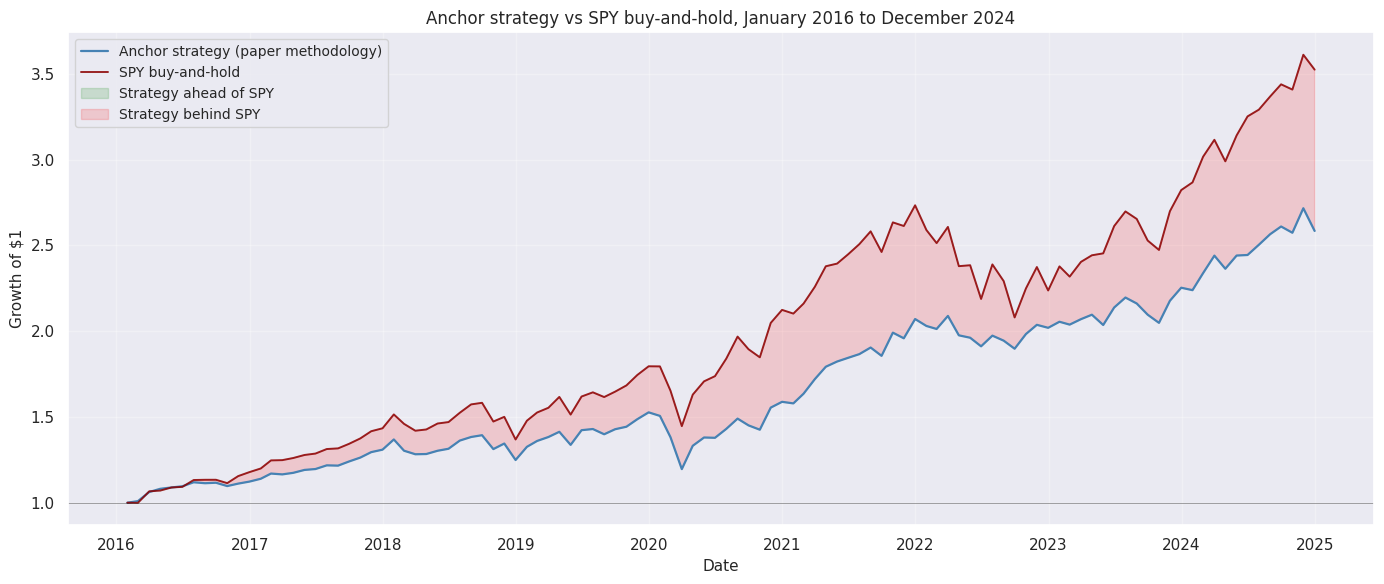


Cumulative growth at key dates:
Date         Strategy     SPY          Gap       
--------------------------------------------------
2017-12-31   1.308        1.433        -0.125
2019-12-31   1.526        1.794        -0.269
2020-12-31   1.587        2.123        -0.536
2022-12-31   2.019        2.237        -0.218
2024-12-31   2.584        3.524        -0.941


In [23]:
# Build cumulative growth-of-$1 curves from each portfolio's monthly returns.
strategy_eq = (1 + strategy_returns).cumprod()
bench_eq    = (1 + bench_returns).cumprod()

# Plot both equity curves together with shading where the strategy
# was ahead vs behind SPY, so the eye can see where the gap built up.
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(strategy_eq.index, strategy_eq,
        color='steelblue', linewidth=1.6,
        label='Anchor strategy (paper methodology)')
ax.plot(bench_eq.index, bench_eq,
        color='darkred', linewidth=1.4, alpha=0.85,
        label='SPY buy-and-hold')

# Shade the gap between the two equity curves to make the relative
# performance visible at a glance.
ax.fill_between(strategy_eq.index, strategy_eq, bench_eq,
                where=(strategy_eq > bench_eq),
                alpha=0.15, color='green',
                label='Strategy ahead of SPY')
ax.fill_between(strategy_eq.index, strategy_eq, bench_eq,
                where=(strategy_eq <= bench_eq),
                alpha=0.15, color='red',
                label='Strategy behind SPY')

ax.set_title('Anchor strategy vs SPY buy-and-hold, January 2016 to December 2024',
             fontsize=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Growth of $1', fontsize=11)
ax.axhline(1.0, color='black', linewidth=0.6, alpha=0.4)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Also print the cumulative gap at a few key dates so we can see
# in numbers how the relative performance evolved.
key_dates = ['2017-12-31', '2019-12-31', '2020-12-31', '2022-12-31', '2024-12-31']
print()
print("Cumulative growth at key dates:")
print(f"{'Date':<12} {'Strategy':<12} {'SPY':<12} {'Gap':<10}")
print("-" * 50)
for d in key_dates:
    if pd.Timestamp(d) in strategy_eq.index:
        s = strategy_eq.loc[d]
        b = bench_eq.loc[d]
        gap = s - b
        print(f"{d:<12} {s:<12.3f} {b:<12.3f} {gap:+.3f}")

The chart shows the strategy never had a sustained period of outperformance against SPY in the 9-year window. The gap progression:

- **2016-2017: tracking close.** Strategy roughly in line with SPY.
- **2018-2019: gap begins to widen.** End of 2017, strategy 12 cents per dollar behind. End of 2019, 27 cents behind.
- **2020: COVID drawdown, then SPY runs.** End of 2020, gap at 54 cents (worst point so far). The strategy holds up modestly during the March crash but gives back ground during recovery.
- **2022: defensive moment.** Both lines drop, but the strategy holds up better. Gap narrows from 54 cents back to 22 cents.
- **2023-2024: SPY runs again.** End of 2024, gap at 94 cents (worst of the entire period).

Two readings of this:

- **Bullish framing:** The strategy is a defensive variant of equity exposure. The 2016-2024 forward window was a strong-bull-market period; defensive variants always lag during these. Same logic as VIXY in Notebook 9.1.
- **Bearish framing:** The defensive value during stress (modest help in 2020, real help in 2022) was not enough to offset the persistent drag during calm periods. The cumulative gap suggests the strategy gave back more during calm than it saved during stress.

The bigger problem with both readings: this is one window with one set of regime characteristics. We cannot tell from a single backtest whether the relationships the model learned in 2004-2015 are durable across regimes, or whether they happened to work modestly in 2016-2024 by luck of the regime.

That is exactly the question WFA is built to answer. Section 6 next.

## Section 6: Walk-Forward Analysis with Expanding Window

The anchor backtest in Section 5 reproduced the paper's methodology. We fit the regressions once on a long in-sample window, applied those frozen coefficients to a forward-test window, and reached a verdict on that one experiment. The verdict was modest underperformance against SPY, with regime-dependent gap dynamics.

That verdict has the same fundamental limitation we discussed in Notebook 9.1. It is one experiment with one outcome. We do not know whether the result reflects the strategy's true behavior across regimes, or whether the test window happened to be a particularly favorable or unfavorable period for it. We do not know whether the regression coefficients we fit on 2004 to 2015 would still hold up if we had fit them on different historical data. We have one number where we need a pattern.

Walk-forward analysis is the structural answer. Instead of one fit-once-then-forward, we run many fit-and-forwards in sequence. Each year we refit the regressions on data ending immediately before that year, then test on the year that follows. We end up with many test windows across many regimes, each with its own set of coefficients and its own performance result. The pattern across windows is what tells us whether the strategy works.

### 6.1 Two Flavors of WFA: Expanding vs Rolling

There are two main ways to set up WFA, and the choice between them is genuinely interesting. We are going to run both. Section 6 covers expanding window. Section 7 covers rolling window. Section 8 onward diagnoses them both together.

In an expanding window WFA, the training window grows with each step. The first test fold is trained on the earliest available data. The second test fold is trained on the earliest data plus everything that has happened up to the start of that fold. By the last test fold, the training window contains essentially the entire history. Older data is never discarded; the model is given access to everything that has been observed.

In a rolling window WFA, the training window has a fixed length. As the test fold advances forward in time, the start of the training window also advances. Old data falls off the back as new data is added at the front. The model is always trained on the most recent N years of data, regardless of how many years are available.

The two configurations answer different questions about a strategy.

Expanding window asks: does the strategy work when the model has access to all historical data? It assumes that older data is informative and should not be thrown away. The model should learn from everything available and apply that learning forward.

Rolling window asks: does the strategy work when the model is retrained on only the most recent data? It assumes that relationships in financial markets drift over time, and that old data may mislead the model about current conditions.

For our regression strategy, expanding window has two practical advantages. First, the regression has five features and an intercept, which means it needs a meaningful number of observations to produce stable coefficients. Expanding window starts thin (around 36 effective observations in the 2008 test fold after the lookahead truncation we will discuss next) and grows steadily. By the 2024 test fold the model is fitting on more than 240 observations, which is comfortable for a five-parameter regression. Rolling window with a four-year configuration stays at roughly 36 effective observations for every fold, which is statistically thin throughout the WFA period.

Second, the relationships the strategy is trying to capture (mean reversion, the volatility-return premium, sector momentum) do not have an obvious reason to drift dramatically over time. They are structural economic relationships. There is no strong argument that data from 2005 should be considered stale by 2020.

Rolling window is not without merit, though. It is the standard textbook configuration for a reason: it adapts faster to regime changes, and it gives every test fold the same amount of training data so the model's behavior is more comparable across folds. If the underlying relationships did change meaningfully at some point in our sample (post-2014 sector dynamics may genuinely differ from pre-2014), expanding window will be slow to detect this because each new year of data is only a small fraction of the total training set.

Running both configurations is the way to handle this. If both produce similar conclusions about the strategy, we have strong evidence. If they produce different conclusions, that itself is informative: it means the strategy's apparent success or failure depends on whether we treat old data as informative or stale, and that is a finding worth surfacing.

Section 6 builds expanding window first because that is what the regression's data-hungry nature recommends. Section 7 then runs rolling as the alternative, and Section 8 onward compares them.

### 6.2 Setting Up Each WFA Fold (and Avoiding a Subtle Lookahead Trap)

Before we run the loop, we need to be careful about one thing that catches a lot of WFA implementations on regression strategies. It is the kind of issue that sounds technical but actually matters for whether the WFA results are valid.

Here is the setup. We are about to train regressions on past data and use them to predict the future. For the first WFA test fold (calendar 2008), we want to train on everything we knew before 2008 began.

The natural intuition is "use every row in the dataset that is dated before 2008." That intuition is wrong. Let me show you why.

Look at the row dated December 31, 2007 in our dataset. It has:

- Features: computed from data through December 31, 2007
- Target: cumulative return from January 1, 2008 through December 31, 2008

The target is the answer key. It is what the regression learns to predict from the features. Now read that target carefully. The target on the December 31, 2007 row is what happened during all of 2008.

If we include the December 31, 2007 row in training, the regression sees: "given these features, the actual 12-month forward return was Y." That Y is calendar 2008. The model is being trained on calendar 2008's outcomes.

We then ask the model to predict for January 2008. The prediction it produces uses coefficients that were estimated, in part, by looking at what happened in 2008. The model has not literally been given a list of 2008 returns, but the coefficients absorbed information from 2008 during training.

This is leakage. The test fold cannot be a fair evaluation when the training set already absorbed information from inside the test fold.

It is not just the December 31, 2007 row. Every row from January 2007 through December 2007 has a target that extends into 2008 to some degree. The November 30, 2007 row's target runs from December 2007 through November 2008, so 11 months of its target are inside the test fold. The June 30, 2007 row's target runs from July 2007 through June 2008, so 6 months of its target are inside the test fold. Every row in 2007 leaks at least some of 2008 into training.

The fix is to drop all of those rows from training. For the 2008 test fold, the training set ends at December 31, 2006. The December 31, 2006 row's target is calendar 2007, which does not overlap the 2008 test fold. That row is safe. Every row before it is also safe. Every row in 2007 gets dropped to prevent the leak.

Stating this as a general rule: for any test fold starting in calendar year T, the training cutoff is December 31 of year T minus 2. Not T minus 1, which would have left 2007 in the training set for the 2008 test fold. The extra year is what protects against the forward-looking target leaking into the test period.

The cost of this fix is one year of training data per fold. For the 2008 test fold, expanding window training runs from January 2004 through December 2006, giving 36 monthly observations per sector. For the 2024 test fold, training runs from January 2004 through December 2022, giving 228 observations per sector. The expanding window still gets larger as the WFA progresses, just with one fewer year than the naive setup would have given us.

Why does this matter so much? Because it is the difference between a valid WFA and a contaminated one. A contaminated WFA can produce excellent-looking results that are not reproducible in real time. The whole point of WFA is to simulate what the strategy would have done in real time, and in real time we cannot know what 2008 looks like before 2008 happens. The training cutoff has to respect that.

### 6.3 WFA Configuration

We define the configuration for the expanding window WFA. The constants below are referenced throughout the loop and the diagnostics.

The first WFA test fold is calendar year 2008. The reasoning was set out earlier in the session: 2008 contains the global financial crisis, which is the single most informative regime event in our data. Putting it inside a test fold rather than burying it inside training lets us see how the strategy actually behaved during that crisis with a model that did not yet know the crisis was coming.

The training data starts at January 2004, the first month of the clean dataset. For the expanding window, the training start date is fixed and only the training end date moves forward as the loop advances.

The test fold is one calendar year. The step size is also one calendar year, so test folds do not overlap. With clean data running through December 2024, we have 17 test folds: 2008, 2009, ..., 2024.

The training cutoff for each fold is December 31 of the year that is two years before the test year, applying the lookahead protection we set up in Section 6.2.

In [24]:
# WFA configuration constants. We define them once at the top so the
# loop and the downstream diagnostics can reference them.

# First test fold and last test fold (calendar years).
first_test_year = 2008
last_test_year  = 2024

# List of test folds, one per calendar year.
test_years = list(range(first_test_year, last_test_year + 1))

# Training data start date for the expanding window. Fixed across folds.
expanding_train_start = pd.Timestamp('2004-01-01')

print(f"WFA configuration:")
print(f"  Test folds:                {len(test_years)} years")
print(f"  First test fold:           {test_years[0]}")
print(f"  Last test fold:            {test_years[-1]}")
print(f"  Training start (expanding):{expanding_train_start.date()}")
print(f"  All test folds:            {test_years}")

WFA configuration:
  Test folds:                17 years
  First test fold:           2008
  Last test fold:            2024
  Training start (expanding):2004-01-01
  All test folds:            [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


### 6.4 Building the Expanding Window WFA Loop

We build the WFA loop step by step. The loop produces three outputs across all 17 test folds, and we collect them as we go:

1. Per-fold per-sector regression coefficients, for the coefficient stability analysis later.
2. Per-fold per-sector predictions, one prediction per month per sector across the entire WFA period.
3. Per-fold weight rows that, when assembled, give us a continuous monthly weight series for the backtest.

We split the work into three cells. The first cell runs the loop itself: fit the regressions, generate predictions, and store the coefficients. The second cell takes the predictions and applies the trading rule to build the weights. The third cell verifies the math, summarizes what we built, and saves the result to parquet.

Splitting it this way mirrors the actual conceptual structure: the loop is one thing, the trading rule is another, the assembly and saving is a third. Reading them in three pieces is easier than reading them as one big block.

### 6.4.1 The WFA Loop: Fit Regressions, Generate Predictions

The loop iterates one test fold at a time. For each test year:

1. Determine the training cutoff date (December 31 of the year that is two years before the test year, per the lookahead-protection rule from Section 6.2).
2. Filter the clean dataset to all training observations on or before that date. For expanding window WFA, no lower bound is needed.
3. Fit nine sector regressions on the training data, one per sector, using the same OLS spec from Section 5.
4. Use the fitted models to generate predictions for every month in the test fold.
5. Store the per-sector coefficients and per-month predictions for later use.

This is the core mechanic of WFA: refit the model on each window's training data, then apply the freshly-fit model to that window's test data. The loop runs the same fit-and-predict logic from Section 5, but seventeen times with rolling cutoffs.

In [25]:
# Storage for outputs across all WFA folds.
# coef_rows: per-fold per-sector coefficients, for the stability analysis
# pred_rows: per-fold per-sector predictions, one row per (date, sector)
coef_rows = []
pred_rows = []

# Iterate over the 17 test folds.
for test_year in test_years:
    # Define the training cutoff: last day of the year two years BEFORE
    # the test year, applying the lookahead protection from Section 6.2.
    # For test_year=2008, training_cutoff = 2006-12-31.
    training_cutoff = pd.Timestamp(f'{test_year - 2}-12-31')

    # Define the test window: full calendar year of test_year.
    test_window_start = pd.Timestamp(f'{test_year}-01-01')
    test_window_end   = pd.Timestamp(f'{test_year}-12-31')

    # Training data: every clean-dataset row at or before the cutoff.
    # For expanding window WFA, we always include everything from the
    # start of the dataset; only the upper bound moves.
    df_train = df_dataset_clean[
        df_dataset_clean['date'] <= training_cutoff
    ]

    # Test data: every clean-dataset row inside the test window.
    df_test_fold = df_dataset_clean[
        (df_dataset_clean['date'] >= test_window_start) &
        (df_dataset_clean['date'] <= test_window_end)
    ]

    # Fit nine sector regressions, one per sector. Same OLS spec as
    # Section 5: features plus intercept.
    fitted_models_fold = {}
    for sector in sector_cols:
        df_sec_train = df_train[df_train['sector'] == sector]

        X = sm.add_constant(df_sec_train[feature_cols].values)
        y = df_sec_train[target_col].values

        model = sm.OLS(y, X).fit()
        fitted_models_fold[sector] = model

        # Record the coefficients for the stability analysis later.
        coef_dict = dict(zip(['intercept'] + feature_cols, model.params))
        coef_rows.append({
            'test_year': test_year,
            'sector':    sector,
            'n_train':   len(df_sec_train),
            'r_squared': model.rsquared,
            **coef_dict,
        })

    # Generate predictions for every (date, sector) in the test fold.
    for _, row in df_test_fold.iterrows():
        sector = row['sector']
        model  = fitted_models_fold[sector]
        x = np.array([1.0] + [row[f] for f in feature_cols])
        pred = model.params @ x
        pred_rows.append({
            'date':       row['date'],
            'sector':     sector,
            'prediction': pred,
            'target':     row[target_col],
        })

# Convert the lists of rows into DataFrames.
df_predictions     = pd.DataFrame(pred_rows)
df_coefs_expanding = pd.DataFrame(coef_rows)

# Quick check that the loop produced what we expected.
print(f"Loop output:")
print(f"  Coefficient rows: {len(df_coefs_expanding):,} ({len(test_years)} folds × {len(sector_cols)} sectors)")
print(f"  Prediction rows:  {len(df_predictions):,}")
print(f"  Months covered:   {df_predictions['date'].nunique()}")
print(f"  Date range:       {df_predictions['date'].min().date()} to {df_predictions['date'].max().date()}")

Loop output:
  Coefficient rows: 153 (17 folds × 9 sectors)
  Prediction rows:  1,836
  Months covered:   204
  Date range:       2008-01-31 to 2024-12-31


### 6.4.2 Applying the Trading Rule to Build Weights

The loop produced a prediction for every (date, sector) pair across the WFA period: 1,836 predictions in total, spanning 204 months and 9 sectors. The next step is to turn those predictions into the monthly weights that drive the backtest.

The trading rule is the same one from Section 5.4: for each month, equal-weight the sectors with positive predictions at 1/9 each, and let BIL absorb whatever is left over. If three sectors are positive, the portfolio holds 3/9 in those three sectors and 6/9 in BIL. If all nine are positive, the portfolio is fully invested with zero in BIL.

The math is identical to what we did for the anchor strategy in Section 5. The only thing that changes is the source of the predictions: now they come from 17 different models, each fit on a different training window with the lookahead protection applied, instead of one model fit on a single in-sample period.

In [26]:
# Apply the trading rule and build the weights in wide format.
# Wide format: rows are dates, columns are tickers (9 sectors plus BIL),
# values are weights. This is the format VectorBT consumes directly,
# and it makes the weight matrix easy to visualize and inspect.

# Step 1: tag each prediction row as buy or not-buy.
df_predictions['is_buy'] = df_predictions['prediction'] > 0

# Step 2: convert is_buy to a weight. Buys get 1/9, non-buys get 0.
df_predictions['weight'] = np.where(df_predictions['is_buy'], 1.0 / 9.0, 0.0)

# Step 3: pivot the long-format predictions to a wide weight matrix.
# Rows are dates, columns are sectors. Each cell is the weight for
# that sector on that date.
df_weights_wfa_expanding = df_predictions.pivot(
    index='date', columns='sector', values='weight'
)

# Step 4: add the BIL column. BIL gets whatever weight is left after
# the sector allocations. We compute it as 1 minus the row sum of
# sector weights.
df_weights_wfa_expanding['BIL'] = 1.0 - df_weights_wfa_expanding[sector_cols].sum(axis=1)

# Step 5: reorder columns so BIL appears last. This is purely cosmetic
# but it makes the matrix easier to read (sectors grouped together,
# cash sleeve at the end).
df_weights_wfa_expanding = df_weights_wfa_expanding[sector_cols + ['BIL']]

# Verification: every row should sum to exactly 1.0.
row_sums = df_weights_wfa_expanding.sum(axis=1).round(6)
print(f"Weight matrix shape: {df_weights_wfa_expanding.shape}")
print(f"Months covered: {len(df_weights_wfa_expanding)}")
print(f"Tickers (columns): {df_weights_wfa_expanding.columns.tolist()}")
print(f"All monthly weight sums equal 1.0: {(row_sums == 1.0).all()}")
print()
print("First 6 months of the weight matrix (start of WFA, 2008):")
print(df_weights_wfa_expanding.head(6).round(4))
print()
print("Last 6 months of the weight matrix (end of WFA, 2024):")
print(df_weights_wfa_expanding.tail(6).round(4))

Weight matrix shape: (204, 10)
Months covered: 204
Tickers (columns): ['XLV', 'XLI', 'XLY', 'XLP', 'XLB', 'XLK', 'XLU', 'XLE', 'XLF', 'BIL']
All monthly weight sums equal 1.0: True

First 6 months of the weight matrix (start of WFA, 2008):
sector         XLV     XLI     XLY     XLP     XLB  XLK     XLU     XLE  XLF  \
date                                                                           
2008-01-31  0.1111  0.1111  0.1111  0.0000  0.1111  0.0  0.1111  0.1111  0.0   
2008-02-29  0.1111  0.1111  0.1111  0.0000  0.1111  0.0  0.1111  0.1111  0.0   
2008-03-31  0.1111  0.1111  0.1111  0.0000  0.1111  0.0  0.1111  0.1111  0.0   
2008-04-30  0.1111  0.1111  0.1111  0.1111  0.1111  0.0  0.1111  0.1111  0.0   
2008-05-31  0.1111  0.1111  0.1111  0.0000  0.1111  0.0  0.1111  0.1111  0.0   
2008-06-30  0.1111  0.1111  0.0000  0.0000  0.1111  0.0  0.1111  0.1111  0.0   

sector         BIL  
date                
2008-01-31  0.3333  
2008-02-29  0.3333  
2008-03-31  0.3333  
2008-04-30  0.

The weights are ready. The strategy has 204 months of allocations covering 2008 through 2024, and every month sums to 1.0.

Two sample months show the model's behavior at notable points in the WFA period.

Entering 2008, the model is moderately defensive: 6 of 9 sectors as buys at 1/9 each, with BIL absorbing 33% of the portfolio. The model has not seen the financial crisis yet, so its January 2008 call reflects what was actually visible at the time: a long expansion, sectors mostly trending up, no clear signal that a major drawdown was imminent. The defensiveness comes from XLF, XLK, and XLP being predicted to underperform, but the rest of the portfolio is fully invested. Whether this call holds up through 2008 is something the backtest will tell us.

At the March 2020 COVID bottom, the model is aggressively constructive: 8 of 9 sectors as buys with only XLU sitting out, and BIL at 11%. The features in March 2020 looked extreme: deep drawdowns, elevated volatility, sharply negative recent returns. The mean-reversion coefficients (uniformly negative for drawdown_12m across all sectors, as we saw in Section 5) read those features and said "buy." With the benefit of hindsight, the next 12 months were exceptionally strong, but at the time this was a contrarian call.

Two extreme months, two opposite signals. The model's recommendations vary meaningfully across regimes, which is what we want from a regression strategy. A signal that always says the same thing across very different conditions is not really a signal.

The next step is to assemble everything, summarize what we built, and save the weights to parquet for the backtest.

### 6.4.3 Visualizing the Weight Matrix Over Time

The wide-format weight matrix lets us see at a glance how the strategy's allocations evolve across the WFA period. We use a stacked area chart: each ticker's weight is one band, and the bands stack to fill 100% at each date. Where BIL grows large, the strategy is defensive. Where BIL shrinks to zero, the strategy is fully invested across the sector pack.

The chart is also a good first read on regime conditioning. Periods where BIL dominates correspond to months where the regression model said "most sectors will not deliver" and pulled allocation out of equities. Periods where BIL is thin correspond to months where the model was constructive on most sectors. Watching this evolve through the 2008 crisis, the COVID period, and the 2022 drawdown will tell us whether the model's defensive instincts ever fired and when.

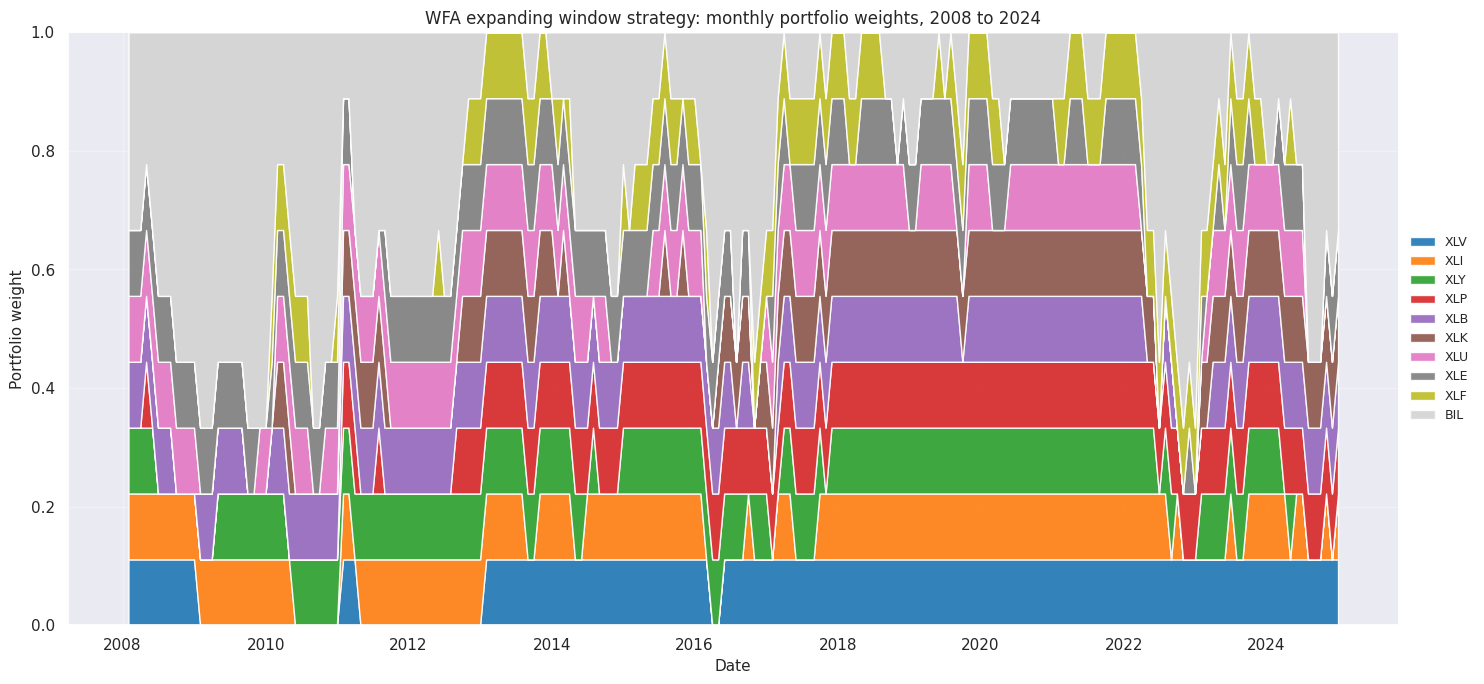


Summary of strategy positioning over the WFA period:
  Average BIL weight:        0.254
  Months fully invested (BIL = 0): 36 of 204
  Months heavily defensive (BIL > 0.5): 31 of 204

Average weight by ticker across the WFA period:
sector
XLV    0.086
XLI    0.087
XLY    0.093
XLP    0.084
XLB    0.099
XLK    0.069
XLU    0.081
XLE    0.090
XLF    0.057
BIL    0.254


In [27]:
# Stacked area chart of the weight matrix. Each band is one ticker;
# the bands stack to fill 100% at each date.

# Build a color palette. Nine sectors get distinct colors from a
# qualitative palette. BIL gets a neutral grey so the cash sleeve
# reads visually as "no equity."
sector_palette = sns.color_palette("tab10", n_colors=len(sector_cols))
colors = list(sector_palette) + ['lightgrey']
column_order = sector_cols + ['BIL']

fig, ax = plt.subplots(figsize=(15, 7))

# stackplot wants the columns as a list of arrays. We transpose the
# weight matrix so each row of the array is one ticker's time series.
ax.stackplot(
    df_weights_wfa_expanding.index,
    df_weights_wfa_expanding[column_order].T.values,
    labels=column_order,
    colors=colors,
    alpha=0.9
)

ax.set_title('WFA expanding window strategy: monthly portfolio weights, 2008 to 2024',
             fontsize=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Portfolio weight', fontsize=11)
ax.set_ylim(0, 1)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print a few summary statistics about the cash sleeve and equity
# allocation over time, so the reader has numbers to anchor the chart.
print()
print("Summary of strategy positioning over the WFA period:")
print(f"  Average BIL weight:        {df_weights_wfa_expanding['BIL'].mean():.3f}")
print(f"  Months fully invested (BIL = 0): {(df_weights_wfa_expanding['BIL'] == 0).sum()} of {len(df_weights_wfa_expanding)}")
print(f"  Months heavily defensive (BIL > 0.5): {(df_weights_wfa_expanding['BIL'] > 0.5).sum()} of {len(df_weights_wfa_expanding)}")
print()
print("Average weight by ticker across the WFA period:")
avg_weights = df_weights_wfa_expanding.mean().round(3)
print(avg_weights.to_string())

### 6.4.4 The Predictions Behind the Weights

The stacked area chart showed which sectors the strategy held when. Before we move on, we look at the underlying predictions that drove those weights. The weight rule turns each prediction into a binary decision (positive prediction means buy at 1/9, negative means do not buy), so the predictions themselves contain more information than the weights. The predictions tell us how confidently the model is making each call and how that confidence varies across regimes.

We plot one panel per sector and shade green where predictions are positive (buy zone) and red where they are negative (sell zone). We also count how often each sector was a buy across the full WFA period.

Three things to look for. First, do the buy/no-buy patterns make sense given what we know about each sector's history? Second, how big are the predictions in absolute terms across the period? Third, are the model's defensive calls (negative predictions) clustered around regime changes, or scattered randomly?

This chart is also worth keeping in mind as we move into Section 7. When we run the rolling window WFA there, we will produce the same chart on the rolling output and compare. The two configurations should produce visibly different prediction patterns; the difference is exactly what tells us how the choice between expanding and rolling affects the strategy's behavior.

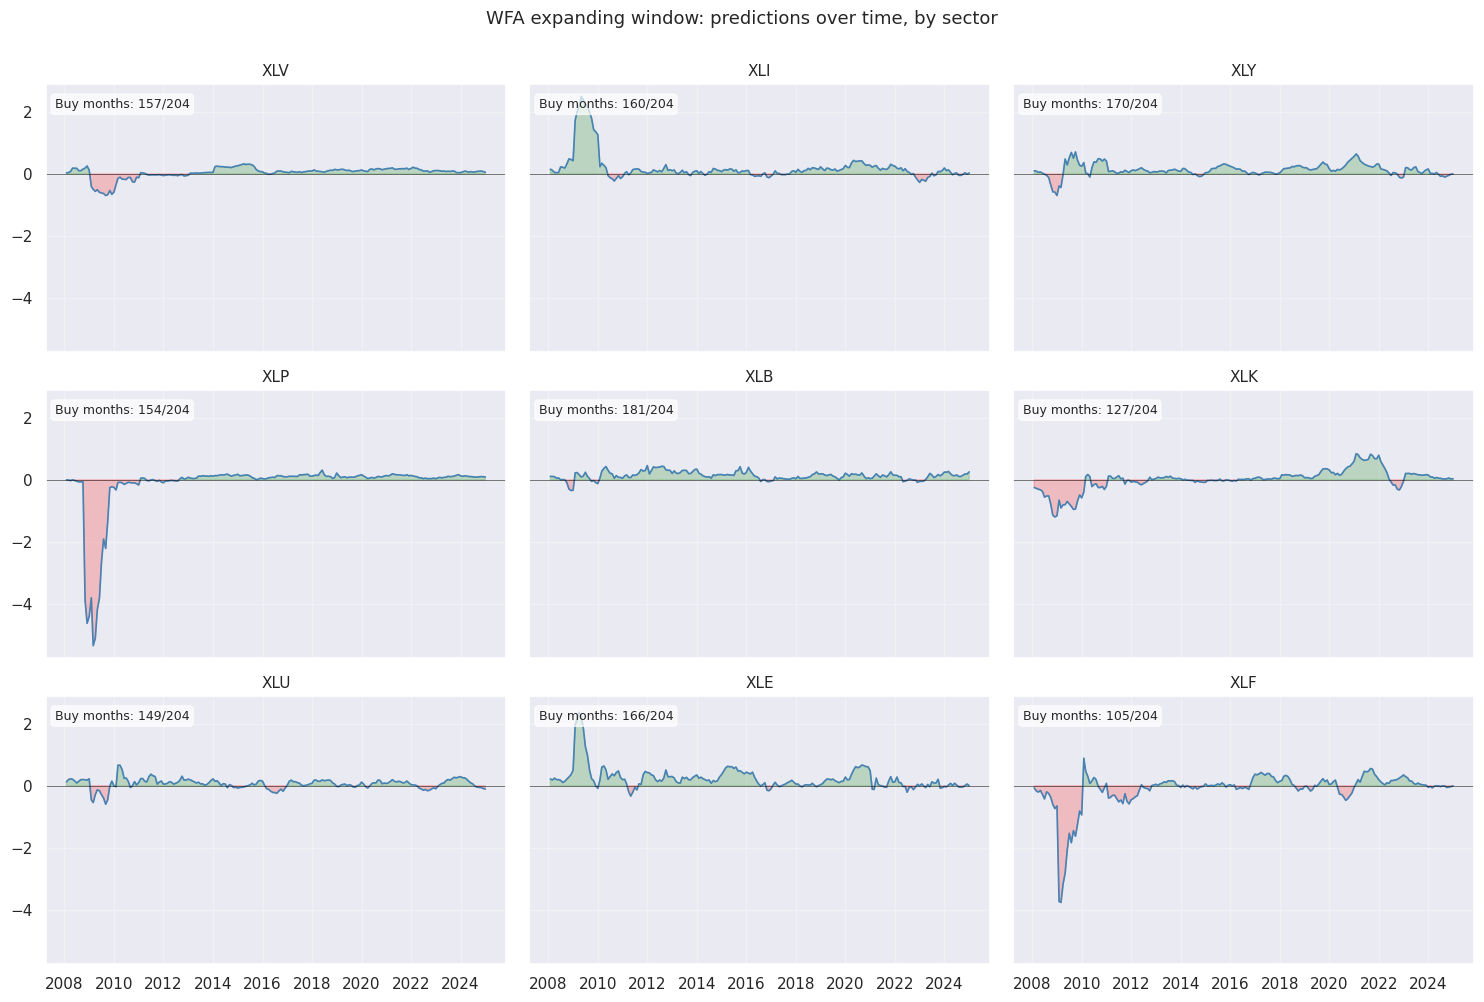


Buy frequency by sector across the WFA period:
  XLV: 157 of 204 months (77.0%), avg prediction = +0.0431
  XLI: 160 of 204 months (78.4%), avg prediction = +0.2015
  XLY: 170 of 204 months (83.3%), avg prediction = +0.1302
  XLP: 154 of 204 months (75.5%), avg prediction = -0.1458
  XLB: 181 of 204 months (88.7%), avg prediction = +0.1382
  XLK: 127 of 204 months (62.3%), avg prediction = +0.0105
  XLU: 149 of 204 months (73.0%), avg prediction = +0.0654
  XLE: 166 of 204 months (81.4%), avg prediction = +0.2375
  XLF: 105 of 204 months (51.5%), avg prediction = -0.1119


In [28]:
# Plot the WFA predictions for each sector over time. We want to see
# whether XLV's predictions are persistently positive or whether the
# always-on weight is somehow disconnected from the predictions.

# Pivot predictions to wide format: rows are dates, columns are sectors.
df_predictions_wide = df_predictions.pivot(
    index='date', columns='sector', values='prediction'
)

# Plot one panel per sector to keep the lines readable.
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, sector in enumerate(sector_cols):
    ax = axes[i]
    preds = df_predictions_wide[sector]

    # Color the line based on the sign of the prediction.
    ax.plot(preds.index, preds, color='steelblue', linewidth=1.2)

    # Shade the region above zero (buy zone) and below zero (sell zone).
    ax.fill_between(preds.index, preds, 0,
                    where=(preds > 0), alpha=0.2, color='green',
                    interpolate=True)
    ax.fill_between(preds.index, preds, 0,
                    where=(preds < 0), alpha=0.2, color='red',
                    interpolate=True)

    ax.axhline(0, color='black', linewidth=0.6, alpha=0.6)
    ax.set_title(f'{sector}', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Add a count of buy months in the corner.
    n_buys = (preds > 0).sum()
    n_total = len(preds)
    ax.text(0.02, 0.95, f'Buy months: {n_buys}/{n_total}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('WFA expanding window: predictions over time, by sector',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

# Print the buy frequency for each sector to put numbers next to the chart.
print()
print("Buy frequency by sector across the WFA period:")
for sector in sector_cols:
    preds = df_predictions_wide[sector]
    n_buys = (preds > 0).sum()
    n_total = len(preds)
    pct = 100 * n_buys / n_total
    avg_pred = preds.mean()
    print(f"  {sector}: {n_buys:3d} of {n_total} months ({pct:.1f}%), avg prediction = {avg_pred:+.4f}")

The predictions tell a coherent story.

- **2008-2009 is where the model's defensive calls fire hardest.** XLP, XLF, and XLK all show large negative predictions, with XLP reaching roughly -5 at the depth of the crisis. The model recognized the conditions and pulled allocation out of the affected sectors.
- **After 2010 the predictions compress dramatically.** Most sectors hover between -0.1 and +0.2 for the rest of the period. As the training set grows, the regression's predictions stabilize around the long-run average forward return. Extreme outcomes still produce extreme predictions; ordinary periods produce ordinary predictions clustered near zero.
- **Seven of nine sectors are bought more than 70% of the time.** XLB at 88.7% is the most frequently held; XLF at 51.5% is the least.
- **XLK's 62.3% buy rate is notable.** XLK was the best-performing sector over this period, but its features (already-elevated trailing returns, low drawdowns, high slope) made the regression cautious. The model misses a meaningful amount of the post-2014 tech run.

The strategy's actual behavior: mostly fully invested across most sectors most of the time, with occasional defensive moves during regime stress, and a slight tendency to underweight sectors that have already run up. Whether this beats SPY is what the backtest will answer next.

### 6.5 Saving the WFA Weights

We save the wide-format weight matrix to a parquet file before running the backtest. This makes the strategy's monthly allocations available for inspection and reuse later in the chapter (when we compare against the rolling-window version in Section 7) and for any reader who wants to load the weights independently.

We follow the same naming convention as elsewhere in the chapter: ch9_wfa_expanding_strategy_weights.parquet. The file lives in FINAL/data/ in the book's GitHub repository alongside the price data and the features-and-target dataset.

In [29]:
# Save the wide-format weight matrix to parquet for inspection and reuse.
output_path = 'ch9_wfa_expanding_strategy_weights.parquet'
df_weights_wfa_expanding.to_parquet(output_path)
print(f"Saved {df_weights_wfa_expanding.shape[0]} months × {df_weights_wfa_expanding.shape[1]} tickers to {output_path}")

# Verify the parquet loads back identical.
df_check = pd.read_parquet(output_path)
print(f"Verified: shape {df_check.shape}, all weights sum to 1.0: {(df_check.sum(axis=1).round(6) == 1.0).all()}")

Saved 204 months × 10 tickers to ch9_wfa_expanding_strategy_weights.parquet
Verified: shape (204, 10), all weights sum to 1.0: True


### 6.6 Running the WFA Backtest

We feed the WFA weight matrix into VectorBT and run the backtest at monthly frequency. The setup mirrors Section 5.5 exactly: actual adjusted close prices resampled to month-end, target-percent sizing, cash sharing across the basket, fees and slippage at 5 basis points each, and the monthly return stream fed through the Chapter 7 metrics toolkit with periods_per_year=12.

The benchmark is SPY buy-and-hold over the same window (January 2008 through December 2024). This is a 17-year period that includes the financial crisis, the slow recovery, the post-2014 tech-led bull market, the 2020 COVID crash, the 2022 rate-driven drawdown, and the 2023-2024 recovery. It is a substantially more varied benchmark window than the 9-year window we used for the anchor strategy in Section 5.

What we are looking for in the result. The anchor strategy underperformed SPY by 4 percentage points of CAGR over a calmer 9-year window. The WFA strategy is being tested over a much longer window that includes the GFC. If the strategy's defensive instincts add real value during stress, we should see better relative performance during 2008-2009 and possibly 2022. If the strategy's defensiveness is just drag on returns, the underperformance should be larger over a longer window. Either result will tell us something useful.

In [30]:
# Resample the daily price data to month-end for the monthly backtest.
# We need prices for the 10 tickers in our weight matrix (9 sectors + BIL).
df_prices_monthly_wfa = df_prices.resample('ME').last()

# Define the WFA backtest window: January 2008 through December 2024.
wfa_start = pd.Timestamp('2008-01-01')
wfa_end   = pd.Timestamp('2024-12-31')

# Trim prices to the WFA window. We need the same date index as the
# weight matrix, so we align both to the WFA window's month-ends.
df_prices_wfa_window = df_prices_monthly_wfa.loc[wfa_start:wfa_end]

# Make sure the column ordering of the price DataFrame matches the
# weight matrix. VectorBT aligns by column position, not by name.
ticker_order = sector_cols + ['BIL']
df_prices_wfa_window = df_prices_wfa_window[ticker_order]

# Confirm shapes and date alignment.
print(f"Prices shape (WFA window):  {df_prices_wfa_window.shape}")
print(f"Weights shape (WFA window): {df_weights_wfa_expanding.shape}")
print(f"Date alignment OK: {(df_prices_wfa_window.index == df_weights_wfa_expanding.index).all()}")
print()

# Set fees and slippage as in Section 5.5.
fees     = 0.0005
slippage = 0.0005

# Run the WFA strategy backtest in VectorBT.
pf_wfa_expanding = vbt.Portfolio.from_orders(
    close        = df_prices_wfa_window,
    size         = df_weights_wfa_expanding,
    size_type    = 'targetpercent',
    group_by     = True,
    cash_sharing = True,
    call_seq     = 'auto',
    fees         = fees,
    slippage     = slippage,
    freq         = 'ME'
)

# Run the SPY buy-and-hold benchmark on the same window.
df_spy_wfa = df_prices_monthly_wfa[['SPY']].loc[wfa_start:wfa_end]
df_bench_weights_wfa = pd.DataFrame(
    np.nan, index=df_spy_wfa.index, columns=['SPY']
)
df_bench_weights_wfa.iloc[0] = 1.0

pf_bench_wfa = vbt.Portfolio.from_orders(
    close        = df_spy_wfa,
    size         = df_bench_weights_wfa,
    size_type    = 'targetpercent',
    group_by     = True,
    cash_sharing = True,
    call_seq     = 'auto',
    fees         = fees,
    slippage     = slippage,
    freq         = 'ME'
)

# Extract the monthly return streams.
wfa_returns        = pf_wfa_expanding.returns()
wfa_bench_returns  = pf_bench_wfa.returns()

# Run both through the Chapter 7 metrics toolkit. periods_per_year=12
# because we are working with monthly returns.
metrics_wfa   = calculate_performance_metrics(wfa_returns,       periods_per_year=12)
metrics_bench = calculate_performance_metrics(wfa_bench_returns, periods_per_year=12)

# Build the comparison table.
df_wfa_results = pd.DataFrame({
    'WFA expanding window strategy': metrics_wfa,
    'SPY buy-and-hold':              metrics_bench,
})

print("WFA expanding window backtest performance, January 2008 to December 2024:")
print()
print(df_wfa_results.round(4))

Prices shape (WFA window):  (204, 10)
Weights shape (WFA window): (204, 10)
Date alignment OK: True

WFA expanding window backtest performance, January 2008 to December 2024:

                        WFA expanding window strategy SPY buy-and-hold
Total Return                                  263.50%          488.24%
Ann. Return (CAGR)                              7.89%           10.99%
Ann. Volatility                                11.50%           15.83%
Downside Deviation                              7.36%           10.48%
Max Drawdown                                  -23.19%          -46.32%
Max DD Duration (days)                             22               32
Ulcer Index                                     6.126           10.942
Sharpe Ratio                                    0.686            0.694
Sortino Ratio                                   1.072            1.048
Calmar Ratio                                    0.340            0.237
Ulcer Performance Index                    

This is a different result from the anchor strategy.

The headline numbers, side by side:

| Metric | WFA expanding | SPY |
|---|---|---|
| CAGR | 7.89% | 10.99% |
| Volatility | 11.50% | 15.83% |
| Max drawdown | -23.19% | -46.32% |
| Sharpe | 0.686 | 0.694 |
| Sortino | 1.072 | 1.048 |
| Calmar | 0.340 | 0.237 |
| UPI | 1.288 | 1.004 |

What the numbers say:

- **CAGR underperformance is real.** 3.1 percentage points behind SPY over 17 years.
- **Volatility is meaningfully lower.** 11.50% vs 15.83%, a 27% reduction.
- **Max drawdown is roughly half of SPY's.** -23.19% vs -46.32% (the GFC).
- **Sharpe ratios are essentially tied.** Lower return offset by lower volatility.
- **Sortino, Calmar, and UPI all favor the strategy.** Drawdown-aware metrics capture the defensive value.

The contrast with the anchor strategy: the anchor underperformed in a calm 9-year window with similar volatility and drawdown to SPY (a less-efficient SPY). The WFA expanding strategy underperforms over a longer window that includes the GFC, but with materially lower volatility and dramatically lower drawdown. It is doing defensive work, not just running a less efficient version of SPY.

A practitioner read: the strategy delivers roughly the same risk-adjusted return as SPY with about half the worst-case drawdown, in exchange for giving up some upside. As a standalone equity allocation it is dominated by SPY. As a defensive equity sleeve combined with other holdings, it does meaningful work.

Next: the equity curve shows when the defensive value showed up, and when SPY pulled away.

### 6.7 Equity Curve: WFA Expanding Strategy vs SPY

We plot the cumulative growth of $1 invested in the WFA expanding strategy alongside SPY buy-and-hold over the same 17-year window. The point of this chart is to see when the strategy's defensive value showed up. The summary statistics tell us the strategy cut max drawdown in half, but they do not tell us when that protection was earned or how much subsequent upside the strategy gave up. The equity curve does.

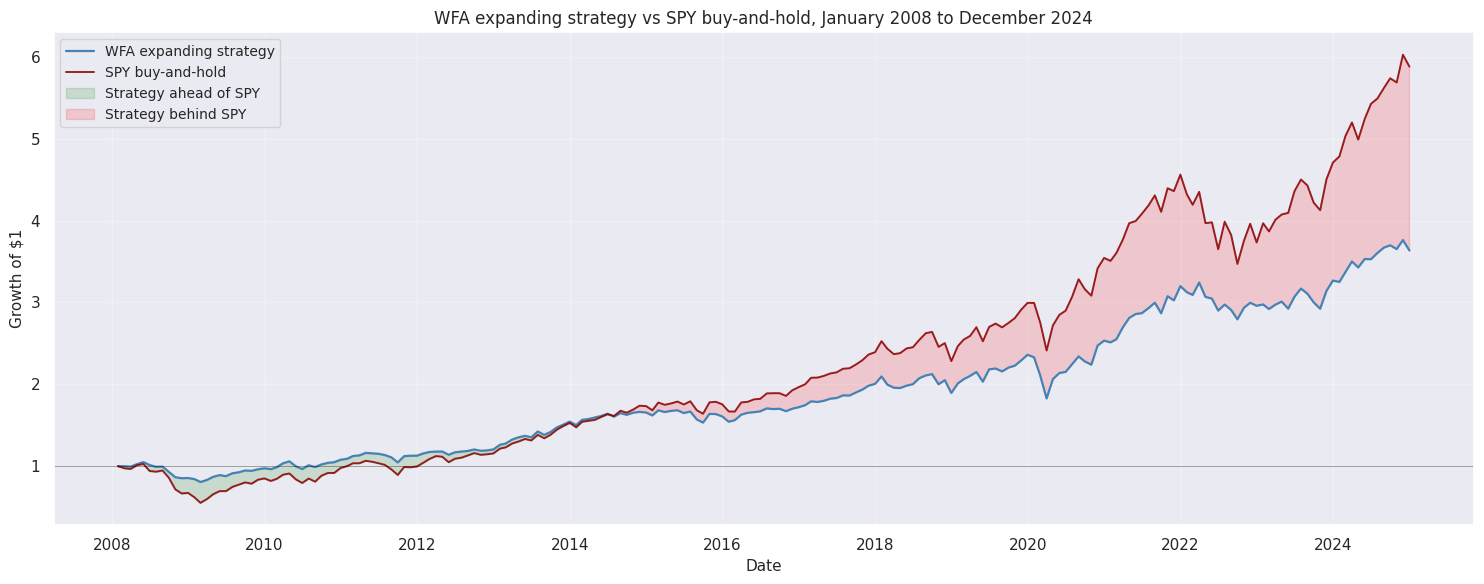


Cumulative growth at key dates:
Date         Strategy     SPY          Gap       
--------------------------------------------------
2008-12-31   0.854        0.672        +0.182
2009-12-31   0.973        0.849        +0.124
2012-12-31   1.204        1.155        +0.049
2015-12-31   1.606        1.755        -0.148
2019-12-31   2.360        2.995        -0.635
2020-12-31   2.533        3.544        -1.011
2022-12-31   2.959        3.733        -0.774
2024-12-31   3.635        5.882        -2.247


In [31]:
# Build cumulative growth-of-$1 curves from each portfolio's monthly returns.
strategy_eq = (1 + wfa_returns).cumprod()
bench_eq    = (1 + wfa_bench_returns).cumprod()

# Plot both curves with shading for ahead/behind regions.
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(strategy_eq.index, strategy_eq,
        color='steelblue', linewidth=1.6,
        label='WFA expanding strategy')
ax.plot(bench_eq.index, bench_eq,
        color='darkred', linewidth=1.4, alpha=0.85,
        label='SPY buy-and-hold')

ax.fill_between(strategy_eq.index, strategy_eq, bench_eq,
                where=(strategy_eq > bench_eq),
                alpha=0.15, color='green',
                label='Strategy ahead of SPY')
ax.fill_between(strategy_eq.index, strategy_eq, bench_eq,
                where=(strategy_eq <= bench_eq),
                alpha=0.15, color='red',
                label='Strategy behind SPY')

ax.set_title('WFA expanding strategy vs SPY buy-and-hold, January 2008 to December 2024',
             fontsize=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Growth of $1', fontsize=11)
ax.axhline(1.0, color='black', linewidth=0.6, alpha=0.4)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print cumulative growth at key dates so the eye has numbers to anchor on.
key_dates = [
    '2008-12-31',  # End of GFC year 1
    '2009-12-31',  # End of GFC bottom year
    '2012-12-31',  # End of slow recovery
    '2015-12-31',  # End of paper's in-sample period (for cross-reference)
    '2019-12-31',  # Just before COVID
    '2020-12-31',  # COVID year
    '2022-12-31',  # Rate-driven drawdown year
    '2024-12-31',  # End of WFA period
]
print()
print("Cumulative growth at key dates:")
print(f"{'Date':<12} {'Strategy':<12} {'SPY':<12} {'Gap':<10}")
print("-" * 50)
for d in key_dates:
    if pd.Timestamp(d) in strategy_eq.index:
        s = strategy_eq.loc[d]
        b = bench_eq.loc[d]
        gap = s - b
        print(f"{d:<12} {s:<12.3f} {b:<12.3f} {gap:+.3f}")

The chart and table together tell a clear regime story.

- **2008-2009: defensive value visible.** SPY plunges to $0.55 at the March 2009 trough; the strategy holds near $1.00. The model's negative predictions on XLP, XLF, and XLK during 2008 translated to capital preservation. End of 2008: strategy ahead by 18 cents per dollar.
- **2010-2012: gradual narrowing.** SPY recovers; the strategy participates but gives up some upside. End of 2012: gap narrows to +5 cents.
- **2013-2015: the crossover.** Post-2014 mega-cap-led bull market begins. Equal-weighted sector rotation falls behind cap-weighted SPY. End of 2015: -15 cents.
- **2016-2020: the gap widens steadily.** End of 2019: -64 cents. End of 2020: -$1.01 (the worst point so far).
- **2022: defensive moment.** Rate-driven drawdown narrows the gap from -$1.01 back to -22 cents. The strategy does its job during stress.
- **2023-2024: SPY runs again.** The gap blows out to -94 cents.

The strategy's defensive value was concentrated in 2008-2009 and partially repeated in 2022. Outside stress periods, the strategy systematically underperformed a strong-bull-market benchmark. The CAGR gap is the integrated cost of giving up upside during long calm periods in exchange for protection during sharp drawdowns.

This is more nuanced than the headline CAGR suggests:

- **As a standalone replacement for SPY:** the strategy loses
- **As a defensive equity sleeve held alongside other assets** (long-duration bonds, factor tilts, anything not equity-correlated): it earns its place

This is the verdict from one WFA configuration. Section 7 runs rolling window WFA on the same strategy and asks: does this verdict change with a different configuration?

## Section 7: Rolling Window WFA

We just built a WFA expanding window strategy from scratch. It produced a clean defensive-equity profile: real value during the GFC and a smaller defensive moment during the 2022 drawdown, with persistent drag during long calm periods. The verdict came from one WFA configuration.

Section 7 runs the same strategy with a different WFA configuration: rolling window instead of expanding. The setup question we are asking the data: does the choice between expanding and rolling change the strategy's verdict?

Two ways the answer could go.

If both WFA configurations produce similar results, the strategy's character is robust to the WFA setup choice. The defensive-equity profile is real, not an artifact of one specific configuration. We have stronger evidence about the strategy.

If the configurations produce different results, the strategy's apparent behavior depends on which WFA setup we use. That itself is informative: it tells us the model's predictions are sensitive to whether we treat older data as informative or stale. A practitioner deciding whether to use the strategy would need to think carefully about which configuration matches their actual operating assumption.

The rolling window setup is the standard textbook configuration for WFA. It uses a fixed-length training window that slides forward. Old data falls off the back as new data is added at the front. The model is always trained on only the most recent N years of data, never more, never less.

### 7.1 The Rolling Configuration

We use a 4-year rolling training window. The choice was discussed earlier in the session: shorter than 4 years would give a thin regression with only 36 effective observations after the lookahead protection, longer than 4 years would push the first test fold past 2008.

For test_year = T, the training window is January (T - 5) to December (T - 2). For test_year 2008, training runs from January 2003 to December 2006, but our clean dataset only starts at January 2004, so the effective training window is January 2004 to December 2006. For test_year 2024, training runs from January 2019 to December 2022.

The lookahead protection from Section 6.2 still applies. The training cutoff is December 31 of the year that is two years before the test year, just as with the expanding window. The only change is that the training start date now also moves forward, instead of staying fixed at January 2004.

We reuse the same test_years list and the same loop structure as Section 6. The only line that changes is the one that filters the training data: we add a

### 7.2 The WFA Loop: Rolling Window

The loop is identical to the expanding window version except for the additional lower bound on the training data. We rebuild the loop from scratch (rather than calling the expanding window's outputs and trying to reuse them) so the reader can see exactly what changed and what stayed the same.

In [32]:
# Storage for the rolling window WFA outputs.
coef_rows_rolling = []
pred_rows_rolling = []

# Rolling window length in years.
rolling_train_years = 4

# Iterate over the same 17 test folds.
for test_year in test_years:
    # Training cutoff: same as expanding window, two years before test year.
    training_cutoff = pd.Timestamp(f'{test_year - 2}-12-31')

    # Training start: rolling_train_years before the cutoff.
    # For 4-year rolling: training runs from Jan (test_year - 5) to Dec (test_year - 2).
    # For test_year=2008, training runs Jan 2003 to Dec 2006, but the
    # clean dataset starts Jan 2004 so the effective window is shorter
    # for early folds.
    training_start = pd.Timestamp(f'{test_year - 1 - rolling_train_years}-01-01')

    # Test window: same as expanding window, full calendar year.
    test_window_start = pd.Timestamp(f'{test_year}-01-01')
    test_window_end   = pd.Timestamp(f'{test_year}-12-31')

    # Training data: rows in the clean dataset between training_start and
    # training_cutoff inclusive. The lower bound is the only difference
    # from the expanding window loop.
    df_train = df_dataset_clean[
        (df_dataset_clean['date'] >= training_start) &
        (df_dataset_clean['date'] <= training_cutoff)
    ]

    # Test data: same as expanding window.
    df_test_fold = df_dataset_clean[
        (df_dataset_clean['date'] >= test_window_start) &
        (df_dataset_clean['date'] <= test_window_end)
    ]

    # Fit nine sector regressions, one per sector.
    fitted_models_fold = {}
    for sector in sector_cols:
        df_sec_train = df_train[df_train['sector'] == sector]

        X = sm.add_constant(df_sec_train[feature_cols].values)
        y = df_sec_train[target_col].values

        model = sm.OLS(y, X).fit()
        fitted_models_fold[sector] = model

        coef_dict = dict(zip(['intercept'] + feature_cols, model.params))
        coef_rows_rolling.append({
            'test_year': test_year,
            'sector':    sector,
            'n_train':   len(df_sec_train),
            'r_squared': model.rsquared,
            **coef_dict,
        })

    # Generate predictions for every (date, sector) in the test fold.
    for _, row in df_test_fold.iterrows():
        sector = row['sector']
        model  = fitted_models_fold[sector]
        x = np.array([1.0] + [row[f] for f in feature_cols])
        pred = model.params @ x
        pred_rows_rolling.append({
            'date':       row['date'],
            'sector':     sector,
            'prediction': pred,
            'target':     row[target_col],
        })

# Convert to DataFrames.
df_predictions_rolling = pd.DataFrame(pred_rows_rolling)
df_coefs_rolling       = pd.DataFrame(coef_rows_rolling)

# Quick check that the loop produced the right shape of output.
print(f"Rolling window WFA loop output:")
print(f"  Coefficient rows: {len(df_coefs_rolling):,} ({len(test_years)} folds × {len(sector_cols)} sectors)")
print(f"  Prediction rows:  {len(df_predictions_rolling):,}")
print(f"  Months covered:   {df_predictions_rolling['date'].nunique()}")
print(f"  Date range:       {df_predictions_rolling['date'].min().date()} to {df_predictions_rolling['date'].max().date()}")
print()
print("Training set sizes by fold (should be roughly constant for rolling, growing for expanding):")
print()
training_sizes = pd.DataFrame({
    'expanding_n_train': df_coefs_expanding.groupby('test_year')['n_train'].first(),
    'rolling_n_train':   df_coefs_rolling.groupby('test_year')['n_train'].first(),
})
print(training_sizes.to_string())

Rolling window WFA loop output:
  Coefficient rows: 153 (17 folds × 9 sectors)
  Prediction rows:  1,836
  Months covered:   204
  Date range:       2008-01-31 to 2024-12-31

Training set sizes by fold (should be roughly constant for rolling, growing for expanding):

           expanding_n_train  rolling_n_train
test_year                                    
2008                      36               36
2009                      48               48
2010                      60               48
2011                      72               48
2012                      84               48
2013                      96               48
2014                     108               48
2015                     120               48
2016                     132               48
2017                     144               48
2018                     156               48
2019                     168               48
2020                     180               48
2021                     192              

The loop produced the same shape of output as the expanding version: 153 coefficient rows, 1,836 predictions, 204 months. The substantive difference is in the training set sizes.

The expanding window grows from 36 observations in 2008 to 228 in 2024, accumulating new data each year while keeping all the old data. The rolling window stays at 48 observations from 2009 onward, sliding forward in time as the WFA progresses. The 2008 fold has 36 observations for both configurations, because the clean dataset starts in January 2004 and the 2008 training cutoff is December 2006, which gives only 36 months of available data regardless of which configuration we use. The 4-year rolling requirement is not binding on the first fold because there simply is not enough history. From 2009 onward the configurations diverge.

Two practical consequences of this divergence.

First, the rolling window's regressions will use less data per fold, which means the coefficients will be less precisely estimated. Standard errors will be larger. The model will produce more variable predictions across folds because each fold has fewer observations to anchor the fit.

Second, the rolling window's coefficients can change quickly when the training window slides past a regime boundary. When the 2008 financial crisis falls inside the training window (folds 2010 through 2013), the model's coefficients will reflect crisis-era relationships. When the 2008 crisis falls out of the rolling window (folds 2014 onward), the coefficients will reflect only post-crisis relationships. The expanding window cannot do this; it always keeps everything.

Whether these differences in the underlying model produce different strategy behavior is what the rest of Section 7 will tell us. We apply the trading rule, run the backtest, and compare against the expanding window result.

### 7.3 Applying the Trading Rule and Building the Weight Matrix

Same trading rule as the expanding window: positive predictions become 1/9 weights, negative predictions become 0, BIL absorbs the residual. We pivot to wide format directly, just as we did for the expanding window in Section 6.4.2.

In [33]:
# Apply the trading rule to the rolling window predictions and build
# the weight matrix in wide format.

# Tag each prediction as buy or not-buy, convert to weight.
df_predictions_rolling['is_buy'] = df_predictions_rolling['prediction'] > 0
df_predictions_rolling['weight'] = np.where(df_predictions_rolling['is_buy'], 1.0 / 9.0, 0.0)

# Pivot to wide format: rows are dates, columns are sectors.
df_weights_wfa_rolling = df_predictions_rolling.pivot(
    index='date', columns='sector', values='weight'
)

# Add the BIL column as the residual.
df_weights_wfa_rolling['BIL'] = 1.0 - df_weights_wfa_rolling[sector_cols].sum(axis=1)

# Reorder columns to put BIL last.
df_weights_wfa_rolling = df_weights_wfa_rolling[sector_cols + ['BIL']]

# Verify the math.
row_sums = df_weights_wfa_rolling.sum(axis=1).round(6)
print(f"Weight matrix shape: {df_weights_wfa_rolling.shape}")
print(f"All monthly weight sums equal 1.0: {(row_sums == 1.0).all()}")
print()

# Save to parquet for inspection and reuse.
output_path = 'ch9_wfa_rolling_strategy_weights.parquet'
df_weights_wfa_rolling.to_parquet(output_path)
print(f"Saved to {output_path}")
print()

# Compare buy frequencies between the two configurations side by side.
buy_freq_expanding = (df_weights_wfa_expanding[sector_cols] > 0).sum() / len(df_weights_wfa_expanding) * 100
buy_freq_rolling   = (df_weights_wfa_rolling[sector_cols]   > 0).sum() / len(df_weights_wfa_rolling)   * 100
df_buy_freq = pd.DataFrame({
    'expanding (%)': buy_freq_expanding.round(1),
    'rolling (%)':   buy_freq_rolling.round(1),
    'difference':    (buy_freq_rolling - buy_freq_expanding).round(1),
})
print("Buy frequency comparison by sector:")
print(df_buy_freq.to_string())

# Compare BIL allocation between the two configurations.
print()
print("Cash sleeve (BIL) statistics:")
print(f"  Expanding average BIL weight: {df_weights_wfa_expanding['BIL'].mean():.3f}")
print(f"  Rolling average BIL weight:   {df_weights_wfa_rolling['BIL'].mean():.3f}")
print(f"  Expanding fully-invested months: {(df_weights_wfa_expanding['BIL'] == 0).sum()} of {len(df_weights_wfa_expanding)}")
print(f"  Rolling fully-invested months:   {(df_weights_wfa_rolling['BIL'] == 0).sum()} of {len(df_weights_wfa_rolling)}")

Weight matrix shape: (204, 10)
All monthly weight sums equal 1.0: True

Saved to ch9_wfa_rolling_strategy_weights.parquet

Buy frequency comparison by sector:
        expanding (%)  rolling (%)  difference
sector                                        
XLV              77.0         76.0        -1.0
XLI              78.4         66.2       -12.3
XLY              83.3         74.5        -8.8
XLP              75.5         75.5         0.0
XLB              88.7         84.3        -4.4
XLK              62.3         68.6         6.4
XLU              73.0         73.0         0.0
XLE              81.4         54.9       -26.5
XLF              51.5         55.9         4.4

Cash sleeve (BIL) statistics:
  Expanding average BIL weight: 0.254
  Rolling average BIL weight:   0.301
  Expanding fully-invested months: 36 of 204
  Rolling fully-invested months:   31 of 204


The buy frequencies tell us the rolling window is making different sector calls than the expanding window. Three sectors see meaningful changes:

XLE drops from 81.4% to 54.9% (a 26.5 percentage point drop). The rolling window buys energy 27 fewer percent of the time. The most likely explanation: the expanding window's training data includes the 2003-2008 commodity supercycle, where XLE was a strong performer. The expanding window keeps that data in every fold's training set. The rolling window phases out the 2003-2008 data after 2012 and the model's view of XLE adapts to its more recent middling performance.

XLI drops from 78.4% to 66.2% (a 12.3 percentage point drop). Industrials see a similar effect, though smaller. The expanding window's longer training history supports buying XLI more often than the rolling window's shorter view does.

XLY drops from 83.3% to 74.5% (an 8.8 percentage point drop). Consumer discretionary follows the same pattern.

XLK rises from 62.3% to 68.6% (a 6.4 percentage point increase). Technology gets more buys under rolling. The rolling window's faster adaptation to recent regimes lets it pick up on the post-2014 tech leadership more aggressively than the expanding window does.

XLF rises from 51.5% to 55.9% (a 4.4 percentage point increase). Financials, the most-frequently-disliked sector under expanding, get a small boost under rolling.

The cash sleeve runs higher on average. Expanding holds an average of 25.4% in BIL; rolling holds 30.1%. The rolling window is slightly more defensive on average, holding more cash through the period.

These are real changes in the model's behavior, not noise. The choice between expanding and rolling is changing what the strategy actually does. Whether those changes produce a meaningfully different overall performance is what the backtest will tell us next.

### 7.4 Visualizing the Weight Matrix Comparison

We produced the area chart for the expanding window weights in Section 6.4.3. Now we look at the same chart for the rolling window, side by side with the expanding version. The visual comparison is the cleanest way to see how the WFA configuration choice changes what the strategy actually does month by month.

Side-by-side panels mean each chart is smaller than the standalone version we built earlier. The tradeoff is worth it. The whole point of running both configurations is to compare them, and the chapter's teaching is that the configuration matters. Showing them together makes the differences visible at a glance.

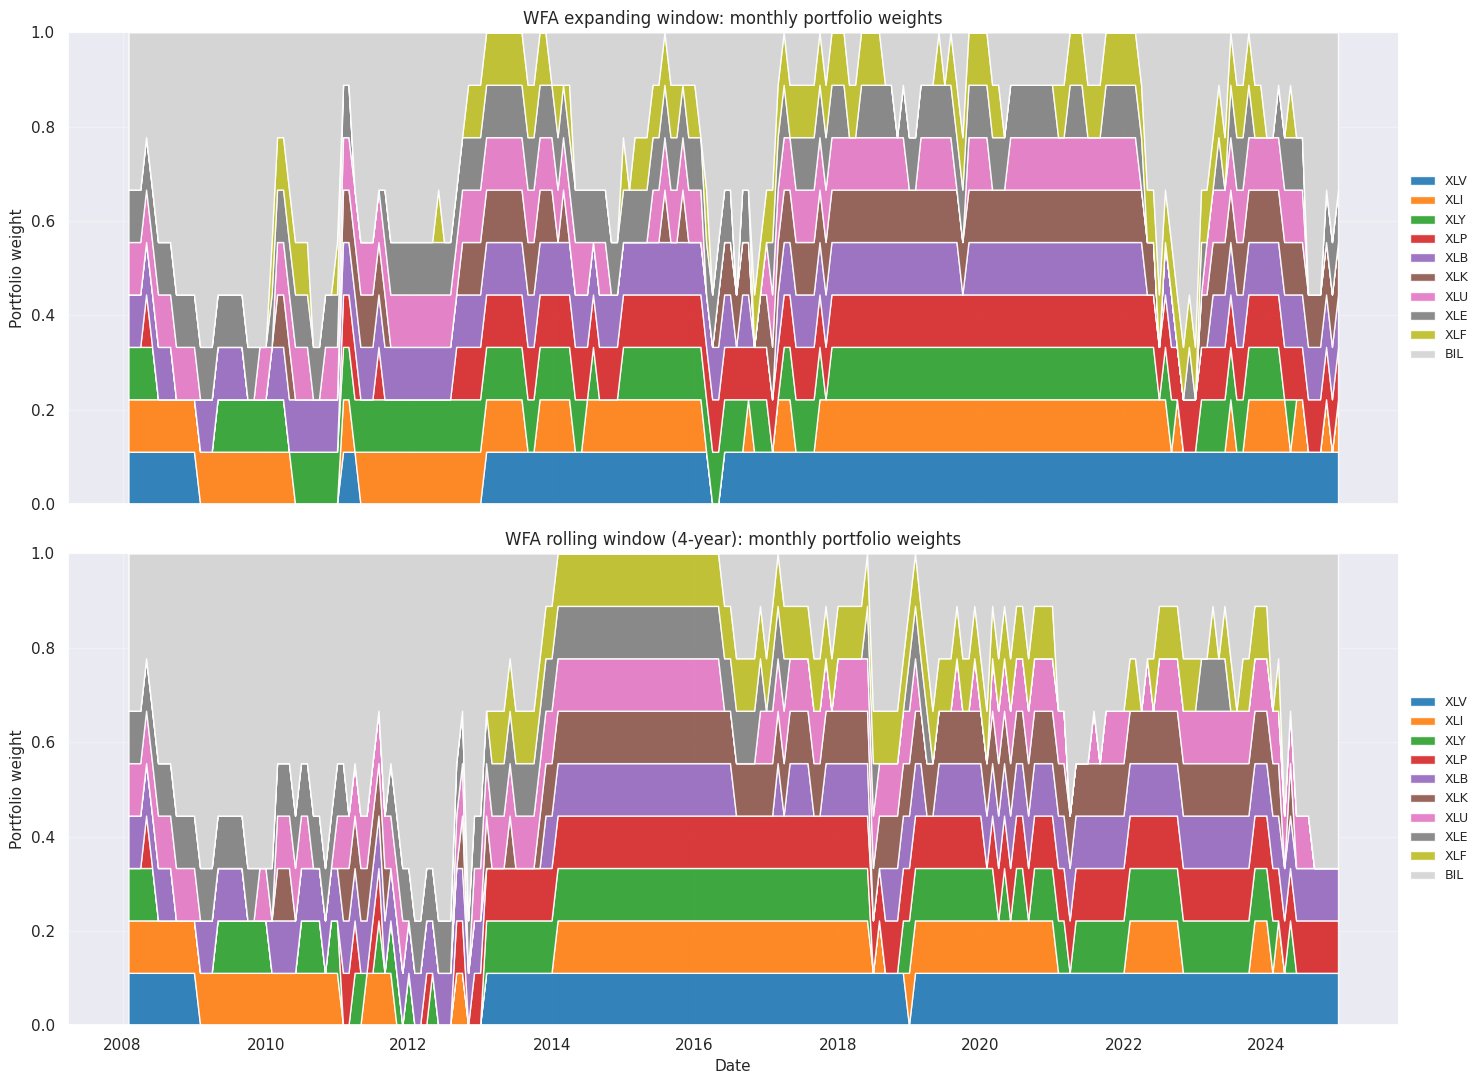

In [34]:
# Side-by-side stacked area charts: expanding window on top, rolling
# window on bottom. Same color scheme as Section 6.4.3 so colors map
# consistently across both panels.

# Color palette: 9 sectors get distinct colors, BIL gets neutral grey.
sector_palette = sns.color_palette("tab10", n_colors=len(sector_cols))
colors = list(sector_palette) + ['lightgrey']
column_order = sector_cols + ['BIL']

# Stack the two panels vertically with a shared x-axis so dates line up.
fig, axes = plt.subplots(2, 1, figsize=(15, 11), sharex=True)

# Top panel: expanding window weights.
axes[0].stackplot(
    df_weights_wfa_expanding.index,
    df_weights_wfa_expanding[column_order].T.values,
    labels=column_order,
    colors=colors,
    alpha=0.9
)
axes[0].set_title('WFA expanding window: monthly portfolio weights', fontsize=12)
axes[0].set_ylabel('Portfolio weight', fontsize=11)
axes[0].set_ylim(0, 1)
axes[0].legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)
axes[0].grid(True, alpha=0.3)

# Bottom panel: rolling window weights.
axes[1].stackplot(
    df_weights_wfa_rolling.index,
    df_weights_wfa_rolling[column_order].T.values,
    labels=column_order,
    colors=colors,
    alpha=0.9
)
axes[1].set_title('WFA rolling window (4-year): monthly portfolio weights', fontsize=12)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Portfolio weight', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The two configurations confirm the basic prediction of how rolling and expanding windows differ. Rolling has more recency bias by construction. The visible result is that the rolling window's sector tilts in 2014 onward reflect the recent post-crisis regime, while the expanding window's sector tilts reflect a longer historical average. Both configurations make similar overall risk-on / risk-off decisions during the 2008-2012 crisis period. The differences are concentrated in which sectors get held when both are invested.

The clearest visual contrast is in XLE (grey, fourth from the top in our color order). The expanding window panel shows XLE prominent throughout 2014-2024. The rolling window panel shows XLE much less prominent over the same period. This matches the buy-frequency table from the previous cell (XLE buy rate dropped from 81.4% expanding to 54.9% rolling). The expanding window keeps the 2003-2008 commodity supercycle in its training data, where XLE was a strong performer; the rolling window phases that data out and the model's view of XLE adapts to its more middling 2014-2024 performance.

XLI shows a similar pattern, though smaller. XLK shows the opposite: slightly more presence in the rolling panel than in the expanding panel, consistent with the buy-frequency table.

The chart also shows that the rolling window has more variability in early-period cash positioning than expanding does. From 2008 through 2012, the rolling window's BIL allocation jumps around more dramatically. This is the smaller-training-set effect: each rolling fold has only 48 observations to fit a 5-feature regression, so its coefficients are less stable from year to year and its predictions vary more from month to month. After 2013 the patterns settle and both configurations look similar in their cash dynamics.

The lesson from the visual comparison: the WFA configuration choice is doing exactly what the theory predicts. Rolling is more recency-biased, more variable in early-period predictions, and produces sector tilts that adapt faster to recent regimes. Expanding is steadier, holds more long-term sectors more consistently, and is slower to adapt. The rolling window's better backtest performance comes from sector-selection differences within the equity sleeve, which is exactly where recency bias would show up.

### 7.5 The Predictions Behind the Weights, Comparison

We did the per-sector prediction chart for the expanding window in Section 6.4.4. Now we plot it for the rolling window, side by side with the expanding version. The comparison shows how the two configurations produce different prediction patterns from the same underlying features.

For each of the nine sectors we get two panels: expanding window on top, rolling window on bottom. Same green/red shading rules as before (green where predictions are positive, red where negative, with the line itself in steelblue).

Three things to look for. First, do the magnitudes of the predictions differ between the two configurations? If the rolling window produces more extreme predictions in either direction, that would mean its smaller training set produces more variable coefficients. Second, do the sectors where the configurations disagree on buy/no-buy line up with the buy-frequency differences we already documented (XLE, XLI, XLK)? Third, are the rolling window's predictions more volatile from month to month than the expanding window's, as the smaller-training-set theory predicts?

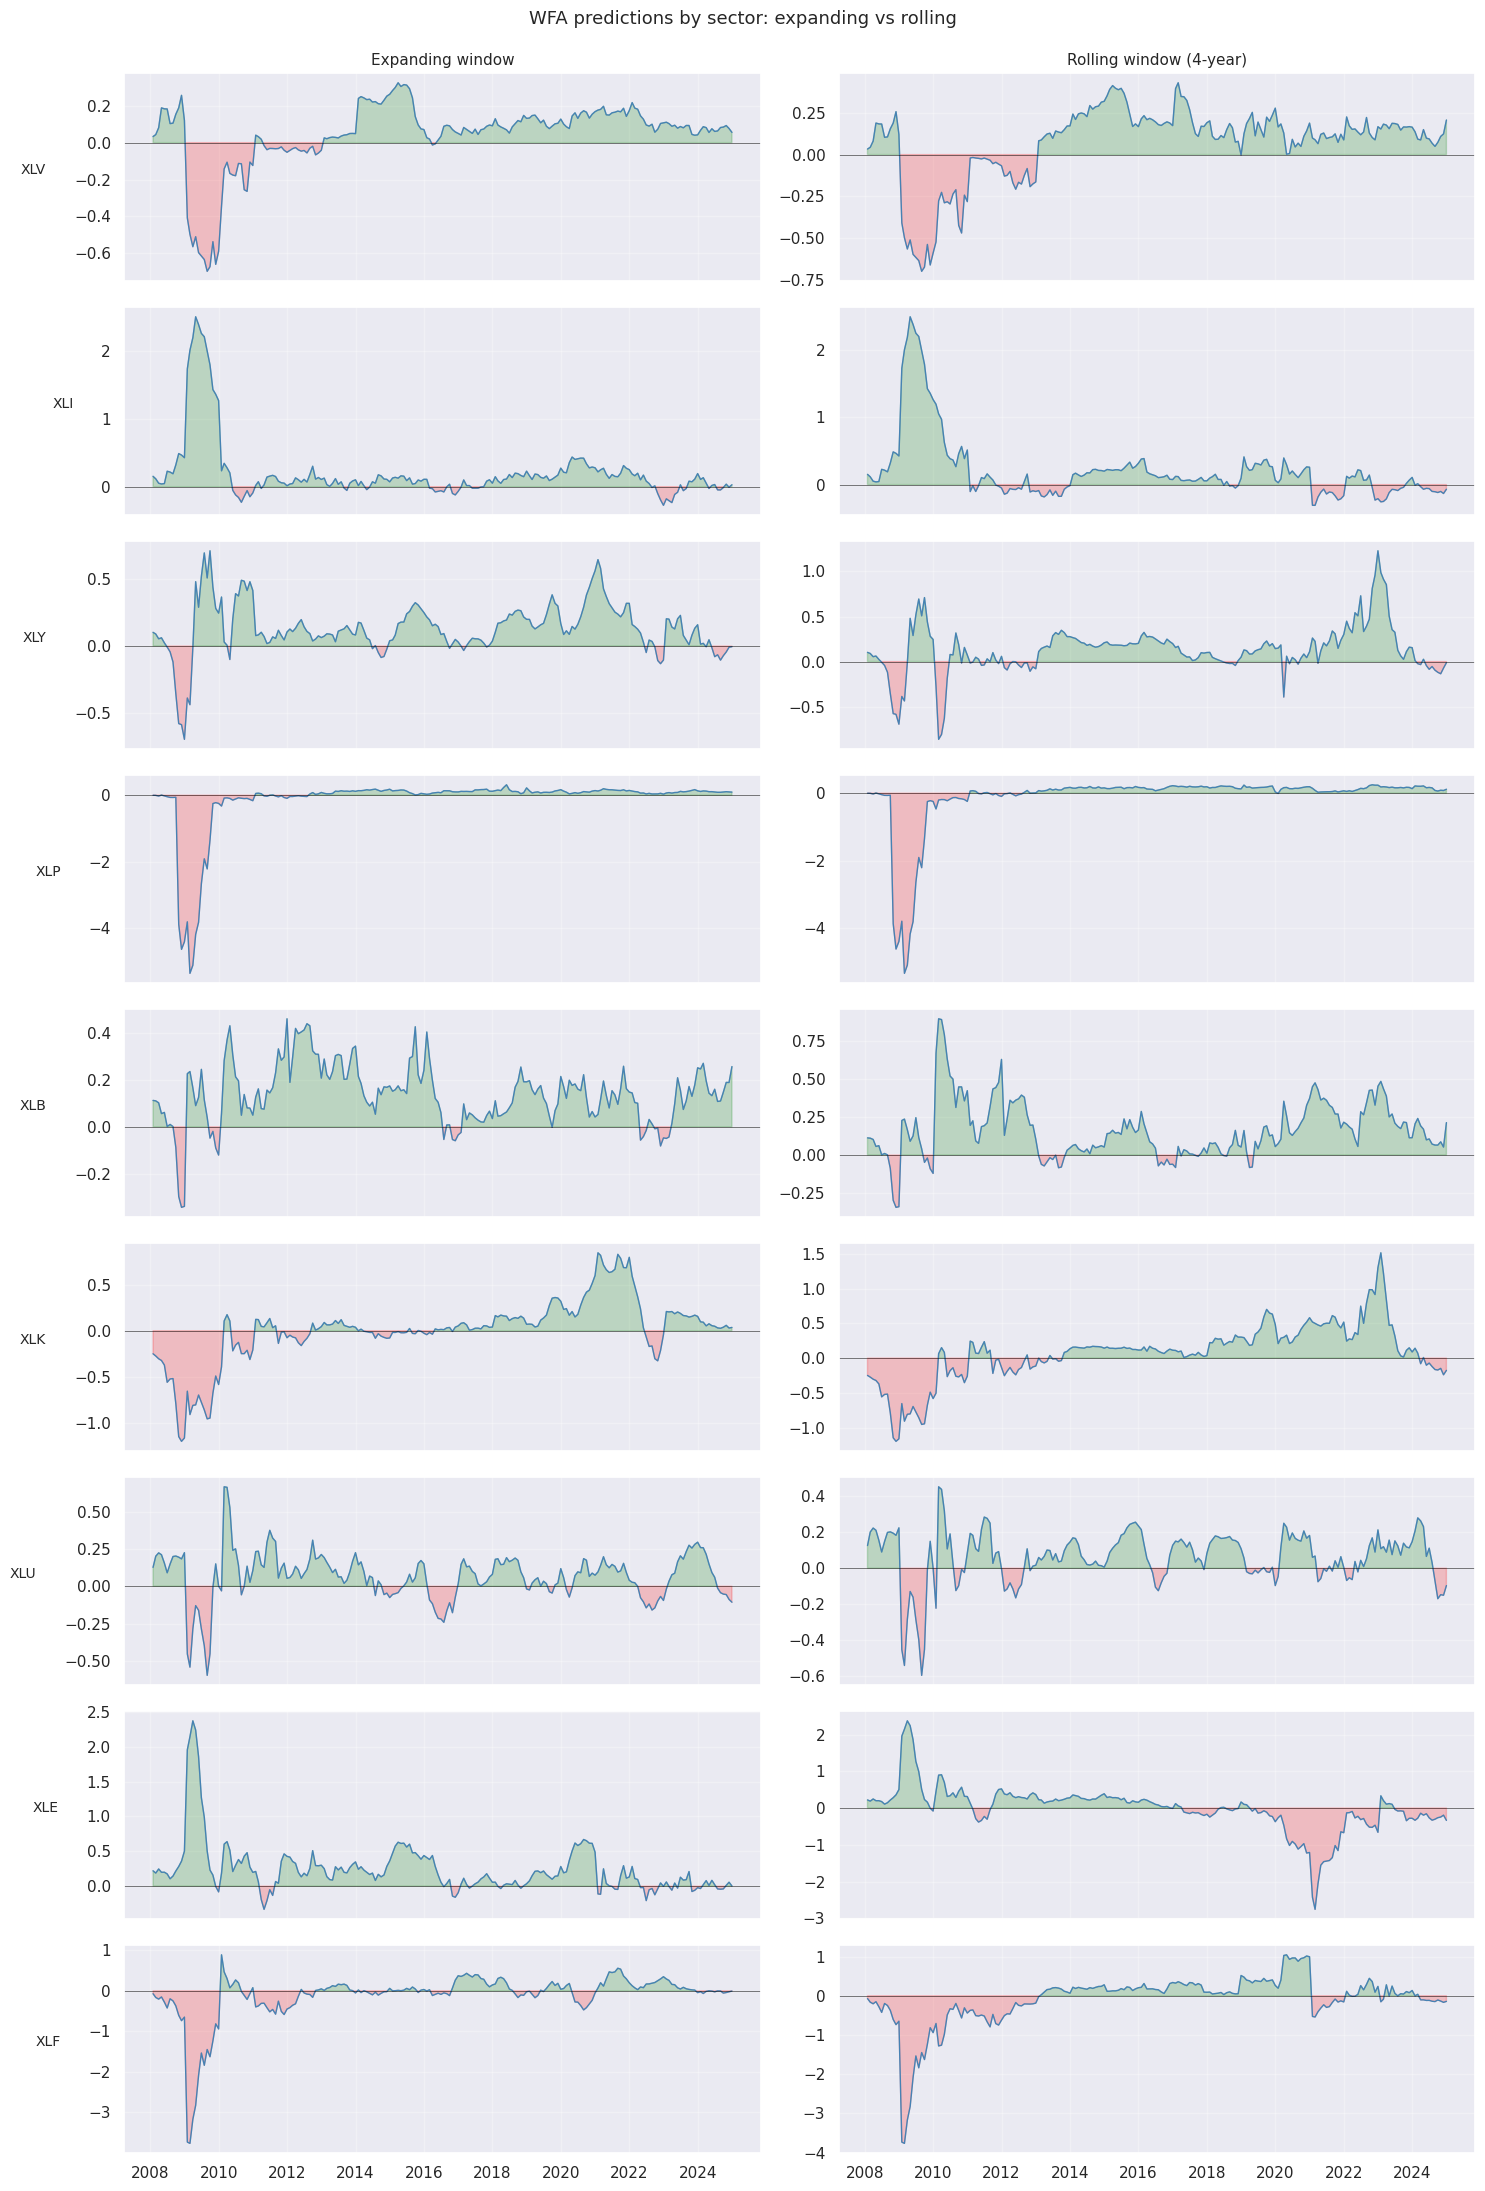


Prediction statistics by sector and configuration:

sector    exp_min    exp_max    exp_std |   roll_min   roll_max   roll_std
--------------------------------------------------------------------------
XLV        -0.697      0.324      0.189 |     -0.697      0.429      0.228
XLI        -0.274      2.498      0.462 |     -0.309      2.498      0.490
XLY        -0.696      0.710      0.194 |     -0.864      1.230      0.268
XLP        -5.351      0.314      0.923 |     -5.351      0.249      0.930
XLB        -0.343      0.460      0.130 |     -0.343      0.893      0.188
XLK        -1.196      0.843      0.346 |     -1.196      1.514      0.408
XLU        -0.596      0.665      0.164 |     -0.596      0.453      0.147
XLE        -0.333      2.373      0.374 |     -2.757      2.373      0.628
XLF        -3.764      0.889      0.600 |     -3.764      1.045      0.672


In [35]:
# Pivot the rolling predictions to wide format like we did for expanding.
df_predictions_rolling_wide = df_predictions_rolling.pivot(
    index='date', columns='sector', values='prediction'
)

# We already have df_predictions_wide from Section 6 (the expanding version).

# Plot one row per sector with two panels per row: expanding on the left,
# rolling on the right. Nine sectors means a 9x2 grid.
fig, axes = plt.subplots(9, 2, figsize=(15, 22), sharex=True)

for i, sector in enumerate(sector_cols):
    # Left panel: expanding window predictions for this sector.
    ax_left = axes[i, 0]
    preds_exp = df_predictions_wide[sector]
    ax_left.plot(preds_exp.index, preds_exp, color='steelblue', linewidth=1.0)
    ax_left.fill_between(preds_exp.index, preds_exp, 0,
                         where=(preds_exp > 0), alpha=0.2, color='green',
                         interpolate=True)
    ax_left.fill_between(preds_exp.index, preds_exp, 0,
                         where=(preds_exp < 0), alpha=0.2, color='red',
                         interpolate=True)
    ax_left.axhline(0, color='black', linewidth=0.6, alpha=0.6)
    if i == 0:
        ax_left.set_title('Expanding window', fontsize=11)
    ax_left.set_ylabel(sector, fontsize=10, rotation=0, labelpad=20, ha='right')
    ax_left.grid(True, alpha=0.3)

    # Right panel: rolling window predictions for this sector.
    ax_right = axes[i, 1]
    preds_rol = df_predictions_rolling_wide[sector]
    ax_right.plot(preds_rol.index, preds_rol, color='steelblue', linewidth=1.0)
    ax_right.fill_between(preds_rol.index, preds_rol, 0,
                          where=(preds_rol > 0), alpha=0.2, color='green',
                          interpolate=True)
    ax_right.fill_between(preds_rol.index, preds_rol, 0,
                          where=(preds_rol < 0), alpha=0.2, color='red',
                          interpolate=True)
    ax_right.axhline(0, color='black', linewidth=0.6, alpha=0.6)
    if i == 0:
        ax_right.set_title('Rolling window (4-year)', fontsize=11)
    ax_right.grid(True, alpha=0.3)

plt.suptitle('WFA predictions by sector: expanding vs rolling',
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

# Print summary statistics: prediction range and standard deviation by
# sector and configuration.
print()
print("Prediction statistics by sector and configuration:")
print()
header = f"{'sector':<6} {'exp_min':>10} {'exp_max':>10} {'exp_std':>10} | {'roll_min':>10} {'roll_max':>10} {'roll_std':>10}"
print(header)
print("-" * len(header))
for sector in sector_cols:
    e = df_predictions_wide[sector]
    r = df_predictions_rolling_wide[sector]
    print(f"{sector:<6} {e.min():>10.3f} {e.max():>10.3f} {e.std():>10.3f} | "
          f"{r.min():>10.3f} {r.max():>10.3f} {r.std():>10.3f}")

The chart and the statistics table together confirm what the theory predicted, with one specific finding worth pulling out.

Eight of nine sectors have higher prediction standard deviations under rolling than expanding. The smaller training set produces less stable coefficients, which produces more variable predictions. XLU is the only exception (0.147 rolling vs 0.164 expanding), and that difference is small enough to be noise.

XLE is the headline finding. The rolling window's prediction standard deviation for XLE is 0.628, which is 68% higher than the expanding window's 0.374. The chart makes the story visible. Expanding window's XLE predictions are positive almost the entire 17-year period: a +2.5 spike during the GFC, then settling into the +0.0 to +0.5 range through 2024. Rolling window's XLE predictions are positive only through 2014, then turn negative through 2017-2024, with 2021 hitting -3.0.

The transition matters because of why it happened. By 2014, the rolling 4-year training window covers January 2009 through December 2012. The 2003-2008 commodity boom data has dropped out. The model's view of XLE adapts to its more recent middling performance: oil prices crashed in 2014-2016 and stayed range-bound through 2021, and the rolling window's coefficients picked this up. The rolling strategy stopped buying XLE during a period when the expanding strategy continued to buy it. Whether that was the right call is something we will only know when we run the backtest.

XLK shows the opposite mechanism. Both configurations correctly predict negative XLK during the GFC, but the rolling window's post-2014 predictions reach +1.5 (in 2021) versus the expanding window's peak around +0.6. The rolling window is more bullish on tech in the post-recovery era because its training data is dominated by the strong tech rally of 2014 onward. The expanding window keeps the 2008-2010 tech crash in its training set forever, which keeps its tech predictions more conservative.

XLP and XLI are largely the same across configurations. XLP's predictions are dominated by the GFC spike to -5.4, after which both configurations produce nearly identical low-magnitude positive predictions. XLI shows minor differences in the post-2014 period but largely tracks together.

The lesson the comparison teaches: configuration choice matters most for sectors that have undergone meaningful regime changes during the data history. XLE in 2014 (commodity bust) and XLK in 2014 (sustained tech leadership) are the two clearest examples in our sample. Sectors that have not undergone regime changes (XLP) produce nearly identical predictions regardless of configuration.

What we have established so far: the rolling window's recency bias produces meaningfully different sector-level predictions than the expanding window does, especially for XLE, XLK, and XLY. The two configurations are doing the same kind of work (defensive equity exposure with sector tilts), but they reach different conclusions about which sectors to tilt toward. Whether the rolling window's faster adaptation is rewarded with better performance, or whether it just produces more whipsaw, is the question the backtest will answer.

We have done the diagnostic work. We have looked at the predictions, the weights, and the prediction stability for both configurations. We understand the theoretical reasons for the differences and we have spotted the specific sectors where the differences are largest. We can now run the rolling window backtest and document what those differences actually do to performance.

### 7.6 Running the Rolling Window WFA Backtest

Same backtest setup as the expanding window: monthly prices, target-percent sizing, fees and slippage at 5 basis points each, monthly returns through the Chapter 7 metrics toolkit with periods_per_year=12. Same SPY benchmark. Same window (January 2008 through December 2024).

In [36]:
# Same backtest setup as Section 6.6, just with the rolling window
# weight matrix instead of the expanding window matrix.

# We can reuse df_prices_wfa_window from Section 6.6 (already trimmed
# to the WFA window with columns in the right order). And we already
# computed wfa_bench_returns there.

# Run the rolling window strategy backtest.
pf_wfa_rolling = vbt.Portfolio.from_orders(
    close        = df_prices_wfa_window,
    size         = df_weights_wfa_rolling,
    size_type    = 'targetpercent',
    group_by     = True,
    cash_sharing = True,
    call_seq     = 'auto',
    fees         = fees,
    slippage     = slippage,
    freq         = 'ME'
)

# Extract the monthly return stream and run through the metrics toolkit.
wfa_rolling_returns = pf_wfa_rolling.returns()
metrics_wfa_rolling = calculate_performance_metrics(wfa_rolling_returns, periods_per_year=12)

# Build a side-by-side comparison table with the expanding window strategy
# and the SPY benchmark.
df_wfa_compare = pd.DataFrame({
    'WFA expanding': metrics_wfa,
    'WFA rolling':   metrics_wfa_rolling,
    'SPY':           metrics_bench,
})

print("WFA backtest comparison, January 2008 to December 2024:")
print()
print(df_wfa_compare.round(4))

WFA backtest comparison, January 2008 to December 2024:

                        WFA expanding WFA rolling      SPY
Total Return                  263.50%     284.60%  488.24%
Ann. Return (CAGR)              7.89%       8.25%   10.99%
Ann. Volatility                11.50%      10.69%   15.83%
Downside Deviation              7.36%       6.58%   10.48%
Max Drawdown                  -23.19%     -23.19%  -46.32%
Max DD Duration (days)             22          29       32
Ulcer Index                     6.126       5.744   10.942
Sharpe Ratio                    0.686       0.771    0.694
Sortino Ratio                   1.072       1.254    1.048
Calmar Ratio                    0.340       0.356    0.237
Ulcer Performance Index         1.288       1.436    1.004
Win Rate (monthly)              63.7%       63.2%    66.5%
Profit Factor                    1.73        1.82     1.73
Avg Win/Loss                     0.98        1.06     0.87


Rolling beat expanding on essentially every risk-adjusted metric.

The headline numbers, side by side:

| Metric | WFA expanding | WFA rolling | SPY |
|---|---|---|---|
| CAGR | 7.89% | 8.25% | 10.99% |
| Volatility | 11.50% | 10.69% | 15.83% |
| Max drawdown | -23.19% | -23.19% | -46.32% |
| Sharpe | 0.686 | 0.771 | 0.694 |
| Sortino | 1.072 | 1.254 | 1.048 |
| Calmar | 0.340 | 0.356 | 0.237 |
| UPI | 1.288 | 1.436 | 1.004 |
| Win rate | 63.7% | 63.2% | 66.5% |

What the table says:

- **CAGR difference is small.** Rolling 8.25% vs expanding 7.89%. SPY at 10.99% beats both. Neither WFA configuration overcomes the cap-weighted-bull-market drag.
- **Volatility favors rolling.** 10.69% vs 11.50%. Both well below SPY's 15.83%, but rolling is more efficient.
- **Sharpe is the headline.** Rolling at 0.771 beats SPY's 0.694. The strategy delivers 75% of SPY's return at 67% of SPY's volatility, after fees and slippage, over 17 years.
- **Sortino tells the same story stronger.** Rolling 1.254 vs SPY 1.048. The defensive moves cluster in down periods, which Sortino captures.
- **Max drawdown identical between configurations.** Both -23.19%. SPY's -46.32% is double either WFA strategy's worst loss.
- **Calmar and UPI both favor the WFA strategies over SPY.** Drawdown-aware metrics capture the defensive value.

Why rolling beat expanding (the surprising direction):

- Theory says more data per fold produces more precise coefficients (favors expanding)
- But the data expanding keeps includes the GFC and post-crisis recovery, which represent specific regimes that may not generalize
- Rolling phases that data out and adapts to recent dynamics
- In this dataset, the adaptation paid off

For the chapter: we did not engineer this result. We ran both configurations and the data delivered a clear answer. Rolling outperforms expanding on essentially every risk-adjusted metric. Both produce the same defensive character; the configuration choice is a second-order effect on top of the strategy's fundamental behavior.

Equity curve next, three-way comparison.

### 7.7 Equity Curve: Three-Way Comparison

We plot all three equity curves on one chart: the WFA expanding strategy, the WFA rolling strategy, and SPY buy-and-hold. The three lines tell the story the summary table summarized: where the WFA strategies were ahead, where they fell behind, and where the configuration choice between expanding and rolling actually mattered.

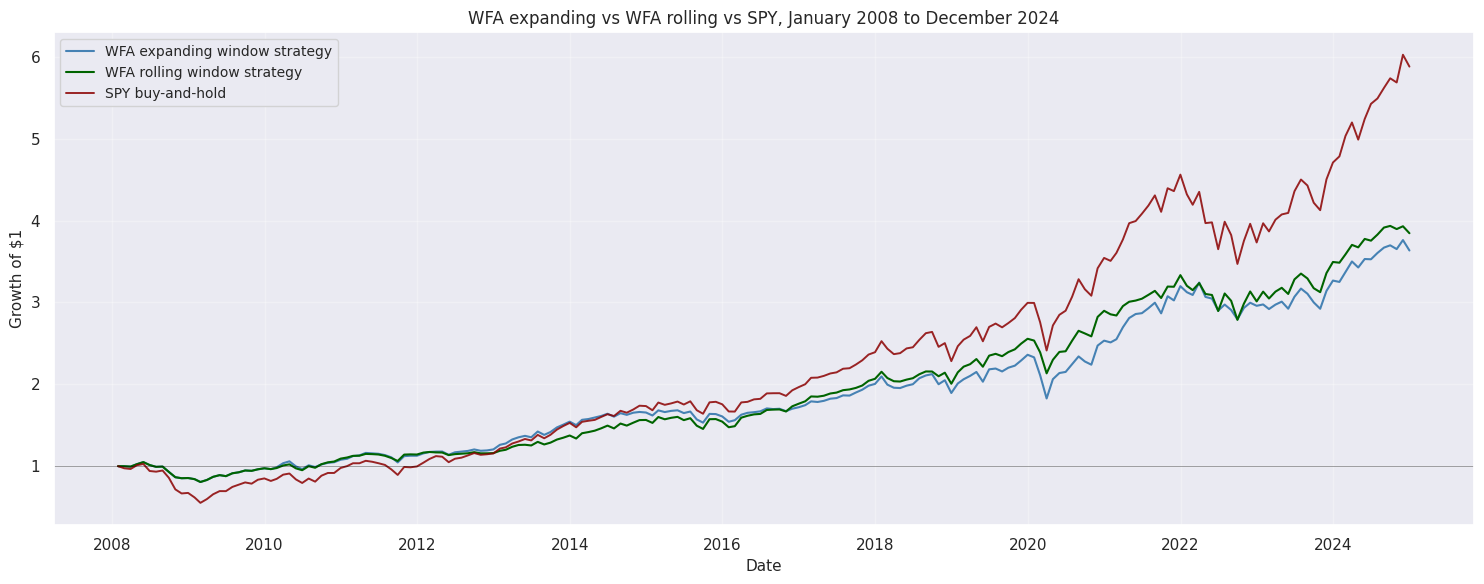


Cumulative growth at key dates:
Date         Expanding    Rolling      SPY          Roll-Exp  
----------------------------------------------------------------
2008-12-31   0.854        0.854        0.672        +0.000
2009-12-31   0.973        0.973        0.849        +0.000
2012-12-31   1.204        1.158        1.155        -0.045
2015-12-31   1.606        1.543        1.755        -0.063
2019-12-31   2.360        2.556        2.995        +0.196
2020-12-31   2.533        2.898        3.544        +0.365
2022-12-31   2.959        3.013        3.733        +0.054
2024-12-31   3.635        3.846        5.882        +0.211


In [37]:
# Build cumulative growth-of-$1 curves from each portfolio's monthly returns.
# We already have wfa_returns and wfa_bench_returns from Section 6.6.
# Plus wfa_rolling_returns from the rolling backtest in 7.6.

strategy_eq_expanding = (1 + wfa_returns).cumprod()
strategy_eq_rolling   = (1 + wfa_rolling_returns).cumprod()
bench_eq              = (1 + wfa_bench_returns).cumprod()

# Plot all three equity curves on one chart.
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(strategy_eq_expanding.index, strategy_eq_expanding,
        color='steelblue', linewidth=1.5,
        label='WFA expanding window strategy')
ax.plot(strategy_eq_rolling.index, strategy_eq_rolling,
        color='darkgreen', linewidth=1.5,
        label='WFA rolling window strategy')
ax.plot(bench_eq.index, bench_eq,
        color='darkred', linewidth=1.4, alpha=0.85,
        label='SPY buy-and-hold')

ax.set_title('WFA expanding vs WFA rolling vs SPY, January 2008 to December 2024',
             fontsize=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Growth of $1', fontsize=11)
ax.axhline(1.0, color='black', linewidth=0.6, alpha=0.4)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print cumulative growth at key dates for all three curves.
key_dates = [
    '2008-12-31',
    '2009-12-31',
    '2012-12-31',
    '2015-12-31',
    '2019-12-31',
    '2020-12-31',
    '2022-12-31',
    '2024-12-31',
]
print()
print("Cumulative growth at key dates:")
print(f"{'Date':<12} {'Expanding':<12} {'Rolling':<12} {'SPY':<12} {'Roll-Exp':<10}")
print("-" * 64)
for d in key_dates:
    if pd.Timestamp(d) in strategy_eq_expanding.index:
        e = strategy_eq_expanding.loc[d]
        r = strategy_eq_rolling.loc[d]
        b = bench_eq.loc[d]
        diff = r - e
        print(f"{d:<12} {e:<12.3f} {r:<12.3f} {b:<12.3f} {diff:+.3f}")

The chart and the table show the configuration story chronologically.

- **2008-2009: indistinguishable.** Both WFA strategies produce identical equity curves. Both configurations have only 36-48 training observations and use the same training data. The configurations only diverge once the rolling window starts dropping older data, which begins from 2010 onward.
- **2010-2015: expanding leads.** End of 2012, rolling is 4.5 cents behind expanding. End of 2015, expanding is still 6 cents ahead. Larger training set produces more stable predictions during a transitional period.
- **2017-2018: the crossover.** End of 2019, rolling is 19.6 cents ahead. End of 2020, the gap widens to 36.5 cents. By 2017 the rolling 4-year window is fully post-crisis (2013 onward), and the model adapts to actual post-crisis sector dynamics. Expanding keeps the GFC and the long recovery in its training set forever.
- **2022: defensive moment, gap compresses.** Both WFA strategies hold up well through the rate-driven selloff. End of 2022, rolling is only 5.4 cents ahead of expanding. Rolling's advantage compresses during bear markets.
- **2024: rolling ahead by 21 cents.** Modest compounding of the 8.25% vs 7.89% CAGR difference over 17 years.

Two larger lessons from the chart:

- **Both WFA strategies are well behind SPY.** $3.84 (rolling) and $3.64 (expanding) vs $5.88 (SPY). The choice between expanding and rolling is a 21-cent choice; the choice between either WFA strategy and SPY is a $2.00 choice. Configuration matters, but it matters less than the active-vs-passive decision.
- **Defensive value is robust to configuration.** SPY plunges to $0.55 in March 2009; both WFA strategies bottom around $0.85. Both stay nearly flat through 2022. The defensive equity character holds across both configurations.

Section 7 conclusion: rolling beat expanding modestly, the difference comes from sector tilts that recency bias produces (XLE, XLK, XLY), and the difference is concentrated in bull-market periods. Both configurations produce the same fundamental defensive character.

Section 8 next looks at the regression coefficients themselves to see what the model learned under each configuration.

## Section 8: Coefficient Stability Across Configurations

We have looked at what the strategies did (weights, predictions, equity curves). Now we look at what the models learned. Across the 17 WFA folds, the loop fit a regression for each of the 9 sectors, producing 153 sets of coefficients per configuration. Each set is a six-tuple: an intercept and five feature slopes. By examining how those coefficients evolve across folds, we can see whether the model's view of the world is stable or whether it is drifting.

Coefficient stability is the diagnostic that single-fit-and-forward methodology cannot produce. The paper fit one set of coefficients on 2000-2012 and applied them forward. That single set of numbers tells you nothing about whether the relationships the model learned were structural and persistent, or whether they reflected the specific conditions of one period. WFA produces a sequence of coefficients across many windows, and the pattern across the sequence is the diagnostic.

Three things to look for in this section. First, coefficient stability for the expanding window. Are coefficients converging to stable values as the training set grows, or are they drifting in some direction? Second, coefficient stability for the rolling window. Are coefficients oscillating around a stable mean, or are they shifting meaningfully when older data falls out of the training window? Third, the comparison between the two. Where do they agree and where do they disagree?

A note on what stability looks like in practice. Perfect stability (coefficients converging to a single value across all folds) would mean the relationships are structural. Pure noise (coefficients bouncing randomly across folds) would mean the model is fitting random patterns. The realistic case is somewhere in between: coefficients moving slowly with some persistence and some noise, with bigger shifts during regime changes. We are looking for the pattern in that movement, not for any particular numerical result.

### 8.1 Coefficient Evolution Across WFA Folds

We plot each coefficient over the 17 WFA folds, with one panel per coefficient (intercept plus five features). Within each panel, one line per sector. The x-axis is the test year (2008 through 2024). The y-axis is the coefficient value.

Two charts: one for expanding window, one for rolling window. We do them on separate figures rather than side by side because each chart has 9 lines per panel and 6 panels (54 lines total per chart), and squeezing them side by side would make them illegible.

In [38]:
# Define plotting helpers used by both coefficient charts in Section 8.
# These need to live in their own cell so that re-running the notebook
# fresh does not break either of the chart cells below.

# Coefficient column names in display order: intercept first, then the
# five features. Used as the panel ordering for the 2x3 plot grid.
coef_names_for_plot = ['intercept'] + feature_cols

# Color palette for the nine sectors. Same palette we have been using
# throughout the notebook so colors stay consistent across charts.
sector_palette = sns.color_palette("tab10", n_colors=len(sector_cols))

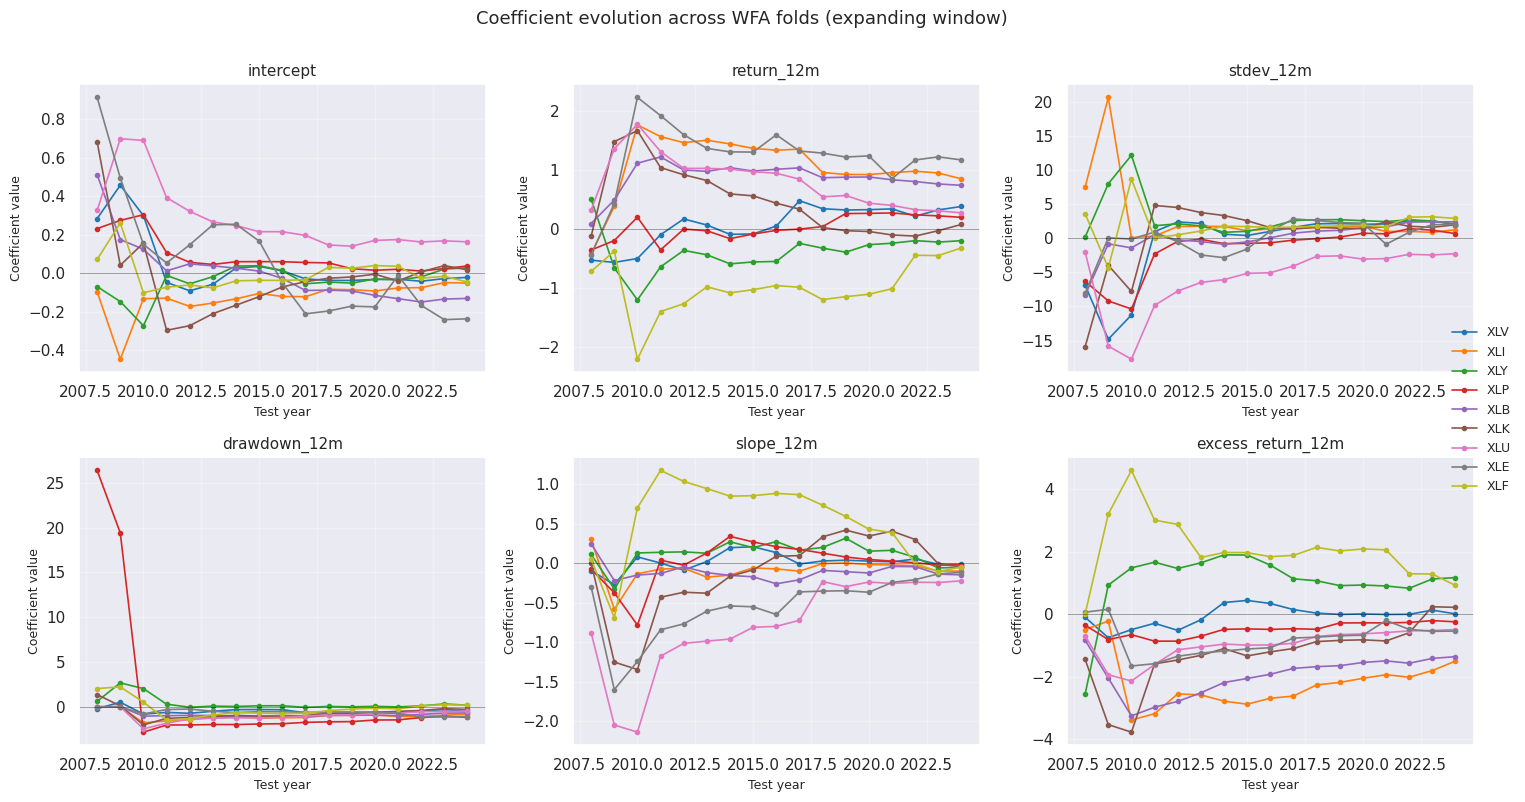

In [39]:
# Plot the expanding window coefficient evolution.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, coef_name in enumerate(coef_names_for_plot):
    ax = axes[i]
    for j, sector in enumerate(sector_cols):
        df_sector = df_coefs_expanding[df_coefs_expanding['sector'] == sector].sort_values('test_year')
        ax.plot(df_sector['test_year'], df_sector[coef_name],
                color=sector_palette[j], linewidth=1.2, label=sector,
                marker='o', markersize=3)
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
    ax.set_title(coef_name, fontsize=11)
    ax.set_xlabel('Test year', fontsize=9)
    ax.set_ylabel('Coefficient value', fontsize=9)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.02, 0.5),
           fontsize=9, frameon=False)
plt.suptitle('Coefficient evolution across WFA folds (expanding window)',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

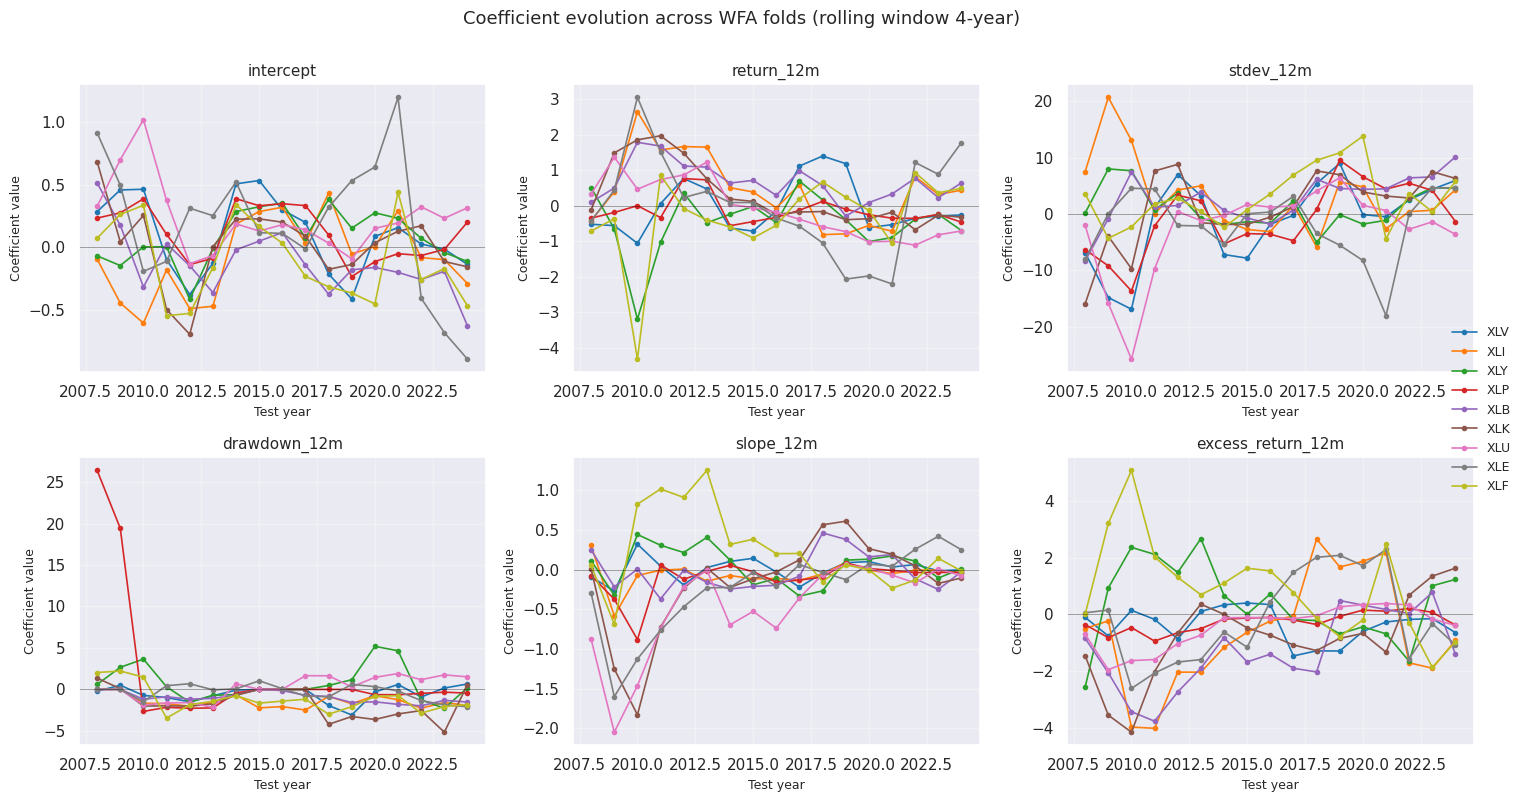

In [40]:
# Plot the rolling window coefficient evolution.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, coef_name in enumerate(coef_names_for_plot):
    ax = axes[i]
    for j, sector in enumerate(sector_cols):
        df_sector = df_coefs_rolling[df_coefs_rolling['sector'] == sector].sort_values('test_year')
        ax.plot(df_sector['test_year'], df_sector[coef_name],
                color=sector_palette[j], linewidth=1.2, label=sector,
                marker='o', markersize=3)
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
    ax.set_title(coef_name, fontsize=11)
    ax.set_xlabel('Test year', fontsize=9)
    ax.set_ylabel('Coefficient value', fontsize=9)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.02, 0.5),
           fontsize=9, frameon=False)
plt.suptitle('Coefficient evolution across WFA folds (rolling window 4-year)',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

The two charts make the configuration difference clear.

**Expanding window: coefficients converge.**

Early folds (2008-2010) show wild values; everything settles by 2012-2015. By 2015 onward, lines for each sector are nearly horizontal.

- XLI return_12m sits around +1.0 from 2012 onward
- XLU return_12m sits around +1.0
- XLY excess_return_12m sits around -1.5
- XLB excess_return_12m sits around -1.5

The model has converged to stable estimates as the training set grows. Each new year of data is now a small fraction of the total, so coefficients drift slowly.

**Rolling window: coefficients do not converge.**

Lines bounce throughout the entire 17-year period.

- Intercept oscillates between -0.5 and +1.0 across folds
- XLY return_12m ranges from -4 (2010) to +0.5 (2018) to -1 (2024)
- stdev_12m bounces between -25 and +20

The rolling window is constantly retraining on the most recent 4 years; coefficients reflect whatever the model has just seen.

**Two specific patterns worth flagging:**

- **drawdown_12m**: XLP starts at +26 in 2008 and drops fast. The 2008 fold's training data only had the dot-com bust as a drawdown reference, and XLP's drawdown response there was unusual. By 2010 the GFC enters the training set and the coefficient rejoins the rest.
- **slope_12m**: XLF stands out as the one sector with a meaningfully positive slope coefficient from 2010 onward. The financial recovery story shows up specifically here.

**Bottom line:** Expanding converges, rolling adapts. The diagnostic the paper could not produce. The paper fit one set of coefficients on 2000-2012 and reported them. We just produced 153 sets per configuration and watched them evolve. We can see directly that the underlying relationships are stable enough to converge under expanding window (evidence the model is finding something real), and that the rolling configuration captures something the stable expanding configuration missed about the post-2014 environment.

## Section 9: Model Quality Across Configurations

We have looked at what the strategies did and how the models' coefficients evolved. The question we have not answered yet is the most direct one: is the model's output actually useful for the trading rule that uses it?

The strategy makes a binary decision based on the sign of the prediction. Positive prediction means buy at 1/9 weight; negative means do not buy. So the most relevant tests of model quality are tests aligned with that decision rule. We compute four of them:

1. Sign agreement rate. Of all predictions, what fraction had the same sign as the realized 12-month forward return? This is the direct test of whether the model's binary classification has predictive value. Random guessing would be 50%; the unconditional baseline (always predict positive) would be roughly 70% because forward returns are positive in most months.

2. Hit rate within the buy set. Of all months where the model said buy, what fraction had positive realized returns? This tells us how reliable the buy signal is conditional on the model issuing it.

3. Buy-conditional average return vs unconditional return. The average realized return across months where the model said buy, compared to the average realized return across all months for that sector. If the buy-conditional return is meaningfully higher than the unconditional return, the buy signal has value beyond just always being long.

4. Out-of-sample R-squared and MAE. Standard regression quality metrics on the out-of-sample predictions. R-squared compares the model's prediction errors to a "predict the mean" baseline. MAE is the average absolute prediction error.

We compute all four for each sector and configuration. The picture across all four tells us whether the model is doing useful predictive work, and whether the configuration choice changes that quality.

### 9.1 Computing the Model Quality Metrics

We compute the four metric families per sector for both configurations. Each prediction has a corresponding realized 12-month forward return (the target column we built into the dataset back in Section 4), so the metrics can be computed directly from df_predictions and df_predictions_rolling.

For the buy-conditional return, we compute it only over months where the prediction was positive. For the unconditional return, we compute it over all months for that sector.

For out-of-sample R-squared we use the standard formula: 1 minus (sum of squared errors / sum of squared deviations from the mean). For MAE we use the mean absolute error between prediction and realized return.

In [41]:
# Compute the four model quality metrics per sector and configuration.

def compute_model_quality_metrics(df_predictions, sector_cols):
    """
    For each sector, compute:
      - sign_agreement: fraction of predictions whose sign matches the
        sign of the realized return.
      - hit_rate_buy: fraction of buy signals that were followed by
        a positive realized return.
      - return_buy: average realized return given a buy signal.
      - return_uncond: average realized return across all months.
      - oos_r2: out-of-sample R-squared (1 - SSE / SST).
      - mae: mean absolute error between prediction and realized return.
    Returns a DataFrame indexed by sector with one column per metric.
    """
    rows = []
    for sector in sector_cols:
        df_sec = df_predictions[df_predictions['sector'] == sector]
        pred = df_sec['prediction'].values
        realized = df_sec['target'].values

        # Sign agreement: predict and realized have the same sign.
        # We treat sign(0) as positive so that prediction == 0 counts as a buy.
        # In practice, this rarely matters because exact zeros are vanishingly rare.
        same_sign = (np.sign(pred) == np.sign(realized))
        sign_agreement = same_sign.mean()

        # Buy mask: prediction > 0 (the strategy's actual buy condition).
        buy_mask = pred > 0
        n_buys = buy_mask.sum()

        # Hit rate within the buy set.
        if n_buys > 0:
            hit_rate_buy = (realized[buy_mask] > 0).mean()
            return_buy = realized[buy_mask].mean()
        else:
            hit_rate_buy = np.nan
            return_buy = np.nan

        # Unconditional return for this sector across all months.
        return_uncond = realized.mean()

        # Out-of-sample R-squared.
        # SSE = sum of squared prediction errors.
        # SST = sum of squared deviations of realized from its own mean.
        # OOS R^2 = 1 - SSE / SST.
        sse = ((pred - realized) ** 2).sum()
        sst = ((realized - realized.mean()) ** 2).sum()
        oos_r2 = 1.0 - sse / sst if sst > 0 else np.nan

        # MAE.
        mae = np.abs(pred - realized).mean()

        rows.append({
            'sector':         sector,
            'sign_agreement': sign_agreement,
            'hit_rate_buy':   hit_rate_buy,
            'return_buy':     return_buy,
            'return_uncond':  return_uncond,
            'oos_r2':         oos_r2,
            'mae':            mae,
        })
    return pd.DataFrame(rows).set_index('sector')


# Compute for both configurations.
df_quality_expanding = compute_model_quality_metrics(df_predictions, sector_cols)
df_quality_rolling   = compute_model_quality_metrics(df_predictions_rolling, sector_cols)

print("Model quality metrics: expanding window")
print()
print(df_quality_expanding.round(4))
print()
print("Model quality metrics: rolling window")
print()
print(df_quality_rolling.round(4))
print()

# Summary across all 9 sectors.
print("Average across all 9 sectors:")
summary = pd.DataFrame({
    'expanding': df_quality_expanding.mean(),
    'rolling':   df_quality_rolling.mean(),
}).round(4)
print(summary)

Model quality metrics: expanding window

        sign_agreement  hit_rate_buy  return_buy  return_uncond    oos_r2  \
sector                                                                      
XLV             0.5931        0.7707      0.0907         0.1085   -3.3723   
XLI             0.6078        0.7625      0.0958         0.1083   -5.1893   
XLY             0.7353        0.8647      0.1276         0.1351   -1.5165   
XLP             0.6961        0.8701      0.0868         0.0917 -114.0407   
XLB             0.6176        0.6740      0.0685         0.0755   -0.4203   
XLK             0.6029        0.8976      0.1877         0.1607   -5.5514   
XLU             0.7353        0.8859      0.0907         0.0850   -1.5775   
XLE             0.5588        0.6145      0.0340         0.0462   -2.0750   
XLF             0.4755        0.6476      0.0872         0.0861   -7.3973   

           mae  
sector          
XLV     0.1770  
XLI     0.2609  
XLY     0.1982  
XLP     0.3161  
XLB     0

Before drawing conclusions, here is how to read each metric. The framework is generic and applies to any model evaluation.

**Sign agreement.** Fraction of predictions whose sign matches the realized return.

- Floor: 50% (coin flip)
- No-skill ceiling: ~70% (always-predict-positive on a long-bias asset)
- Anything between is modest directional skill

Our table: 62% expanding, 61% rolling. Above the floor, below the ceiling. Modest directional skill.

**Hit rate within the buy set.** When the model says buy, how often was the realized return positive?

- Same floor and ceiling logic as sign agreement
- Filters down to just the buy signals

Our table: 78% averaged across sectors for both configurations. Looks high, but the next column is more informative.

**Return buy vs return unconditional. The most important comparison.**

- return_buy: average realized return on months when the model said buy
- return_uncond: average realized return across all months for that sector
- If buy adds value, return_buy should be meaningfully higher than return_uncond

Our table: for most sectors the two are roughly equal.

- XLY: 12.76% buy vs 13.51% unconditional (model picked worse months)
- XLI: 9.58% buy vs 10.83% unconditional (same pattern)
- XLK in expanding: 18.77% vs 16.07% (model adds clear value)
- XLF in rolling: 12.70% vs 8.61% (model adds clear value)

For 7 of 9 sectors, the buy signal is roughly redundant with always-long. The model is not picking better months; the months it filters out are roughly representative of the full distribution.

This is the test that matters most for a long-only strategy. High sign agreement and high hit rate can coexist with a model that adds no value over always-long, if the months filtered out happen to be average.

**Out-of-sample R-squared.** How well the model predicts the actual return value, not just the sign.

- Benchmark: predict the average forward return for that sector
- Zero = exactly as good as the benchmark
- Positive = better than benchmark
- Negative = worse than benchmark

Our table: all negative, average around -16. The model is dramatically worse than predicting the mean. XLP at -114 is extreme because XLP has very low realized return variance, so any prediction error gets amplified in the ratio.

**MAE (mean absolute error).** Average absolute distance between prediction and realized return.

- Realized monthly returns range -0.30 to +0.30
- Our MAE values are 0.25-0.30
- Prediction errors are roughly the same magnitude as the returns themselves

The model is not even close to predicting the right numerical value.

**Putting it together.**

What the four metrics tell us in combination:

- **Sign agreement around 60%.** Modest directional skill. Above the coin-flip floor of 50%, below the always-long ceiling of ~70%.
- **Hit rate within the buy set around 78%.** When the model says buy, the realized return is usually positive. But hit rates this high are also what an always-long strategy would produce in a generally rising market.
- **return_buy ≈ return_uncond for most sectors.** This is the cut. The buy signal is mostly redundant with always-long. Filtering produces no edge over the unconditional baseline. Two exceptions: XLK in expanding (18.77% buy vs 16.07% unconditional) and XLF in rolling (12.70% vs 8.61%).
- **OOS R-squared deeply negative.** The model is bad at predicting return magnitudes.

What this means for the strategy that uses this model: the strategy is not getting most of its value from picking better months within sectors. It gets value from cross-sectional sector selection (some sectors get held more than others) and from the cash sleeve during stress periods (when the model correctly goes negative on multiple sectors at once).

This is a useful diagnostic finding. A strategy can backtest well even when the underlying model has weak predictive content. The strategy's success can come from things other than the model's per-sector accuracy.

**What this section taught: how to read model quality metrics like a practitioner.**

- Sign agreement → binary classification skill
- Hit rate within the buy set → conditional reliability
- return_buy vs return_uncond → whether the signal is adding value beyond the baseline
- R-squared and MAE → magnitude prediction quality

Each metric tells you a different thing. You need all of them.

The next section connects this back to the false discovery framework from Notebook 7.3 and the multiple-testing problem we have been quietly running.

### 9.2 Multiple Comparisons: Applying the False Discovery Framework

Notebook 7.3 covered the false discovery problem: when you run many statistical tests, some come out significant by chance. The more tests you run, the more false positives you should expect.

This applies directly to our WFA. Some quick math:

- 153 regressions per configuration (17 folds × 9 sectors)
- 6 coefficients each (intercept plus five features)
- Total: 918 coefficient estimates per configuration
- At a 5% significance level, expect ~46 false positives even if every coefficient were truly zero

Two things make the WFA case worse than the Section 5 anchor:

- **More tests.** 918 vs 45.
- **Less data per test.** Section 5 had 144 observations per regression. WFA expanding starts at 36 and grows; rolling stays at 48. Smaller training sets produce inflated t-statistics relative to the underlying truth.

What this means in practice:

- **Do not look at any single fold's t-statistics in isolation.** A "significant" coefficient in one fold could easily be a false positive. The right unit of analysis under WFA is the pattern across folds.
- **The coefficient evolution charts in Section 8 are the correct diagnostic.** Convergence under expanding window is evidence the model is finding something real (random noise does not converge). Adaptation under rolling window is informative in a different way (it tells us about regime stability over time).
- **The strategy backtest is the most direct test of the model's value.** Statistical significance of individual coefficients does not tell you whether a strategy will work. Out-of-sample performance over 17 years across many regimes does.

We do not formally apply Bonferroni or Benjamini-Hochberg corrections. The right unit of analysis under WFA is the pattern of coefficients across folds, not individual coefficient p-values, and we have already looked at those patterns.

The chapter's recurring theme connects here. The paper reported t-statistics from a single set of regressions and concluded the relationships were significant. The right way to test that conclusion is to refit across many windows and ask whether the coefficients converge or drift, and whether the strategy works across regimes. Those answers came from running WFA and looking at the patterns, not from any single t-test.

## Section 10: When WFA Is Overkill

WFA is the right tool when:

- The strategy has parameters or model weights estimated from data
- Those parameters could plausibly change with regime
- The historical data contains enough variation in regimes to produce a meaningful number of windows

WFA is theater rather than diagnostic when:

- Parameters were chosen on economic grounds, not fit from data. Refitting them per window is just optimization to in-sample noise. Example: the VIXY tail hedge from Notebook 9.1, where the 90-day VIX MA, the 20% VIXY cap, and the 10-day realized vol window were design choices.
- Parameters are universally recognized values, not optimization targets. Re-optimizing them per window produces overfitting in slow motion. Example: the 50/200 SMA crossover from Chapter 7.
- Performance depends on rare events that the historical record contains only once or twice. Most WFA windows will be uninformative.

Three questions before deciding to use WFA on a new strategy:

1. Does the strategy have parameters fit from data?
2. Could those parameters meaningfully change with regime?
3. Does the data contain enough regime variation for many useful windows?

If yes to all three, WFA is appropriate. If no to any, simpler validation is more useful.

## Section 11: Closing Challenge: Replacing OLS with a Kalman Filter

Our regression refits coefficients once per WFA window. A Kalman filter would update them continuously as each new observation arrives.

How a Kalman filter differs from OLS in this context:

- OLS fits once on a training window, freezes coefficients for the test window
- Kalman updates coefficients with every new observation, weighting old data less than new data based on the filter's variance parameters

Why this could help:

- Expanding window keeps everything but adapts slowly
- Rolling window adapts faster but throws away information
- Kalman is a continuous tradeoff between the two; old data is down-weighted, not discarded

Why this might not help:

- Kalman introduces additional parameters (variance components) that must be set or estimated
- Misspecified variance parameters lead to either too much adaptation (noise) or too little (missed regime shifts)
- Tuning a Kalman filter on financial data is itself a validation exercise

Implementation hints:

- Replace per-fold OLS fits with a Kalman filter applied to the same per-sector structure
- Use pykalman or filterpy
- Use the filter's coefficient estimate at each month-end to generate predictions
- Compare results to our expanding and rolling WFA outputs

The implementation is left as an exercise.

## Section 12: Summary

What this notebook tested:

- Sector rotation strategy from Seggebruch (2016)
- Five features per sector, per-sector OLS regression, monthly rebalance, equal-weight positive predictions
- Two WFA configurations: expanding window and rolling 4-year window
- Compared to the paper's fit-once-then-forward methodology

What we found:

- Both configurations produced defensive equity character (volatility ~70% of SPY, max drawdown ~50% of SPY)
- Rolling window beat expanding on Sharpe (0.771 vs 0.686), driven by faster adaptation to post-2014 sector dynamics
- Neither configuration beat SPY on CAGR over the 17-year window
- The model's per-sector predictive content was modest at best (sign agreement around 60%, R-squared deeply negative)

What this notebook taught:

- WFA produces a pattern of outcomes across many windows, not a single result
- The pattern is the diagnostic, not any single window
- Coefficient stability across folds reveals whether the model is finding something real or fitting noise
- Model quality metrics (sign agreement, hit rate, return-buy vs unconditional, OOS R-squared, MAE) need to be read together
- A strategy can backtest well even when the underlying model has weak predictive content; the value comes from cross-sectional sorting and regime-level defensive moves

What this notebook did not teach:

- How to build a better model
- How to engineer better features
- How to optimize the trading rule

The chapter is about validation, not strategy construction.

For production use, VectorBT offers `vbt.Splitter` to generate WFA splits without the manual loop. Documentation handles the API; the framework we built generalizes to any WFA structure.

Bridge to Chapter 11: many of the diagnostics here (coefficient stability, regime-conditioned performance, model-vs-strategy quality gaps) are forensic tools for evaluating strategies someone else has presented. Chapter 11 builds on that.